# Environment Setup & Import

In [ ]:
# Run this first then restart the runtime session
!pip uninstall -y numpy gensim --quiet
!pip install numpy==1.26.0 --quiet
!pip install gensim --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 43.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 13.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install PyTorch Geometric and related libs for PyTorch 2.0 + CUDA 11.8 (Colab default GPU)
!pip install -q torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cu118.html

# Install optuna for hyperparameter tuning
!pip install optuna --quiet
!pip install optuna-integration[tfkeras] --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 65.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 89.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 72.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 886.5/886.5 kB 50.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 3.1 MB/s eta 0:00:00


In [ ]:
# Import necessary library
import os
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy
import optuna
import json

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from sklearn.utils import class_weight
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import save_npz, load_npz, csr_matrix
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, JumpingKnowledge
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_scipy_sparse_matrix
from torch_geometric.transforms import NormalizeFeatures
from torch.serialization import add_safe_globals
from torch.nn import BatchNorm1d
from tqdm import tqdm
from gensim.models import Word2Vec
from optuna.integration import TFKerasPruningCallback
from optuna.exceptions import TrialPruned

from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, LSTM, Dropout, Bidirectional, BatchNormalization, Layer, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [ ]:
# Set filepath that leads to the feature and data stored
features_path = "/content/drive/MyDrive/FYP/Features"
data_path = "/content/drive/MyDrive/FYP/Data"

# Import necessary files and features
# Load train and test data
train_data = pd.read_csv(f"{data_path}/train_data.csv")
test_data = pd.read_csv(f"{data_path}/test_data.csv")

# Load padded sequences (for CNN/RNN) & label encoded target
X_train_pad = np.load(f"{features_path}/X_train_pad.npy")
X_test_pad = np.load(f"{features_path}/X_test_pad.npy")
y_train = np.load(f"{features_path}/y_train.npy")
y_test = np.load(f"{features_path}/y_test.npy")

# Load TF-IDF Weighted Word2Vec feature
tfidf_w2v_train = np.load(f"{features_path}/tfidf_w2v_train.npy")
tfidf_w2v_test = np.load(f"{features_path}/tfidf_w2v_test.npy")

# Load combined TF-IDF Weighted Word2Vec + LDA features
combined_train = np.load(f"{features_path}/combined_train_features.npy")
combined_test = np.load(f"{features_path}/combined_test_features.npy")

# Load label encoder, tokenizer and pretrained Word2Vec model
with open('/content/drive/MyDrive/FYP/Features/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
with open("/content/drive/MyDrive/FYP/Features/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
w2v_model = Word2Vec.load("/content/drive/MyDrive/FYP/Features/word2vec.model")

## Reshaping Features & One-hot Target Encoding & Split Validation Set

In [ ]:
# Reshaping combined features into sequence shape that could be processed by CNN & RNN

# Suppose combined_train and combined_test have shape (num_samples, total_features)
timesteps = 10
total_features = combined_train.shape[1]
assert total_features % timesteps == 0, "Total features must be divisible by timesteps"

features_per_timestep = total_features // timesteps

# Reshape into (samples, timesteps, features_per_timestep)
X_train_seq_combined = combined_train.reshape((-1, timesteps, features_per_timestep))
X_test_seq_combined = combined_test.reshape((-1, timesteps, features_per_timestep))

print("New train shape:", X_train_seq_combined.shape)
print("New test shape:", X_test_seq_combined.shape)

New train shape: (46615, 10, 11)
New test shape: (11654, 10, 11)


In [ ]:
# One-hot encoding of target labels (Issue) to be suit for deep learning models

# Convert integer labels to one-hot encoded vectors
y_train_onehot = to_categorical(y_train)
y_test_onehot = to_categorical(y_test)

print("Shape of y_train_onehot:", y_train_onehot.shape)
print("Shape of y_test_onehot:", y_test_onehot.shape)

Shape of y_train_onehot: (46615, 5)
Shape of y_test_onehot: (11654, 5)


In [ ]:
print(X_train_pad.shape)
print(y_train_onehot.shape)
print(X_test_pad.shape)
print(y_test_onehot.shape)

(46615, 100)
(46615, 5)
(11654, 100)
(11654, 5)


In [ ]:
# Split the training set into train and validation set - model building & hyperparameter tuning (90：10)
X_train_pad_final, X_val_pad = train_test_split(
    X_train_pad, test_size=0.1, random_state=42, stratify=y_train
)

tfidf_w2v_train_final, tfidf_w2v_val = train_test_split(
    tfidf_w2v_train, test_size=0.1, random_state=42, stratify=y_train
)

combined_train_final, combined_val = train_test_split(
    combined_train, test_size=0.1, random_state=42, stratify=y_train
)

X_seq_combined_train_final, X_seq_combined_val = train_test_split(
    X_train_seq_combined, test_size=0.1, random_state=42, stratify=y_train
)

y_train_final, y_val = train_test_split(
    y_train, test_size=0.1, random_state=42, stratify=y_train
)

y_train_onehot_final, y_val_onehot = train_test_split(
    y_train_onehot, test_size=0.1, random_state=42, stratify=y_train
)

## Define Plot Graph & Confusion Matrix Function

In [ ]:
# For CNN & RNN
def plot_history(history, model_name):
    epochs_range = range(1, len(history.history['accuracy']) + 1)

    # Accuracy plot with markers
    plt.plot(epochs_range, history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy', marker='s')
    plt.title(f'{model_name} - Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss plot with markers
    plt.plot(epochs_range, history.history['loss'], label='Train Loss', marker='o')
    plt.plot(epochs_range, history.history['val_loss'], label='Val Loss', marker='s')
    plt.title(f'{model_name} - Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# For GNN
def plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, model_name):
    epochs_range = range(1, len(train_accuracies) + 1)
    # Accuracy with markers
    plt.figure()
    plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
    plt.plot(epochs_range, val_accuracies, label='Val Accuracy')
    plt.title(f'{model_name} - Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss with markers
    plt.figure()
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, val_losses, label='Val Loss')
    plt.title(f'{model_name} - Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# Confusion Matrix Plot Function
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# Model Building

## Convolutional Neural Network

### Variation 1: Padded Sequence

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6389 - loss: 0.9336
Epoch 1: val_loss improved from inf to 0.58843, saving model to /content/drive/MyDrive/FYP/Models/CNN_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6389 - loss: 0.9335 - val_accuracy: 0.7851 - val_loss: 0.5884
Epoch 2/10
1298/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7956 - loss: 0.5568
Epoch 2: val_loss improved from 0.58843 to 0.55697, saving model to /content/drive/MyDrive/FYP/Models/CNN_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7956 - loss: 0.5568 - val_accuracy: 0.8022 - val_loss: 0.5570
Epoch 3/10
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8269 - loss: 0.4754
Epoch 3: val_loss improved from 0.55697 to 0.55022, saving model to /content/drive/MyDrive/FYP/Models/CNN_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8269 - loss: 0.4754 - val_accuracy: 0.7992 - val_loss: 0.5502
Epoch 4/10
1303/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8600 - loss: 0.3903
Epoch 4: val_loss did not improve from 0.55022
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8600 - loss: 0.3904 - val_accuracy: 0.8022 - val_loss: 0.5645
Epoch 5/10
1302/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8792 - loss: 0.3352
Epoch 5: val_loss did not improve from 0.55022
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8792 - loss: 0.3352 - val_accuracy: 0.8014 - val_loss: 0.5943
Epoch 6/10
1308/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8959 - loss: 0.2897
Epoch 6: val_loss did not improve from 0.55022
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8959 - loss: 0.2898 - val_accuracy: 0.8046 - val_loss: 0.6153
Epoch 7/10
1308/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9135 - loss: 0.2481
Epoch 7: val_loss did not impr

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,111,889 (15.69 MB)

 Trainable params: 1,370,629 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,741,260 (10.46 MB)

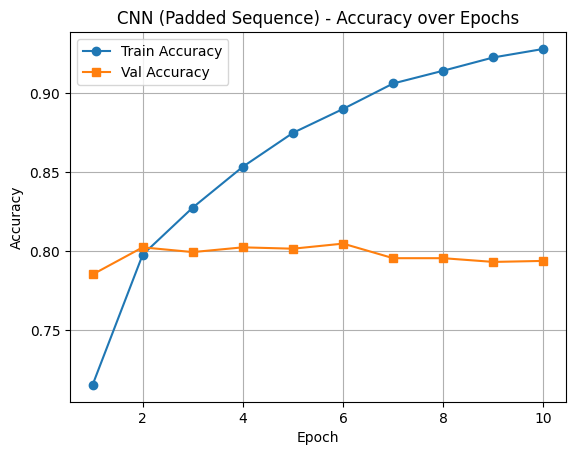

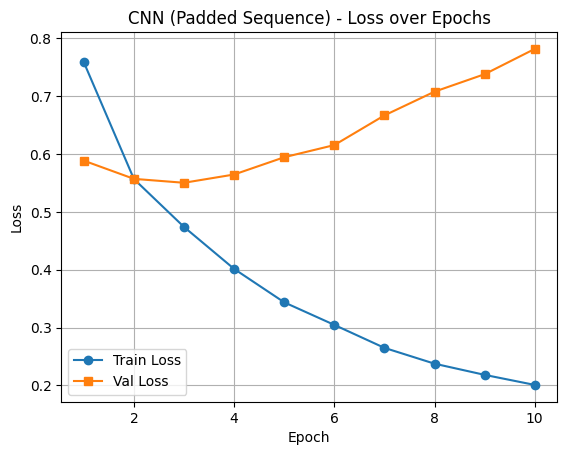

365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

📊 CNN (Padded Sequence) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.73      0.81      0.77      3768
       fraud_scam_identity_theft       0.76      0.74      0.75       828
    incorrect_info_credit_report       0.85      0.84      0.84      4143
threatened_negative_legal_action       0.65      0.51      0.57      1124
  trouble_during_payment_process       0.91      0.89      0.90      1791

                        accuracy                           0.80     11654
                       macro avg       0.78      0.76      0.77     11654
                    weighted avg       0.80      0.80      0.79     11654



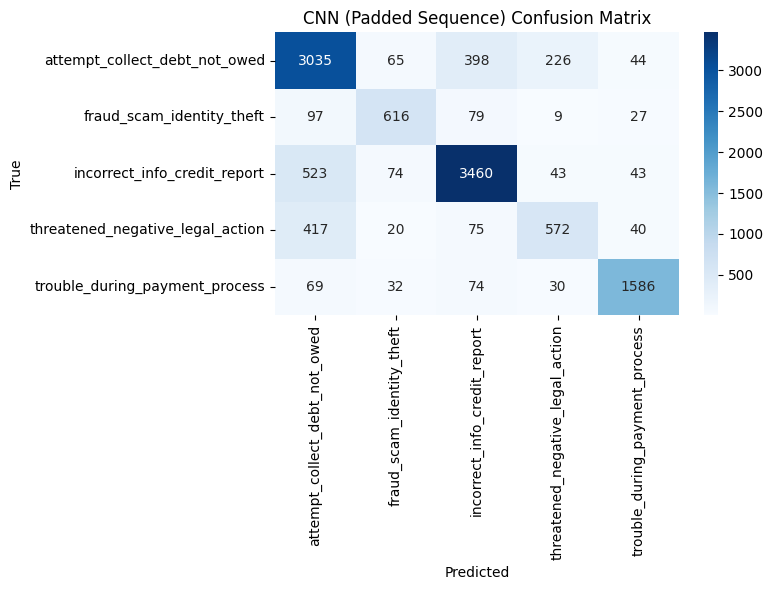

In [ ]:
# CNN Training on Padded Sequence (Complaint_cleaned) - Variation 1
vocab_size = 10000
maxlen = X_train_pad_final.shape[1]
num_classes = len(np.unique(y_train_final))

# Build CNN model - default embedding layer
cnn_seq_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(), Dropout(0.5), Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')  # for multi-class classification
])
cnn_seq_model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create ModelCheckpoint callback to save best model based on validation loss
checkpoint_path = "/content/drive/MyDrive/FYP/Models/CNN_Seq.h5"
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

# Train the model with checkpoint callback
history_cnn_seq = cnn_seq_model.fit(X_train_pad_final, y_train_onehot_final,
                    validation_data=(X_val_pad, y_val_onehot),
                    epochs=10,
                    batch_size=32,
                    callbacks=[checkpoint])

# Show model architecture summary
cnn_seq_model.summary()

# Plot model epoch performance
plot_history(history_cnn_seq, "CNN (Padded Sequence)")

# Generate predictions on test set
cnn_seq_preds = np.argmax(cnn_seq_model.predict(X_test_pad), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 CNN (Padded Sequence) Report")
print(classification_report(y_true, cnn_seq_preds, target_names=class_names))
plot_cm(y_true, cnn_seq_preds, "CNN (Padded Sequence) Confusion Matrix")

### Variation 2: Combined TFIDF Weighted Word2Vec + LDA Features

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5888 - loss: 1.0415
Epoch 1: val_loss improved from inf to 0.74733, saving model to /content/drive/MyDrive/FYP/Models/CNN_Comb.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.5889 - loss: 1.0414 - val_accuracy: 0.7293 - val_loss: 0.7473
Epoch 2/10
1306/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7013 - loss: 0.7960
Epoch 2: val_loss improved from 0.74733 to 0.70666, saving model to /content/drive/MyDrive/FYP/Models/CNN_Comb.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7014 - loss: 0.7959 - val_accuracy: 0.7400 - val_loss: 0.7067
Epoch 3/10
1306/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7245 - loss: 0.7474
Epoch 3: val_loss improved from 0.70666 to 0.68933, saving model to /content/drive/MyDrive/FYP/Models/CNN_Comb.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7245 - loss: 0.7474 - val_accuracy: 0.7482 - val_loss: 0.6893
Epoch 4/10
1302/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7206 - loss: 0.7391
Epoch 4: val_loss improved from 0.68933 to 0.67610, saving model to /content/drive/MyDrive/FYP/Models/CNN_Comb.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 8, 64)          │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,985 (78.07 KB)

 Trainable params: 6,661 (26.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,324 (52.05 KB)

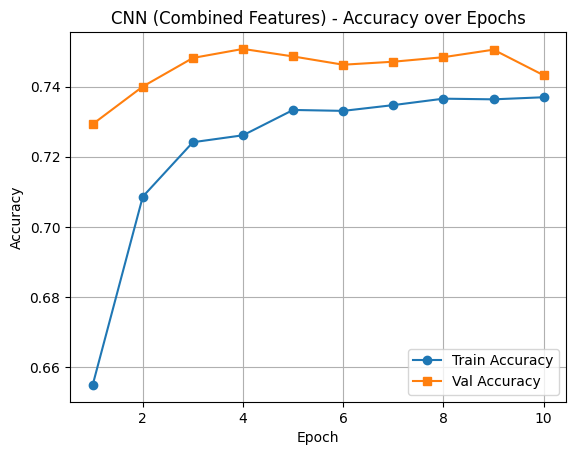

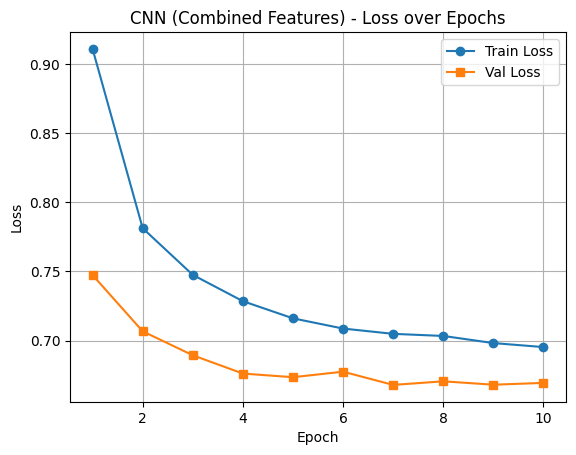

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

📊 CNN (Combined Features) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.70      0.74      0.72      3768
       fraud_scam_identity_theft       0.77      0.69      0.73       828
    incorrect_info_credit_report       0.79      0.83      0.81      4143
threatened_negative_legal_action       0.63      0.37      0.46      1124
  trouble_during_payment_process       0.85      0.92      0.89      1791

                        accuracy                           0.76     11654
                       macro avg       0.75      0.71      0.72     11654
                    weighted avg       0.76      0.76      0.75     11654



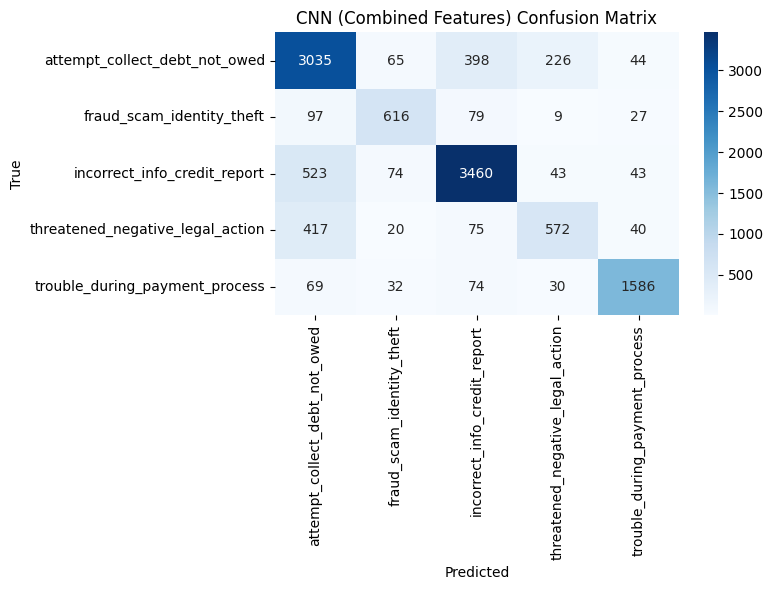

In [ ]:
# CNN Training on Combined Sequence Features (TF-IDF weighted Word2Vec + LDA) - Variation 2
# (timesteps, features_per_timestep)
input_shape = (X_seq_combined_train_final.shape[1], X_seq_combined_train_final.shape[2])
num_classes = y_train_onehot.shape[1]

# Define CNN model - no embedding layer
cnn_comb_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
    GlobalMaxPooling1D(), Dropout(0.5), Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])
cnn_comb_model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create ModelCheckpoint callback to save best model based on validation loss
checkpoint_path = "/content/drive/MyDrive/FYP/Models/CNN_Comb.h5"
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

# Train CNN model
history_cnn_comb = cnn_comb_model.fit(X_seq_combined_train_final, y_train_onehot_final,
                    validation_data=(X_seq_combined_val, y_val_onehot),
                    epochs=10,
                    batch_size=32,
                    callbacks=[checkpoint])

# Show model architecture summary
cnn_comb_model.summary()

# Plot model epoch performance
plot_history(history_cnn_comb, "CNN (Combined Features)")

# Generate predictions on test set
cnn_comb_preds = np.argmax(cnn_comb_model.predict(X_test_seq_combined), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 CNN (Combined Features) Report")
print(classification_report(y_true, cnn_comb_preds, target_names=class_names))
plot_cm(y_true, cnn_seq_preds, "CNN (Combined Features) Confusion Matrix")

## Recurrent Neural Network (LSTM)

### Variation 1: Padded Sequence

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4063 - loss: 1.3132
Epoch 1: val_loss improved from inf to 1.09294, saving model to /content/drive/MyDrive/FYP/Models/RNN_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.4063 - loss: 1.3131 - val_accuracy: 0.4878 - val_loss: 1.0929
Epoch 2/10
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5806 - loss: 0.9745
Epoch 2: val_loss improved from 1.09294 to 0.67515, saving model to /content/drive/MyDrive/FYP/Models/RNN_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.5806 - loss: 0.9745 - val_accuracy: 0.7559 - val_loss: 0.6751
Epoch 3/10
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7782 - loss: 0.6183
Epoch 3: val_loss improved from 0.67515 to 0.61212, saving model to /content/drive/MyDrive/FYP/Models/RNN_Seq.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,260,497 (16.25 MB)

 Trainable params: 1,420,165 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,840,332 (10.84 MB)

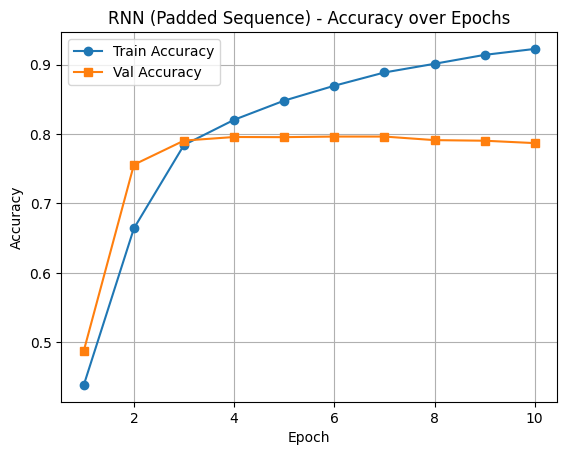

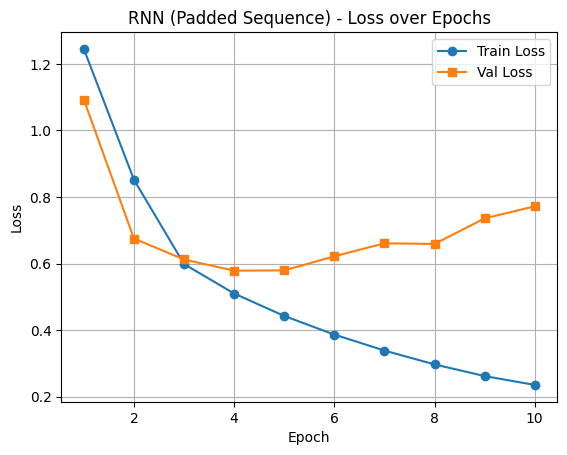

365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

📊 RNN (Padded Sequence) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.74      0.79      0.76      3768
       fraud_scam_identity_theft       0.74      0.74      0.74       828
    incorrect_info_credit_report       0.88      0.81      0.85      4143
threatened_negative_legal_action       0.59      0.54      0.56      1124
  trouble_during_payment_process       0.85      0.94      0.89      1791

                        accuracy                           0.79     11654
                       macro avg       0.76      0.76      0.76     11654
                    weighted avg       0.79      0.79      0.79     11654



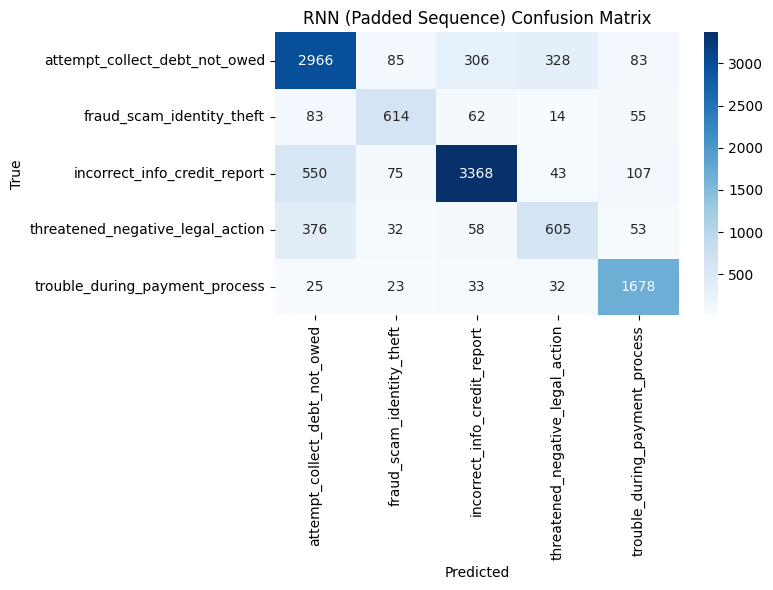

In [ ]:
# RNN Training on Padded Sequence (Complaint_cleaned) - Variation 1
vocab_size = 10000
maxlen = X_train_pad_final.shape[1]
num_classes = len(np.unique(y_train_final))

# Build RNN model with LSTM - default embedding layer
rnn_seq_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen),
    LSTM(128, return_sequences=False),
    Dropout(0.5), Dense(64, activation='relu'), Dense(num_classes, activation='softmax')
])
rnn_seq_model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Define checkpoint path
checkpoint_path = "/content/drive/MyDrive/FYP/Models/RNN_Seq.h5"
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

# Train the model
history_rnn_seq = rnn_seq_model.fit(X_train_pad_final, y_train_onehot_final,
                    validation_data=(X_val_pad, y_val_onehot),
                    epochs=10,
                    batch_size=32,
                    callbacks=[checkpoint])

# Show the model architecture summary
rnn_seq_model.summary()

# Plot model epoch performance
plot_history(history_rnn_seq, "RNN (Padded Sequence)")

# Generate predictions on test set
rnn_seq_preds = np.argmax(rnn_seq_model.predict(X_test_pad), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 RNN (Padded Sequence) Report")
print(classification_report(y_true, rnn_seq_preds, target_names=class_names))
plot_cm(y_true, rnn_seq_preds, "RNN (Padded Sequence) Confusion Matrix")

### Variation 2: Combined TFIDF Weighted Word2Vec + LDA Features

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1306/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6398 - loss: 0.9294
Epoch 1: val_loss improved from inf to 0.70783, saving model to /content/drive/MyDrive/FYP/Models/RNN_Comb.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6401 - loss: 0.9288 - val_accuracy: 0.7347 - val_loss: 0.7078
Epoch 2/10
1305/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7364 - loss: 0.7061
Epoch 2: val_loss improved from 0.70783 to 0.65963, saving model to /content/drive/MyDrive/FYP/Models/RNN_Comb.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7364 - loss: 0.7061 - val_accuracy: 0.7505 - val_loss: 0.6596
Epoch 3/10
1302/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7527 - loss: 0.6640
Epoch 3: val_loss improved from 0.65963 to 0.64610, saving model to /content/drive/MyDrive/FYP/Models/RNN_Comb.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,785 (940.57 KB)

 Trainable params: 80,261 (313.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 160,524 (627.05 KB)

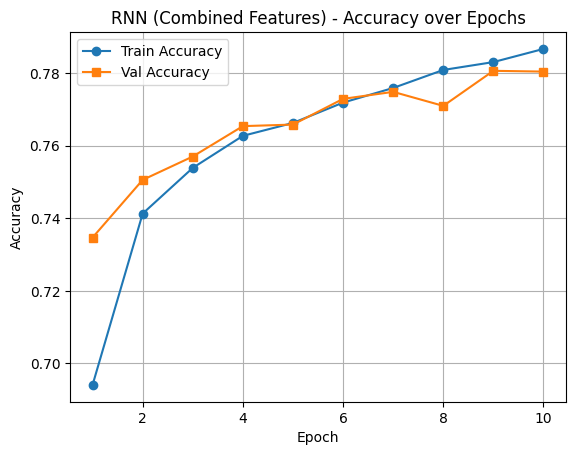

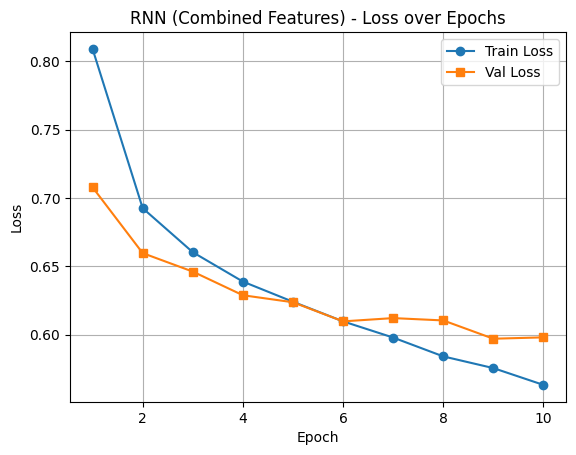

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

📊 RNN (Combined Features) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.71      0.81      0.75      3768
       fraud_scam_identity_theft       0.77      0.75      0.76       828
    incorrect_info_credit_report       0.86      0.80      0.83      4143
threatened_negative_legal_action       0.69      0.43      0.53      1124
  trouble_during_payment_process       0.85      0.95      0.90      1791

                        accuracy                           0.79     11654
                       macro avg       0.78      0.75      0.75     11654
                    weighted avg       0.79      0.79      0.78     11654



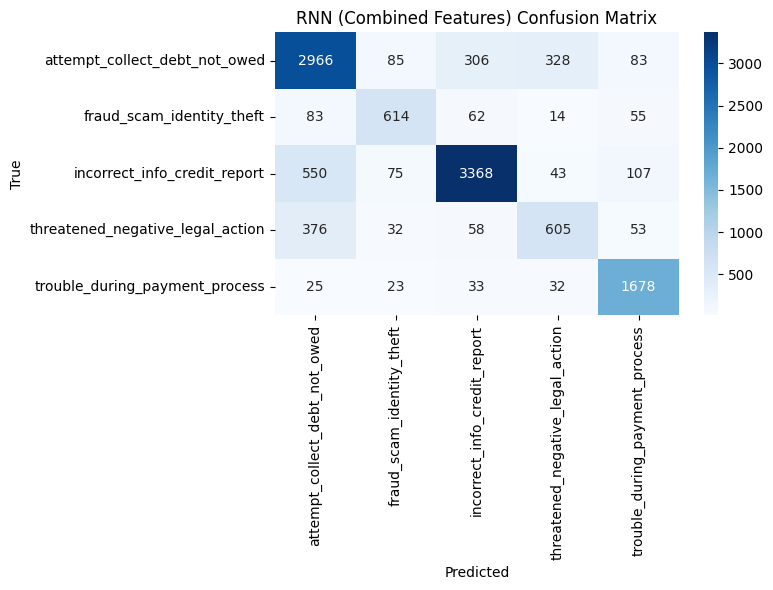

In [ ]:
# RNN Training on Combined Sequence Features (TF-IDF weighted Word2Vec + LDA) - Variation 2
# (timesteps, features_per_timestep)
input_shape = (X_seq_combined_train_final.shape[1], X_seq_combined_train_final.shape[2])
num_classes = y_train_onehot.shape[1]

# Build RNN model with LSTM for combined features - no Embedding layer
rnn_comb_model = Sequential([
    LSTM(128, input_shape=input_shape, return_sequences=False),
    Dropout(0.5), Dense(64, activation='relu'), Dense(num_classes, activation='softmax')
])
rnn_comb_model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ModelCheckpoint to save best model
checkpoint_path = "/content/drive/MyDrive/FYP/Models/RNN_Comb.h5"
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

# Train the model
history_rnn_comb = rnn_comb_model.fit(X_seq_combined_train_final, y_train_onehot_final,
                    validation_data=(X_seq_combined_val, y_val_onehot),
                    epochs=10,
                    batch_size=32,
                    callbacks=[checkpoint])

# Show the model architecture summary
rnn_comb_model.summary()

# Plot model epoch performance
plot_history(history_rnn_comb, "RNN (Combined Features)")

# Generate predictions on test set
rnn_comb_preds = np.argmax(rnn_comb_model.predict(X_test_seq_combined), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 RNN (Combined Features) Report")
print(classification_report(y_true, rnn_comb_preds, target_names=class_names))
plot_cm(y_true, rnn_seq_preds, "RNN (Combined Features) Confusion Matrix")

## Graph Neural Network

### GCN Variation 1: TF-IDF Weighted Word2Vec

Epoch 001: val_accuracy = 0.1489, val_loss improved to 1.6184, saving model...
Epoch 002: val_accuracy = 0.3456, val_loss improved to 1.5654, saving model...
Epoch 003: val_accuracy = 0.3372, val_loss improved to 1.5274, saving model...
Epoch 004: val_accuracy = 0.3400, val_loss improved to 1.4937, saving model...
Epoch 005: val_accuracy = 0.3374, val_loss improved to 1.4703, saving model...
Epoch 006: val_accuracy = 0.3312, val_loss improved to 1.4611, saving model...
Epoch 007: val_accuracy = 0.3402, val_loss = 1.4616
Epoch 008: val_accuracy = 0.3475, val_loss = 1.4654
Epoch 009: val_accuracy = 0.3419, val_loss = 1.4676
Epoch 010: val_accuracy = 0.3348, val_loss = 1.4650
Epoch 011: val_accuracy = 0.3483, val_loss improved to 1.4593, saving model...
Epoch 012: val_accuracy = 0.3366, val_loss improved to 1.4550, saving model...
Epoch 013: val_accuracy = 0.3471, val_loss improved to 1.4529, saving model...
Epoch 014: val_accuracy = 0.3496, val_loss = 1.4531
Epoch 015: val_accuracy = 0.3

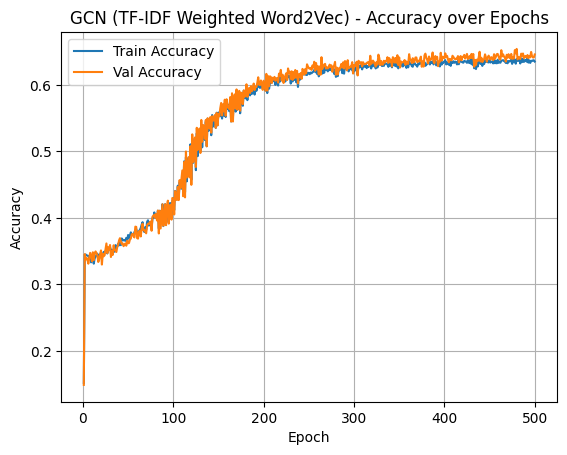

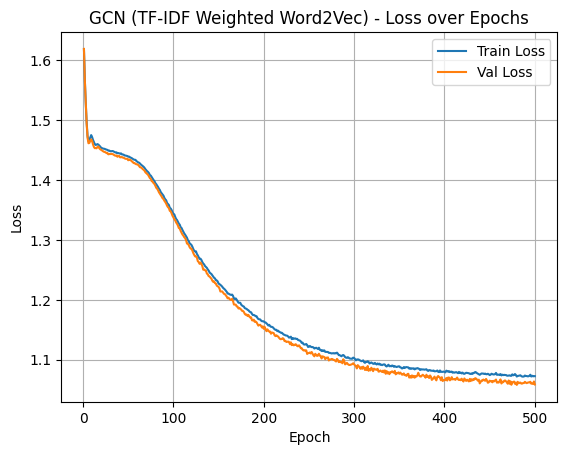


📊 GCN (TF-IDF Weighted Word2Vec) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.58      0.70      0.63      3768
       fraud_scam_identity_theft       0.00      0.00      0.00       828
    incorrect_info_credit_report       0.71      0.85      0.77      4143
threatened_negative_legal_action       0.00      0.00      0.00      1124
  trouble_during_payment_process       0.74      0.86      0.80      1791

                        accuracy                           0.66     11654
                       macro avg       0.40      0.48      0.44     11654
                    weighted avg       0.55      0.66      0.60     11654



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


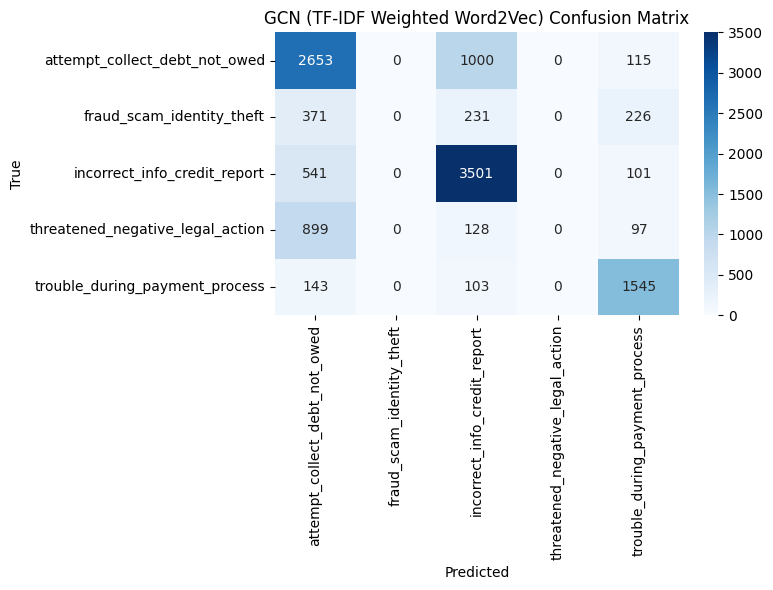

In [ ]:
# Concatenate for full graph using TF-IDF weighted Word2Vec features
X_all = np.vstack([tfidf_w2v_train, tfidf_w2v_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

num_train_final = len(tfidf_w2v_train_final)
num_val = len(tfidf_w2v_val)
num_train_total = num_train_final + num_val
num_test = len(tfidf_w2v_test)

# Construct graph using KNN (only for adjacency, not learning)
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]
# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v1 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v1 = NormalizeFeatures()(data_gcn_v1)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v1.train_mask = train_mask
data_gcn_v1.val_mask = val_mask
data_gcn_v1.test_mask = test_mask

# GCN Model Definition
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.dropout = nn.Dropout(0.5)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v1.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = GCN(in_dim, hidden_dim, out_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data_gcn_v1 = data_gcn_v1.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4) # 0.0005

# Directory to save models
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "GCN_V1.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v1)
    loss = F.cross_entropy(out[data_gcn_v1.train_mask], data_gcn_v1.y[data_gcn_v1.train_mask])
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v1.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v1.y[data_gcn_v1.train_mask]).sum().item() / data_gcn_v1.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v1.val_mask]
        val_labels = data_gcn_v1.y[data_gcn_v1.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v1.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)

    # Checkpointing and save best model based on val_loss
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

print(f"Best model saved to: {best_model_path} with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "GCN (TF-IDF Weighted Word2Vec)")

# Generate predictions on test mask
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v1)
    preds = out.argmax(dim=1)[data_gcn_v1.test_mask].cpu().numpy()
y_true_gcn_v1 = data_gcn_v1.y[data_gcn_v1.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 GCN (TF-IDF Weighted Word2Vec) Classification Report")
print(classification_report(y_true_gcn_v1, preds, target_names=class_names))
plot_cm(y_true_gcn_v1, preds, "GCN (TF-IDF Weighted Word2Vec) Confusion Matrix")

### GCN Variation 2: Combined TF-IDF Weighted Word2Vec + LDA

Epoch 001: val_accuracy = 0.3207, val_loss improved to 1.6049, saving model...
Epoch 002: val_accuracy = 0.3456, val_loss improved to 1.5532, saving model...
Epoch 003: val_accuracy = 0.3430, val_loss improved to 1.5126, saving model...
Epoch 004: val_accuracy = 0.3423, val_loss improved to 1.4814, saving model...
Epoch 005: val_accuracy = 0.3458, val_loss improved to 1.4614, saving model...
Epoch 006: val_accuracy = 0.3357, val_loss improved to 1.4574, saving model...
Epoch 007: val_accuracy = 0.3413, val_loss = 1.4605
Epoch 008: val_accuracy = 0.3381, val_loss = 1.4637
Epoch 009: val_accuracy = 0.3348, val_loss = 1.4673
Epoch 010: val_accuracy = 0.3381, val_loss = 1.4639
Epoch 011: val_accuracy = 0.3372, val_loss = 1.4601
Epoch 012: val_accuracy = 0.3344, val_loss improved to 1.4572, saving model...
Epoch 013: val_accuracy = 0.3372, val_loss improved to 1.4562, saving model...
Epoch 014: val_accuracy = 0.3445, val_loss improved to 1.4537, saving model...
Epoch 015: val_accuracy = 0.3

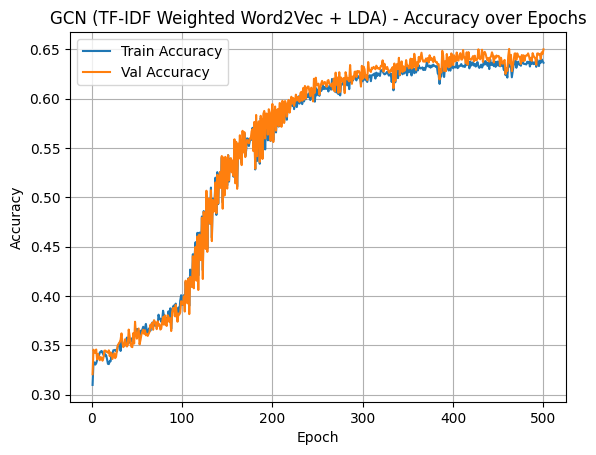

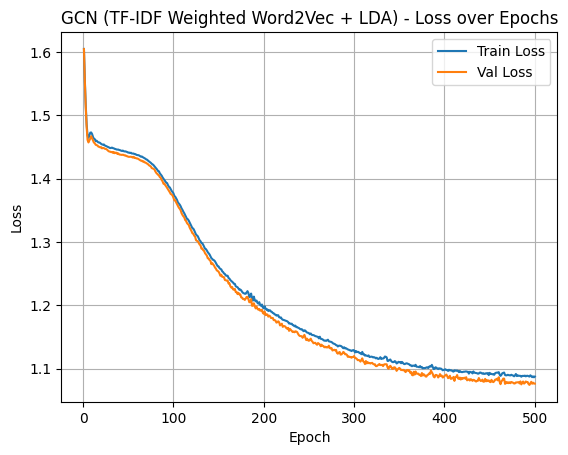


📊 GCN (TF-IDF Weighted Word2Vec + LDA) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.58      0.68      0.63      3768
       fraud_scam_identity_theft       0.00      0.00      0.00       828
    incorrect_info_credit_report       0.69      0.87      0.77      4143
threatened_negative_legal_action       0.00      0.00      0.00      1124
  trouble_during_payment_process       0.74      0.86      0.80      1791

                        accuracy                           0.66     11654
                       macro avg       0.40      0.48      0.44     11654
                    weighted avg       0.55      0.66      0.60     11654



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


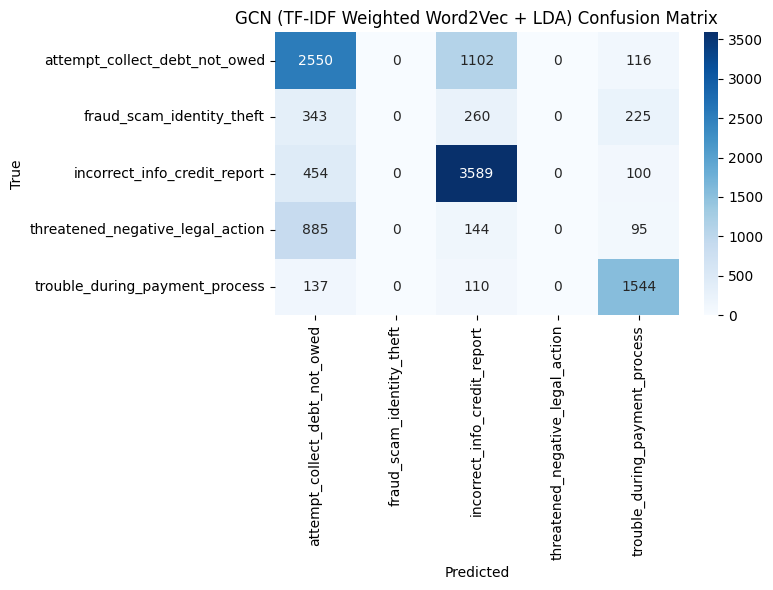

In [ ]:
# Concatenate for full graph using combined TF-IDF weighted Word2Vec + LDA features
X_all = np.vstack([combined_train, combined_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(combined_train_final)
num_val = len(combined_val)
num_train_total = num_train_final + num_val
num_test = len(combined_test)

# Construct graph using KNN (only for adjacency, not learning)
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v2 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v2 = NormalizeFeatures()(data_gcn_v2)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v2.train_mask = train_mask
data_gcn_v2.val_mask = val_mask
data_gcn_v2.test_mask = test_mask

# GCN Model Definition
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.dropout = nn.Dropout(0.5)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v2.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = GCN(in_dim, hidden_dim, out_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data_gcn_v2 = data_gcn_v2.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4) # 0.0005

# Directory to save models
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "GCN_V2.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v2)
    loss = F.cross_entropy(out[data_gcn_v2.train_mask], data_gcn_v2.y[data_gcn_v2.train_mask])
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v2.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v2.y[data_gcn_v2.train_mask]).sum().item() / data_gcn_v2.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v2.val_mask]
        val_labels = data_gcn_v2.y[data_gcn_v2.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v2.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)

    # Checkpointing and save best model based on val_loss
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

print(f"Best model saved to: {best_model_path} with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "GCN (TF-IDF Weighted Word2Vec + LDA)")

# Generate predictions on test mask
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v2)
    preds = out.argmax(dim=1)[data_gcn_v2.test_mask].cpu().numpy()
y_true_gcn_v2 = data_gcn_v2.y[data_gcn_v2.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 GCN (TF-IDF Weighted Word2Vec + LDA) Classification Report")
print(classification_report(y_true_gcn_v2, preds, target_names=class_names))
plot_cm(y_true_gcn_v2, preds, "GCN (TF-IDF Weighted Word2Vec + LDA) Confusion Matrix")

### GAT Variation 1: TF-IDF Weighted Word2Vec

Epoch 001: val_accuracy = 0.2645, val_loss improved to 1.6050, saving model...
Epoch 002: val_accuracy = 0.3426, val_loss improved to 1.5833, saving model...
Epoch 003: val_accuracy = 0.3458, val_loss improved to 1.5610, saving model...
Epoch 004: val_accuracy = 0.3438, val_loss improved to 1.5409, saving model...
Epoch 005: val_accuracy = 0.3320, val_loss improved to 1.5256, saving model...
Epoch 006: val_accuracy = 0.3447, val_loss improved to 1.5102, saving model...
Epoch 007: val_accuracy = 0.3451, val_loss improved to 1.4995, saving model...
Epoch 008: val_accuracy = 0.3348, val_loss improved to 1.4899, saving model...
Epoch 009: val_accuracy = 0.3350, val_loss improved to 1.4873, saving model...
Epoch 010: val_accuracy = 0.3359, val_loss improved to 1.4860, saving model...
Epoch 011: val_accuracy = 0.3466, val_loss improved to 1.4744, saving model...
Epoch 012: val_accuracy = 0.3486, val_loss = 1.4773
Epoch 013: val_accuracy = 0.3344, val_loss = 1.4777
Epoch 014: val_accuracy = 0

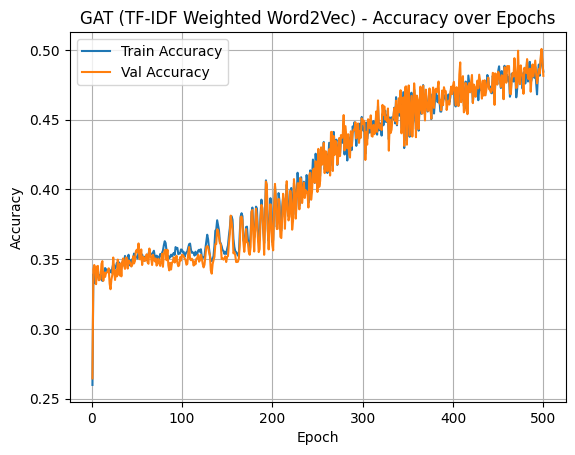

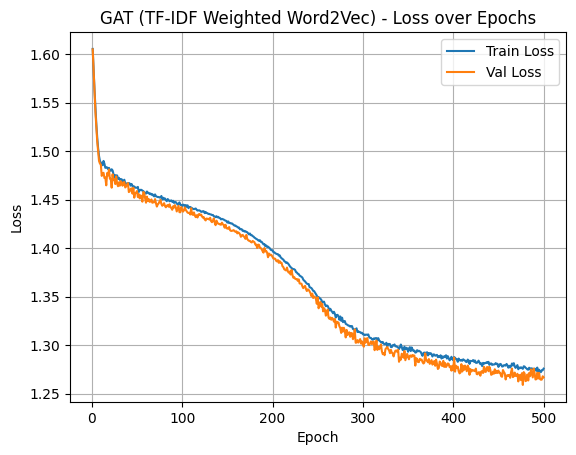


📊 GAT (TF-IDF Weighted Word2Vec) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.33      0.44      0.38      3768
       fraud_scam_identity_theft       0.00      0.00      0.00       828
    incorrect_info_credit_report       0.58      0.86      0.69      4143
threatened_negative_legal_action       0.00      0.00      0.00      1124
  trouble_during_payment_process       0.96      0.23      0.37      1791

                        accuracy                           0.48     11654
                       macro avg       0.37      0.31      0.29     11654
                    weighted avg       0.46      0.48      0.42     11654



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


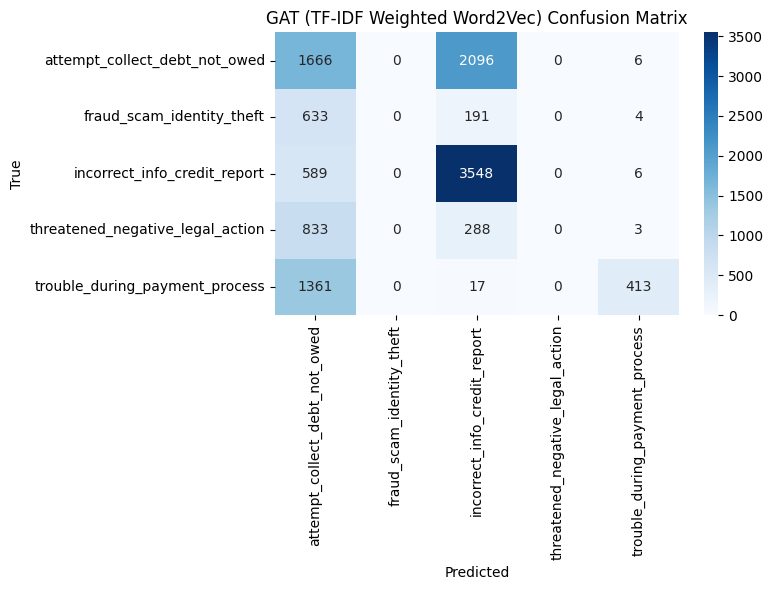

In [ ]:
# GAT Model (Variation 1)

# Concatenate for full graph
X_all = np.vstack([tfidf_w2v_train, tfidf_w2v_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(tfidf_w2v_train_final)
num_val = len(tfidf_w2v_val)
num_train_total = num_train_final + num_val
num_test = len(tfidf_w2v_test)

# Construct graph
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)

x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gat_v1 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gat_v1 = NormalizeFeatures()(data_gat_v1)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gat_v1.train_mask = train_mask
data_gat_v1.val_mask = val_mask
data_gat_v1.test_mask = test_mask

# Define GAT Model
class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super(GAT, self).__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        self.dropout = nn.Dropout(0.6)
        self.gat2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.6)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.dropout(x)
        x = self.gat2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Train GAT Model
in_dim = data_gat_v1.num_node_features
hidden_dim = 8
out_dim = len(np.unique(y_all))
model = GAT(in_dim, hidden_dim, out_dim, heads=8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data_gat_v1 = data_gat_v1.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4) # 0.0005

# Directory for saving model
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "GAT_V1.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gat_v1)
    loss = F.cross_entropy(out[data_gat_v1.train_mask], data_gat_v1.y[data_gat_v1.train_mask])
    loss.backward()
    optimizer.step()

    # Accuracy
    preds_train = out[data_gat_v1.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gat_v1.y[data_gat_v1.train_mask]).sum().item() / data_gat_v1.train_mask.sum().item()

    model.eval()
    with torch.no_grad():
        val_logits = out[data_gat_v1.val_mask]
        val_labels = data_gat_v1.y[data_gat_v1.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gat_v1.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)

    # Checkpointing and save best model based on val_loss
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

print(f"Best model saved to: {best_model_path} val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "GAT (TF-IDF Weighted Word2Vec)")

# Generate predictions on test mask
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gat_v1)
    preds = out.argmax(dim=1)[data_gat_v1.test_mask].cpu().numpy()
y_true_gat_v1 = data_gat_v1.y[data_gat_v1.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 GAT (TF-IDF Weighted Word2Vec) Classification Report")
print(classification_report(y_true_gat_v1, preds, target_names=class_names))
plot_cm(y_true_gat_v1, preds, "GAT (TF-IDF Weighted Word2Vec) Confusion Matrix")

### GAT Variation 2: Combined TF-IDF Weighted Word2Vec + LDA

Epoch 001: val_accuracy = 0.3037, val_loss improved to 1.6089, saving model...
Epoch 002: val_accuracy = 0.3404, val_loss improved to 1.5836, saving model...
Epoch 003: val_accuracy = 0.3419, val_loss improved to 1.5622, saving model...
Epoch 004: val_accuracy = 0.3248, val_loss improved to 1.5395, saving model...
Epoch 005: val_accuracy = 0.3318, val_loss improved to 1.5249, saving model...
Epoch 006: val_accuracy = 0.3301, val_loss improved to 1.5093, saving model...
Epoch 007: val_accuracy = 0.3265, val_loss improved to 1.4992, saving model...
Epoch 008: val_accuracy = 0.3353, val_loss improved to 1.4865, saving model...
Epoch 009: val_accuracy = 0.3396, val_loss improved to 1.4863, saving model...
Epoch 010: val_accuracy = 0.3436, val_loss improved to 1.4760, saving model...
Epoch 011: val_accuracy = 0.3340, val_loss = 1.4788
Epoch 012: val_accuracy = 0.3400, val_loss = 1.4794
Epoch 013: val_accuracy = 0.3445, val_loss = 1.4888
Epoch 014: val_accuracy = 0.3417, val_loss = 1.4837
Ep

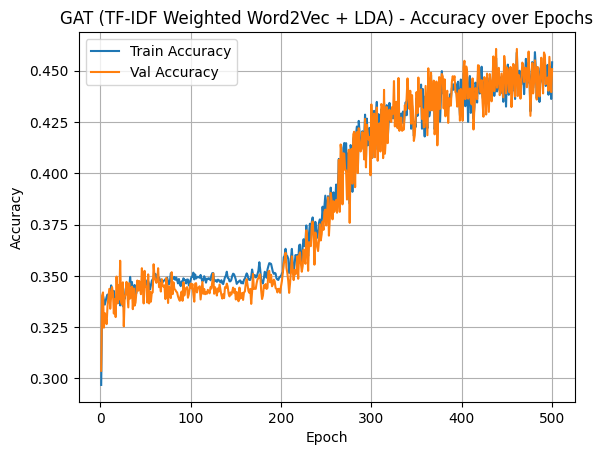

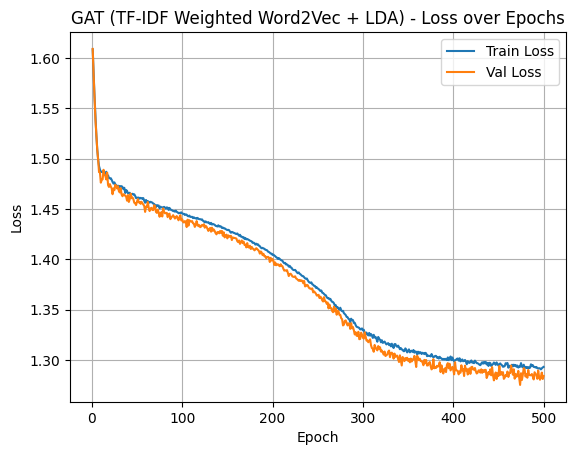


📊 GAT (TF-IDF Weighted Word2Vec + LDA) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.27      0.35      0.30      3768
       fraud_scam_identity_theft       0.00      0.00      0.00       828
    incorrect_info_credit_report       0.53      0.83      0.65      4143
threatened_negative_legal_action       0.00      0.00      0.00      1124
  trouble_during_payment_process       0.96      0.21      0.35      1791

                        accuracy                           0.44     11654
                       macro avg       0.35      0.28      0.26     11654
                    weighted avg       0.43      0.44      0.38     11654



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


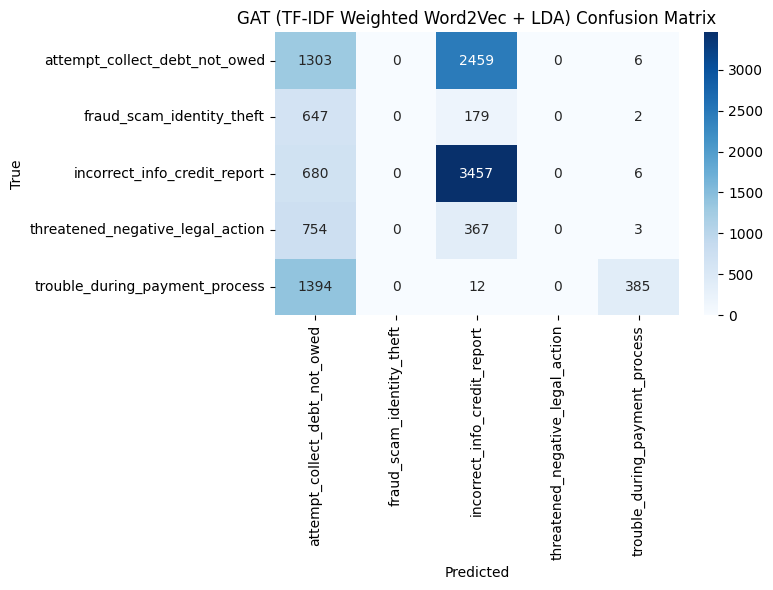

In [ ]:
# GAT Model (Variation 2)

# Concatenate for full graph using combined TF-IDF weighted Word2Vec + LDA features
X_all = np.vstack([combined_train, combined_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(combined_train_final)
num_val = len(combined_val)
num_train_total = num_train_final + num_val
num_test = len(combined_test)

k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)

x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gat_v2 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gat_v2 = NormalizeFeatures()(data_gat_v2)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gat_v2.train_mask = train_mask
data_gat_v2.val_mask = val_mask
data_gat_v2.test_mask = test_mask

# Define GAT Model
class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super(GAT, self).__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        self.dropout = nn.Dropout(0.6)
        self.gat2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.6)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.dropout(x)
        x = self.gat2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Train GAT Model
in_dim = data_gat_v2.num_node_features
hidden_dim = 8
out_dim = len(np.unique(y_all))
model = GAT(in_dim, hidden_dim, out_dim, heads=8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data_gat_v2 = data_gat_v2.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4) # 0.0005

# Directory for saving models
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "GAT_V2.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gat_v2)
    loss = F.cross_entropy(out[data_gat_v2.train_mask], data_gat_v2.y[data_gat_v2.train_mask])
    loss.backward()
    optimizer.step()

    # Accuracy
    preds_train = out[data_gat_v2.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gat_v2.y[data_gat_v2.train_mask]).sum().item() / data_gat_v2.train_mask.sum().item()

    model.eval()
    with torch.no_grad():
        val_logits = out[data_gat_v2.val_mask]
        val_labels = data_gat_v2.y[data_gat_v2.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gat_v2.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)

    # Checkpointing and save best model based on val_loss
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

print(f"Best model saved to: {best_model_path} with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "GAT (TF-IDF Weighted Word2Vec + LDA)")


# Generate predictions on test mask
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gat_v2)
    preds = out.argmax(dim=1)[data_gat_v2.test_mask].cpu().numpy()
y_true_gat_v2 = data_gat_v2.y[data_gat_v2.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 GAT (TF-IDF Weighted Word2Vec + LDA) Classification Report")
print(classification_report(y_true_gat_v2, preds, target_names=class_names))
plot_cm(y_true_gat_v2, preds, "GAT (TF-IDF Weighted Word2Vec + LDA) Confusion Matrix")

### Cosine Similarity GCN Variation 1

Epoch 001: val_accuracy = 0.2166, val_loss improved to 1.6106, saving model...
Epoch 002: val_accuracy = 0.3518, val_loss improved to 1.5647, saving model...
Epoch 003: val_accuracy = 0.3483, val_loss improved to 1.5247, saving model...
Epoch 004: val_accuracy = 0.3314, val_loss improved to 1.4884, saving model...
Epoch 005: val_accuracy = 0.3376, val_loss improved to 1.4623, saving model...
Epoch 006: val_accuracy = 0.3235, val_loss improved to 1.4537, saving model...
Epoch 007: val_accuracy = 0.3507, val_loss = 1.4584
Epoch 008: val_accuracy = 0.3355, val_loss = 1.4682
Epoch 009: val_accuracy = 0.3511, val_loss = 1.4670
Epoch 010: val_accuracy = 0.3413, val_loss = 1.4645
Epoch 011: val_accuracy = 0.3344, val_loss = 1.4574
Epoch 012: val_accuracy = 0.3376, val_loss improved to 1.4531, saving model...
Epoch 013: val_accuracy = 0.3408, val_loss improved to 1.4484, saving model...
Epoch 014: val_accuracy = 0.3363, val_loss = 1.4491
Epoch 015: val_accuracy = 0.3402, val_loss = 1.4509
Epoc

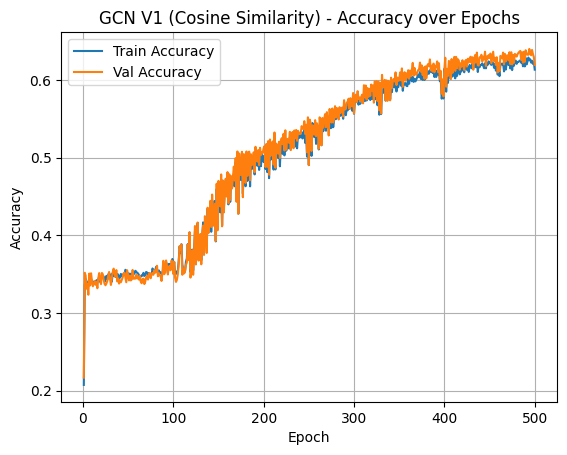

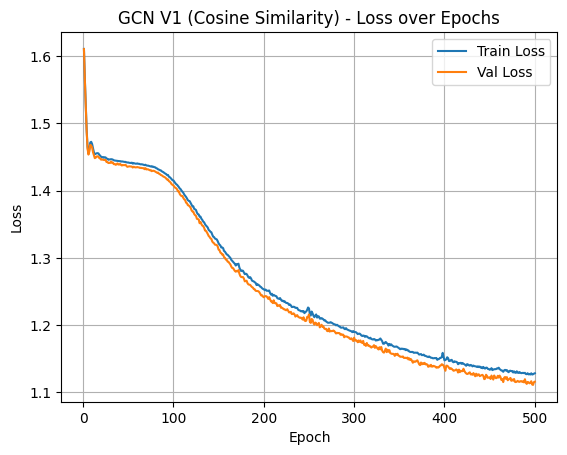


📊 GCN V1 (Cosine Similarity) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.52      0.78      0.62      3768
       fraud_scam_identity_theft       0.00      0.00      0.00       828
    incorrect_info_credit_report       0.76      0.77      0.76      4143
threatened_negative_legal_action       0.00      0.00      0.00      1124
  trouble_during_payment_process       0.81      0.78      0.79      1791

                        accuracy                           0.65     11654
                       macro avg       0.42      0.47      0.44     11654
                    weighted avg       0.56      0.65      0.59     11654



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


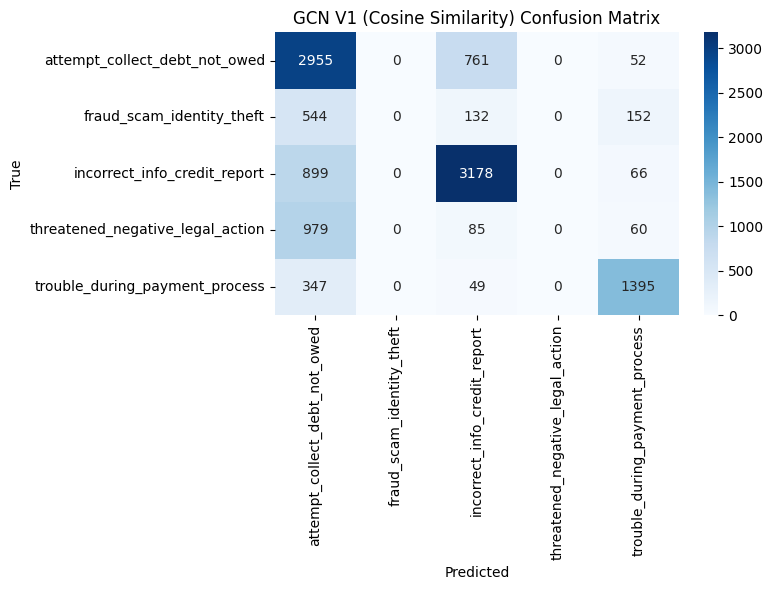

In [ ]:
# Cosine Similarity GCN V1

# Concatenate for full graph using TF-IDF weighted Word2Vec features
X_all = np.vstack([tfidf_w2v_train, tfidf_w2v_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(tfidf_w2v_train_final)
num_val = len(tfidf_w2v_val)
num_train_total = num_train_final + num_val
num_test = len(tfidf_w2v_test)

# Construct cosine-based KNN graph
k = 10
knn = NearestNeighbors(n_neighbors=k, metric='cosine')
knn.fit(X_all)
adj_matrix = kneighbors_graph(X_all, n_neighbors=k, mode='connectivity', include_self=True, metric='cosine')
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)

# PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_cosine = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_cosine = NormalizeFeatures()(data_gcn_cosine)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_cosine.train_mask = train_mask
data_gcn_cosine.val_mask = val_mask
data_gcn_cosine.test_mask = test_mask

# Define GCN model
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.dropout = nn.Dropout(0.5)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Train GCN Model
in_dim = data_gcn_cosine.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = GCN(in_dim, hidden_dim, out_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data_gcn_cosine = data_gcn_cosine.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4) # 0.0005

# Save paths
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "GCN_V1_Cosine.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_cosine)
    loss = F.cross_entropy(out[data_gcn_cosine.train_mask], data_gcn_cosine.y[data_gcn_cosine.train_mask])
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_cosine.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_cosine.y[data_gcn_cosine.train_mask]).sum().item() / data_gcn_cosine.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_cosine.val_mask]
        val_labels = data_gcn_cosine.y[data_gcn_cosine.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_cosine.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)

    # Checkpointing and save best model based on val_loss
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

print(f"Best model with val_loss: {best_val_loss:.4f}")

# Plot model performance
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "GCN V1 (Cosine Similarity)")

# Generate predictions on test mask
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_cosine)
    preds = out.argmax(dim=1)[data_gcn_cosine.test_mask].cpu().numpy()
y_true_gcn_cosine = data_gcn_cosine.y[data_gcn_cosine.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 GCN V1 (Cosine Similarity) Classification Report")
print(classification_report(y_true_gcn_cosine, preds, target_names=class_names))
plot_cm(y_true_gcn_cosine, preds, "GCN V1 (Cosine Similarity) Confusion Matrix")

# Class Weight Optimization & Early Stopping

Observed class imbalance, poor performance on minority classes for all model variations, and certain overfitting issues on CNN and RNN, hence would apply class weight optimization and early dropping to tackle these issues

## Convolutional Neural Network

### Variation 1: Padded Sequence

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5354 - loss: 1.5080
Epoch 1: val_loss improved from inf to 0.88138, saving model to /content/drive/MyDrive/FYP/Models/CNN_Seq_CWO.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.5355 - loss: 1.5077 - val_accuracy: 0.7314 - val_loss: 0.8814
Epoch 2/20
1310/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6982 - loss: 0.8861
Epoch 2: val_loss did not improve from 0.88138
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.6982 - loss: 0.8861 - val_accuracy: 0.7079 - val_loss: 0.9216
Epoch 3/20
1305/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7235 - loss: 0.8237
Epoch 3: val_loss improved from 0.88138 to 0.84477, saving model to /content/drive/MyDrive/FYP/Models/CNN_Seq_CWO.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7235 - loss: 0.8236 - val_accuracy: 0.7377 - val_loss: 0.8448
Epoch 4/20
1304/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7404 - loss: 0.7786
Epoch 4: val_loss did not improve from 0.84477
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7404 - loss: 0.7786 - val_accuracy: 0.7405 - val_loss: 0.8581
Epoch 5/20
1308/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7490 - loss: 0.7534
Epoch 5: val_loss did not improve from 0.84477
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7490 - loss: 0.7534 - val_accuracy: 0.7407 - val_loss: 0.8857
Epoch 6/20
1300/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7646 - loss: 0.7176
Epoch 6: val_loss improved from 0.84477 to 0.81411, saving model to /content/drive/MyDrive/FYP/Models/CNN_Seq_CWO.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7646 - loss: 0.7177 - val_accuracy: 0.7525 - val_loss: 0.8141
Epoch 7/20
1299/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7713 - loss: 0.7042
Epoch 7: val_loss improved from 0.81411 to 0.80586, saving model to /content/drive/MyDrive/FYP/Models/CNN_Seq_CWO.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 96, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,111,889 (15.69 MB)

 Trainable params: 1,370,629 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,741,260 (10.46 MB)

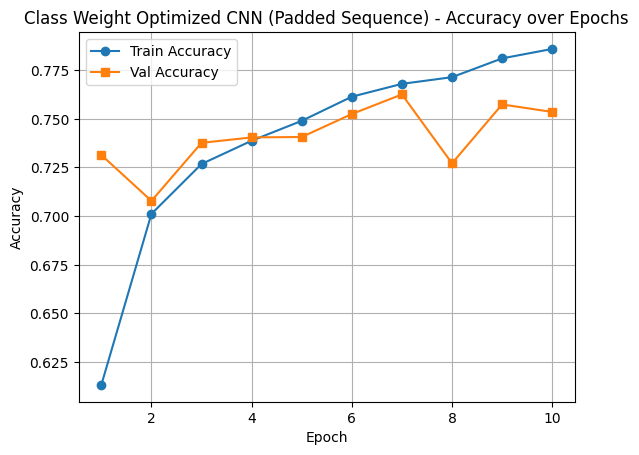

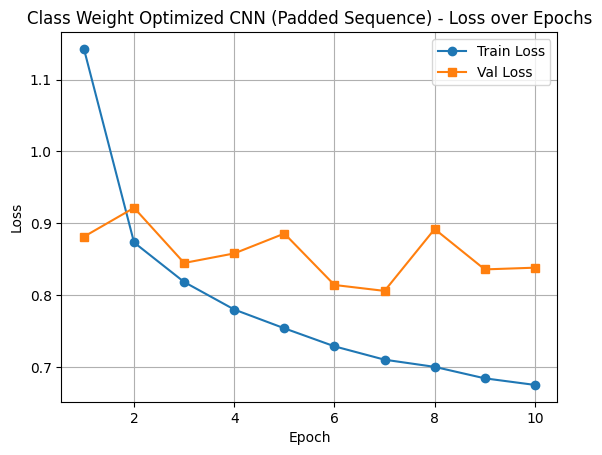

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

📊 Class Weight Optimized CNN (Padded Sequence) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.78      0.67      0.72      3768
       fraud_scam_identity_theft       0.65      0.84      0.73       828
    incorrect_info_credit_report       0.80      0.85      0.82      4143
threatened_negative_legal_action       0.56      0.55      0.56      1124
  trouble_during_payment_process       0.89      0.91      0.90      1791

                        accuracy                           0.77     11654
                       macro avg       0.74      0.77      0.75     11654
                    weighted avg       0.77      0.77      0.77     11654



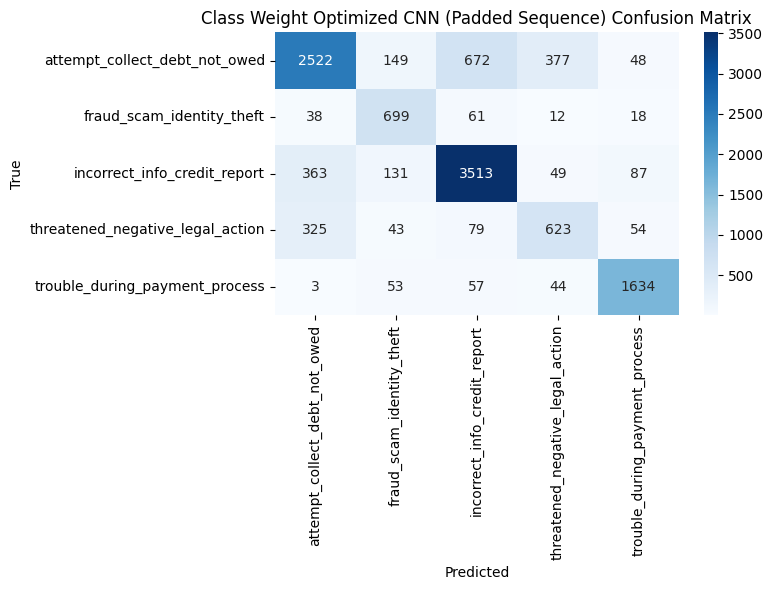

In [ ]:
# Class Weight Optimized CNN Training on Padded Sequence - Variation 1
vocab_size = 10000
maxlen = X_train_pad_final.shape[1]
num_classes = len(np.unique(y_train_final))

# Compute class weights
unique_classes = np.unique(y_train_final)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_final
)
class_weights = dict(zip(unique_classes, class_weights_array))

# Build CNN model with L2 regularization and dropout
cnn_seq_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen),
    Conv1D(filters=128, kernel_size=5, activation='relu', kernel_regularizer=l2(0.01)),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(num_classes, activation='softmax')
])

cnn_seq_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Checkpoint to save best model (based on val_loss)
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/FYP/Models/CNN_Seq_CWO.h5",
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

# Early stopping (stop training if no val_loss improvement for 3 epochs)
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history_cnn_seq = cnn_seq_model.fit(
    X_train_pad_final, y_train_onehot_final,
    validation_data=(X_val_pad, y_val_onehot),
    epochs=20,                    # increased epochs to allow early stopping to work
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)

# Show model architecture
cnn_seq_model.summary()

# Plot training history
plot_history(history_cnn_seq, "Class Weight Optimized CNN (Padded Sequence)")

# Generate predictions on test set
cnn_seq_preds = np.argmax(cnn_seq_model.predict(X_test_pad), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 Class Weight Optimized CNN (Padded Sequence) Report")
print(classification_report(y_true, cnn_seq_preds, target_names=class_names))
plot_cm(y_true, cnn_seq_preds, "Class Weight Optimized CNN (Padded Sequence) Confusion Matrix")

### Variation 2: Combined TF-IDF Weighted Word2Vec + LDA Features

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5202 - loss: 1.2524
Epoch 1: val_loss improved from inf to 0.87804, saving model to /content/drive/MyDrive/FYP/Models/CNN_Comb_CWO.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5202 - loss: 1.2523 - val_accuracy: 0.6935 - val_loss: 0.8780
Epoch 2/20
1294/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6446 - loss: 0.9058
Epoch 2: val_loss improved from 0.87804 to 0.85442, saving model to /content/drive/MyDrive/FYP/Models/CNN_Comb_CWO.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6447 - loss: 0.9056 - val_accuracy: 0.6991 - val_loss: 0.8544
Epoch 3/20
1291/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6680 - loss: 0.8495
Epoch 3: val_loss improved from 0.85442 to 0.85215, saving model to /content/drive/MyDrive/FYP/Models/CNN_Comb_CWO.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 8, 64)          │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,985 (78.07 KB)

 Trainable params: 6,661 (26.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,324 (52.05 KB)

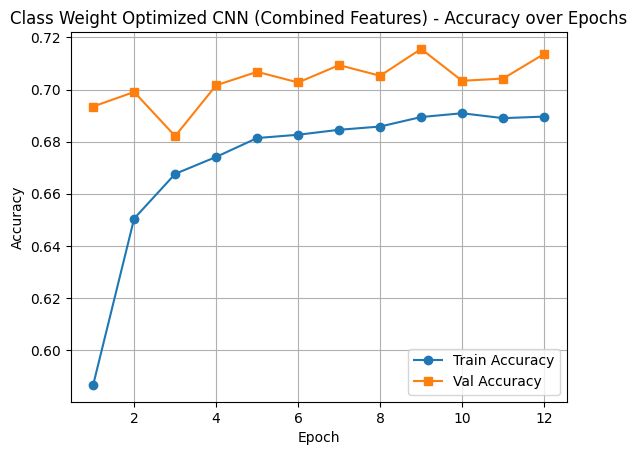

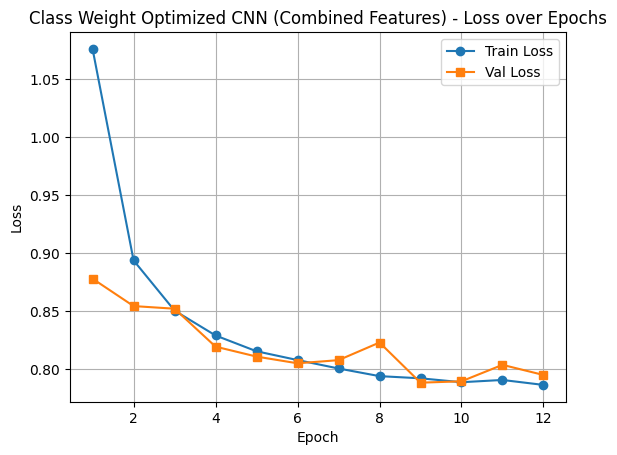

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

📊 Class Weight Optimized CNN (Combined Features) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.73      0.61      0.66      3768
       fraud_scam_identity_theft       0.60      0.80      0.69       828
    incorrect_info_credit_report       0.81      0.78      0.79      4143
threatened_negative_legal_action       0.44      0.60      0.51      1124
  trouble_during_payment_process       0.85      0.92      0.88      1791

                        accuracy                           0.73     11654
                       macro avg       0.69      0.74      0.71     11654
                    weighted avg       0.74      0.73      0.73     11654



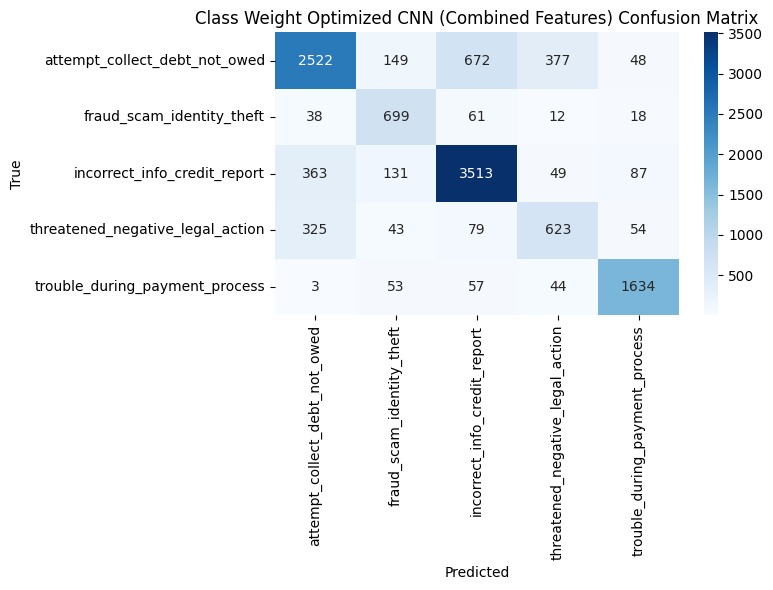

In [ ]:
# Class Weight Optimized CNN Training on Combined Features  - Variation 2

# (timesteps, features_per_timestep)
input_shape = (X_seq_combined_train_final.shape[1], X_seq_combined_train_final.shape[2])
num_classes = len(np.unique(y_train_final))

# Compute class weights
unique_classes = np.unique(y_train_final)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_final
)
class_weights = dict(zip(unique_classes, class_weights_array))

# Define CNN model with L2 regularization and Dropout
cnn_comb_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape,
           kernel_regularizer=l2(0.001)),   # L2 regularization
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(num_classes, activation='softmax')
])

cnn_comb_model.compile(optimizer=Adam(learning_rate=1e-3),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# Callbacks: ModelCheckpoint and EarlyStopping
checkpoint_path = "/content/drive/MyDrive/FYP/Models/CNN_Comb_CWO.h5"
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# Train model with class weights and callbacks
history_cnn_comb = cnn_comb_model.fit(
    X_seq_combined_train_final,
    y_train_onehot_final,
    validation_data=(X_seq_combined_val, y_val_onehot),
    epochs=20,                    # increased epochs to allow early stopping to work
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)

# Print model architecture summary
cnn_comb_model.summary()

# Plot epoch performance graph
plot_history(history_cnn_comb, "Class Weight Optimized CNN (Combined Features)")

# Generate predictions on test set
cnn_comb_preds = np.argmax(cnn_comb_model.predict(X_test_seq_combined), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 Class Weight Optimized CNN (Combined Features) Report")
print(classification_report(y_true, cnn_comb_preds, target_names=class_names))
plot_cm(y_true, cnn_seq_preds, "Class Weight Optimized CNN (Combined Features) Confusion Matrix")

## Recurrent Neural Network (LSTM)

### Variation 1: Padded Sequence

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1310/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3449 - loss: 1.5084
Epoch 1: val_loss improved from inf to 1.31892, saving model to /content/drive/MyDrive/FYP/Models/RNN_Seq_CWO.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.3450 - loss: 1.5083 - val_accuracy: 0.4644 - val_loss: 1.3189
Epoch 2/20
1310/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4340 - loss: 1.3113
Epoch 2: val_loss improved from 1.31892 to 1.08130, saving model to /content/drive/MyDrive/FYP/Models/RNN_Seq_CWO.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.4340 - loss: 1.3111 - val_accuracy: 0.5485 - val_loss: 1.0813
Epoch 3/20
1309/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6445 - loss: 0.8482
Epoch 3: val_loss improved from 1.08130 to 0.74561, saving model to /content/drive/MyDrive/FYP/Models/RNN_Seq_CWO.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,260,497 (16.25 MB)

 Trainable params: 1,420,165 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,840,332 (10.84 MB)

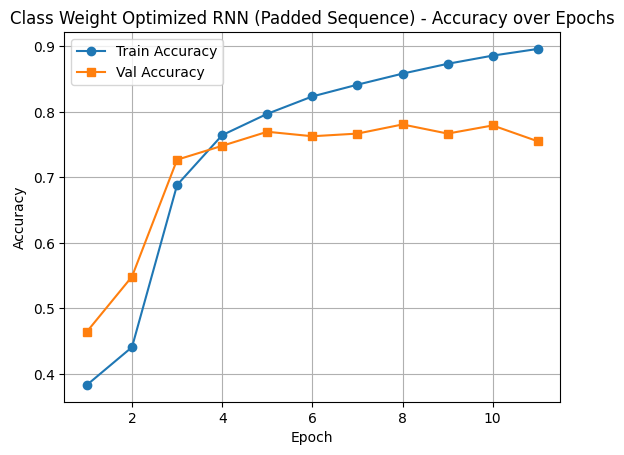

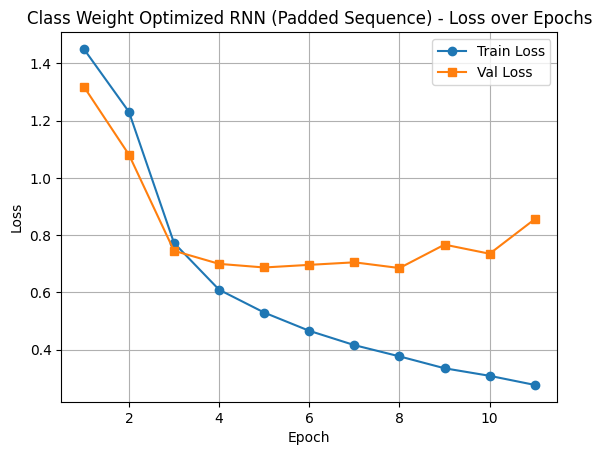

365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

📊 Class Weight Optimized RNN (Padded Sequence) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.76      0.74      0.75      3768
       fraud_scam_identity_theft       0.66      0.84      0.74       828
    incorrect_info_credit_report       0.86      0.83      0.84      4143
threatened_negative_legal_action       0.57      0.58      0.58      1124
  trouble_during_payment_process       0.89      0.90      0.90      1791

                        accuracy                           0.79     11654
                       macro avg       0.75      0.78      0.76     11654
                    weighted avg       0.79      0.79      0.79     11654



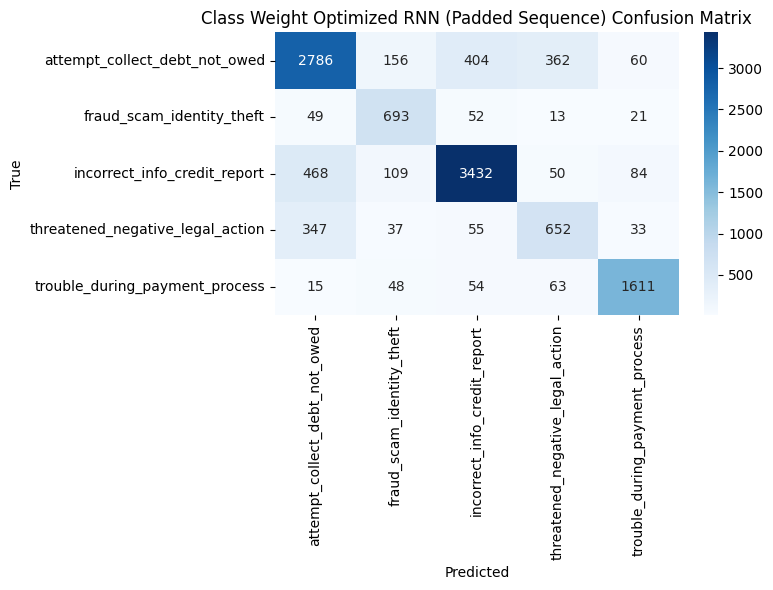

In [ ]:
# Class Weight Optimized RNN Training on Padded Sequence - Variation 1

# Parameters
vocab_size = 10000
maxlen = X_train_pad_final.shape[1]
num_classes = len(np.unique(y_train_final))

# Compute class weights
unique_classes = np.unique(y_train_final)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_final
)
class_weights = dict(zip(unique_classes, class_weights_array))

# Build RNN model with LSTM + L2 regularization on Dense layers
rnn_seq_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(num_classes, activation='softmax')
])

rnn_seq_model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks: ModelCheckpoint and EarlyStopping
checkpoint_path = "/content/drive/MyDrive/FYP/Models/RNN_Seq_CWO.h5"
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# Train the model with class weights and callbacks
history_rnn_seq = rnn_seq_model.fit(
    X_train_pad_final, y_train_onehot_final,
    validation_data=(X_val_pad, y_val_onehot),
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint, early_stop],
    class_weight=class_weights
)

# Print the model architecture summary
rnn_seq_model.summary()

# Plot training history
plot_history(history_rnn_seq, "Class Weight Optimized RNN (Padded Sequence)")

# Generate predictions on test set
rnn_seq_preds = np.argmax(rnn_seq_model.predict(X_test_pad), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 Class Weight Optimized RNN (Padded Sequence) Report")
print(classification_report(y_true, rnn_seq_preds, target_names=class_names))
plot_cm(y_true, rnn_seq_preds, "Class Weight Optimized RNN (Padded Sequence) Confusion Matrix")

### Variation 2: Combined TF-IDF Weighted Word2Vec + LDA Features

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1309/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6070 - loss: 1.0495
Epoch 1: val_loss improved from inf to 0.88056, saving model to /content/drive/MyDrive/FYP/Models/RNN_Comb_CWO.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6071 - loss: 1.0491 - val_accuracy: 0.6707 - val_loss: 0.8806
Epoch 2/20
1311/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6901 - loss: 0.7896
Epoch 2: val_loss improved from 0.88056 to 0.87831, saving model to /content/drive/MyDrive/FYP/Models/RNN_Comb_CWO.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6901 - loss: 0.7896 - val_accuracy: 0.6585 - val_loss: 0.8783
Epoch 3/20
1305/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7058 - loss: 0.7382
Epoch 3: val_loss improved from 0.87831 to 0.74629, saving model to /content/drive/MyDrive/FYP/Models/RNN_Comb_CWO.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 128)            │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,785 (940.57 KB)

 Trainable params: 80,261 (313.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 160,524 (627.05 KB)

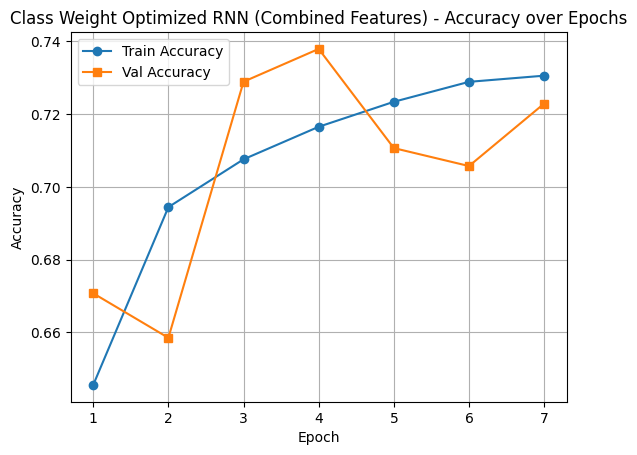

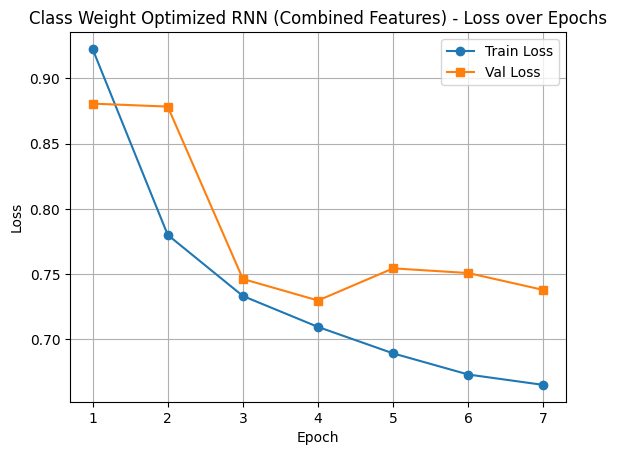

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

📊 Class Weight Optimized RNN (Combined Features) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.70      0.76      0.73      3768
       fraud_scam_identity_theft       0.64      0.76      0.70       828
    incorrect_info_credit_report       0.85      0.75      0.80      4143
threatened_negative_legal_action       0.58      0.42      0.49      1124
  trouble_during_payment_process       0.81      0.95      0.87      1791

                        accuracy                           0.75     11654
                       macro avg       0.72      0.73      0.72     11654
                    weighted avg       0.75      0.75      0.75     11654



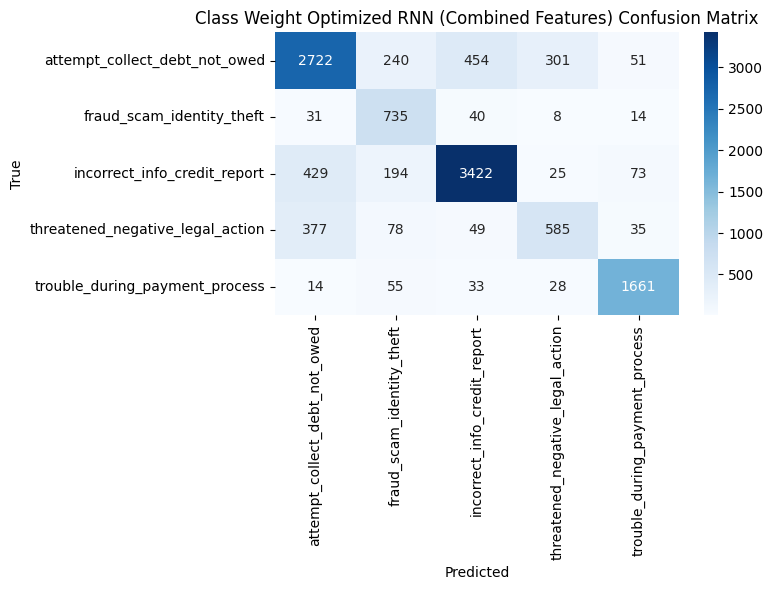

In [ ]:
# Class Weight Optimized RNN Training on Combined Features - Variation 2

# (timesteps, features_per_timestep)
input_shape = (X_seq_combined_train_final.shape[1], X_seq_combined_train_final.shape[2])
num_classes = len(np.unique(y_train_final))

# Compute class weights
unique_classes = np.unique(y_train_final)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_final
)
class_weights = dict(zip(unique_classes, class_weights_array))

# Build RNN model with LSTM + L2 regularization on Dense layer
rnn_comb_model = Sequential([
    LSTM(128, input_shape=input_shape, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(num_classes, activation='softmax')
])

rnn_comb_model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ModelCheckpoint callback
checkpoint_path = "/content/drive/MyDrive/FYP/Models/RNN_Comb_CWO.h5"
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=1,
    restore_best_weights=True
)


# Train model with class weights and callbacks
history_rnn_comb = rnn_comb_model.fit(
    X_seq_combined_train_final, y_train_onehot_final,
    validation_data=(X_seq_combined_val, y_val_onehot),
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint, early_stop],
    class_weight=class_weights
)

# Show model summary
rnn_comb_model.summary()

# Plot training history
plot_history(history_rnn_comb, "Class Weight Optimized RNN (Combined Features)")

# Generate predictions on test set
rnn_comb_preds = np.argmax(rnn_comb_model.predict(X_test_seq_combined), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 Class Weight Optimized RNN (Combined Features) Report")
print(classification_report(y_true, rnn_comb_preds, target_names=class_names))
plot_cm(y_true, rnn_seq_preds, "Class Weight Optimized RNN (Combined Features) Confusion Matrix")

## Graph Neural Network (GCN)

### Variation 1: TF-IDF Weighted Word2Vec Features

Epoch 001: val_accuracy = 0.1838, val_loss improved to 1.6096, saving model...
Epoch 002: val_accuracy = 0.3426, val_loss improved to 1.6092, saving model...
Epoch 003: val_accuracy = 0.1791, val_loss improved to 1.6086, saving model...
Epoch 004: val_accuracy = 0.1103, val_loss = 1.6089
Epoch 005: val_accuracy = 0.1411, val_loss improved to 1.6083, saving model...
Epoch 006: val_accuracy = 0.2119, val_loss improved to 1.6079, saving model...
Epoch 007: val_accuracy = 0.2733, val_loss improved to 1.6071, saving model...
Epoch 008: val_accuracy = 0.2842, val_loss improved to 1.6064, saving model...
Epoch 009: val_accuracy = 0.2441, val_loss = 1.6065
Epoch 010: val_accuracy = 0.2166, val_loss improved to 1.6058, saving model...
Epoch 011: val_accuracy = 0.1888, val_loss improved to 1.6053, saving model...
Epoch 012: val_accuracy = 0.2003, val_loss improved to 1.6050, saving model...
Epoch 013: val_accuracy = 0.2773, val_loss improved to 1.6047, saving model...
Epoch 014: val_accuracy = 0

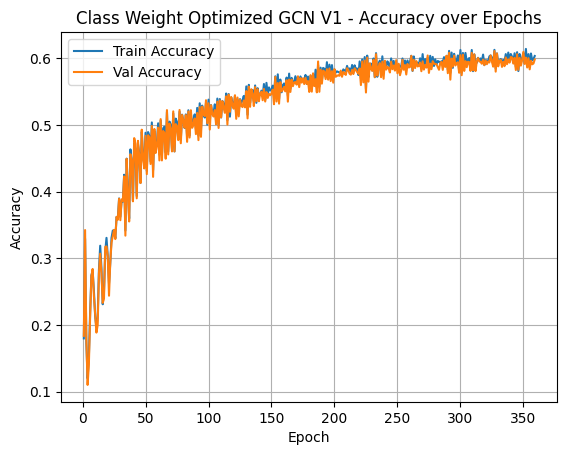

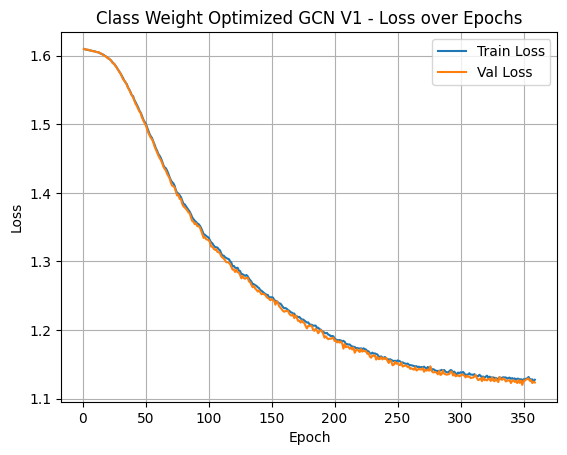


📊 Class Weight Optimized GCN V1 Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.71      0.38      0.50      3768
       fraud_scam_identity_theft       0.47      0.79      0.59       828
    incorrect_info_credit_report       0.73      0.77      0.75      4143
threatened_negative_legal_action       0.32      0.49      0.39      1124
  trouble_during_payment_process       0.74      0.91      0.82      1791

                        accuracy                           0.64     11654
                       macro avg       0.60      0.67      0.61     11654
                    weighted avg       0.67      0.64      0.63     11654



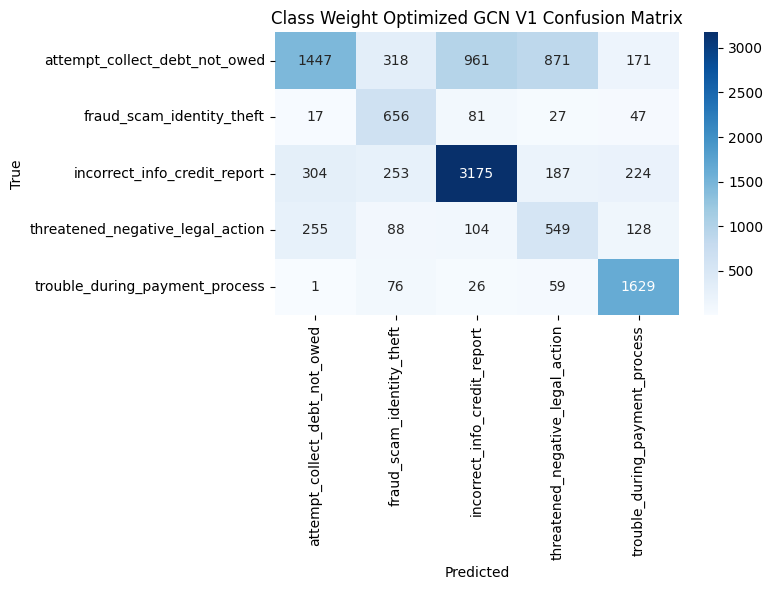

In [ ]:
# Class Weight Optimized GCN V1

# Concatenate for full graph using TF-IDF weighted Word2Vec features
X_all = np.vstack([tfidf_w2v_train, tfidf_w2v_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(tfidf_w2v_train_final)
num_val = len(tfidf_w2v_val)
num_train_total = num_train_final + num_val
num_test = len(tfidf_w2v_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Construct graph using KNN (only for adjacency, not learning)
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v1 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v1 = NormalizeFeatures()(data_gcn_v1)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v1.train_mask = train_mask
data_gcn_v1.val_mask = val_mask
data_gcn_v1.test_mask = test_mask

# GCN Model Definition
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.dropout = nn.Dropout(0.5)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v1.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = GCN(in_dim, hidden_dim, out_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data_gcn_v1 = data_gcn_v1.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4) # 0.0005

# Directory to save models
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "GCN_V1_CWO.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None
early_stopping_patience = 10
no_improve_epochs = 0

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v1)
    loss = F.cross_entropy(
        out[data_gcn_v1.train_mask],
        data_gcn_v1.y[data_gcn_v1.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v1.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v1.y[data_gcn_v1.train_mask]).sum().item() / data_gcn_v1.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v1.val_mask]
        val_labels = data_gcn_v1.y[data_gcn_v1.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels, weight=class_weights)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v1.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        no_improve_epochs = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        no_improve_epochs += 1
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

    if no_improve_epochs >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs with no improvement in val_loss.")
        break

print(f"Best model saved to: {best_model_path} with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "Class Weight Optimized GCN V1")

# Generate predictions on test mask
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v1)
    preds = out.argmax(dim=1)[data_gcn_v1.test_mask].cpu().numpy()
y_true_gcn_v1 = data_gcn_v1.y[data_gcn_v1.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 Class Weight Optimized GCN V1 Classification Report")
print(classification_report(y_true_gcn_v1, preds, target_names=class_names))
plot_cm(y_true_gcn_v1, preds, "Class Weight Optimized GCN V1 Confusion Matrix")

### Variation 2: Combined TF-IDF Weighted Word2Vec + LDA Features

Epoch 001: val_accuracy = 0.0892, val_loss improved to 1.6099, saving model...
Epoch 002: val_accuracy = 0.1744, val_loss = 1.6101
Epoch 003: val_accuracy = 0.1120, val_loss improved to 1.6088, saving model...
Epoch 004: val_accuracy = 0.1463, val_loss improved to 1.6083, saving model...
Epoch 005: val_accuracy = 0.1364, val_loss improved to 1.6081, saving model...
Epoch 006: val_accuracy = 0.1896, val_loss improved to 1.6074, saving model...
Epoch 007: val_accuracy = 0.2864, val_loss improved to 1.6071, saving model...
Epoch 008: val_accuracy = 0.2220, val_loss = 1.6072
Epoch 009: val_accuracy = 0.1817, val_loss improved to 1.6069, saving model...
Epoch 010: val_accuracy = 0.1802, val_loss improved to 1.6060, saving model...
Epoch 011: val_accuracy = 0.2023, val_loss improved to 1.6054, saving model...
Epoch 012: val_accuracy = 0.2252, val_loss improved to 1.6049, saving model...
Epoch 013: val_accuracy = 0.3147, val_loss improved to 1.6037, saving model...
Epoch 014: val_accuracy = 0

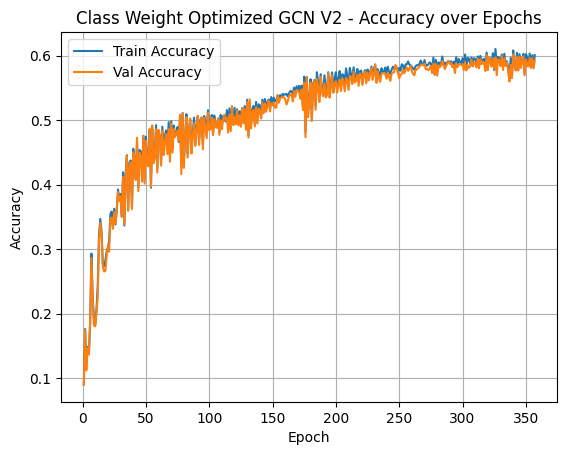

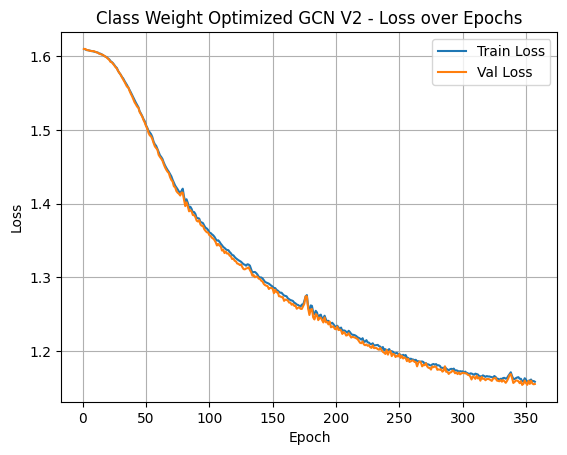


📊 Class Weight Optimized GCN V2 Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.71      0.40      0.51      3768
       fraud_scam_identity_theft       0.42      0.81      0.55       828
    incorrect_info_credit_report       0.73      0.76      0.74      4143
threatened_negative_legal_action       0.33      0.46      0.38      1124
  trouble_during_payment_process       0.77      0.88      0.82      1791

                        accuracy                           0.63     11654
                       macro avg       0.59      0.66      0.60     11654
                    weighted avg       0.67      0.63      0.63     11654



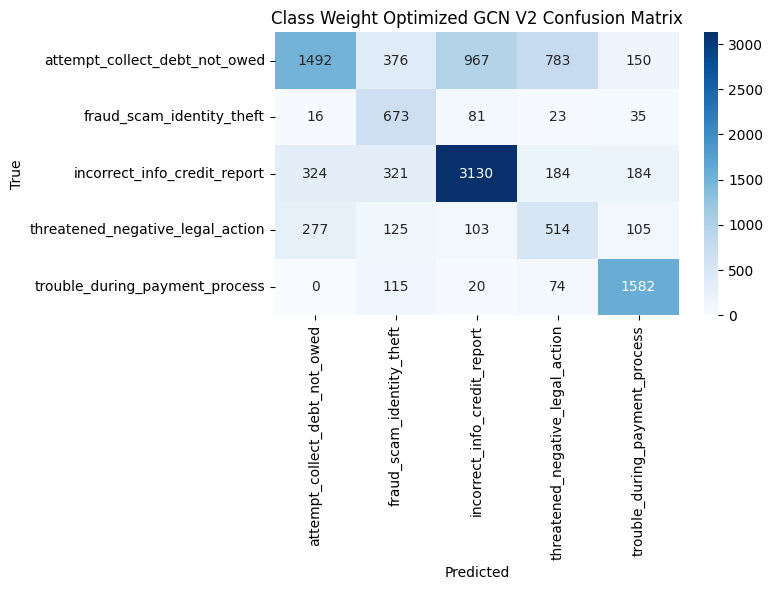

In [ ]:
# Class Weight Optimized GCN V2

# Concatenate for full graph using combined TF-IDF weighted Word2Vec + LDA features
X_all = np.vstack([combined_train, combined_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(combined_train_final)
num_val = len(combined_val)
num_train_total = num_train_final + num_val
num_test = len(combined_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Construct graph using KNN (only for adjacency, not learning)
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v2 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v2 = NormalizeFeatures()(data_gcn_v2)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v2.train_mask = train_mask
data_gcn_v2.val_mask = val_mask
data_gcn_v2.test_mask = test_mask

# GCN Model Definition
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.dropout = nn.Dropout(0.5)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v2.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = GCN(in_dim, hidden_dim, out_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data_gcn_v2 = data_gcn_v2.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Directory to save models
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "GCN_V2_CWO.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None
early_stopping_patience = 10
no_improve_epochs = 0

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v2)
    loss = F.cross_entropy(
        out[data_gcn_v2.train_mask],
        data_gcn_v2.y[data_gcn_v2.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v2.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v2.y[data_gcn_v2.train_mask]).sum().item() / data_gcn_v2.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v2.val_mask]
        val_labels = data_gcn_v2.y[data_gcn_v2.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels, weight=class_weights)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v2.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        no_improve_epochs = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        no_improve_epochs += 1
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

    if no_improve_epochs >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs with no improvement in val_loss.")
        break

# Save final model
print(f"Best model saved to: {best_model_path} with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "Class Weight Optimized GCN V2")

# Generate predictions on test mask
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v2)
    preds = out.argmax(dim=1)[data_gcn_v2.test_mask].cpu().numpy()
y_true_gcn_v2 = data_gcn_v2.y[data_gcn_v2.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 Class Weight Optimized GCN V2 Classification Report")
print(classification_report(y_true_gcn_v2, preds, target_names=class_names))
plot_cm(y_true_gcn_v2, preds, "Class Weight Optimized GCN V2 Confusion Matrix")

# Model Refinement

RNN V1 (Padded Sequence) and CNN V1 (Padded Sequence) are selected to proceed further due to their high overall accuracy and performance in handling minority classes, optimization effort on model architecture are made to increase performance. GCN V1 and GCN V2 are both selected to further experiment the graph based model potential

## Pre-trained tokenizer & Word2vec model as Embedding Layer for CNN & RNN

In [ ]:
# Build embedding matrix from the pre-trained tokenizer and Word2Vec model
embedding_dim = w2v_model.vector_size
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

## CNN (Embedding Matrix) - Variation 1: Padded Sequence

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5307 - loss: 2.5728
Epoch 1: val_loss improved from inf to 1.09681, saving model to /content/drive/MyDrive/FYP/Models/CNN_Seq_Embed.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5308 - loss: 2.5722 - val_accuracy: 0.7074 - val_loss: 1.0968
Epoch 2/20
1300/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6945 - loss: 1.0445
Epoch 2: val_loss improved from 1.09681 to 0.94651, saving model to /content/drive/MyDrive/FYP/Models/CNN_Seq_Embed.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6945 - loss: 1.0441 - val_accuracy: 0.7372 - val_loss: 0.9465
Epoch 3/20
1304/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7073 - loss: 0.9479
Epoch 3: val_loss improved from 0.94651 to 0.87753, saving model to /content/drive/MyDrive/FYP/Models/CNN_Seq_Embed.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7073 - loss: 0.9478 - val_accuracy: 0.7589 - val_loss: 0.8775
Epoch 4/20
1309/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7194 - loss: 0.9027
Epoch 4: val_loss did not improve from 0.87753
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7194 - loss: 0.9027 - val_accuracy: 0.7405 - val_loss: 0.9167
Epoch 5/20
1298/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7300 - loss: 0.8796
Epoch 5: val_loss did not improve from 0.87753
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7300 - loss: 0.8797 - val_accuracy: 0.7396 - val_loss: 0.9072
Epoch 6/20
1306/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7366 - loss: 0.8784
Epoch 6: val_loss did not improve from 0.87753
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7366 - loss: 0.8784 - val_accuracy: 0.7432 - val_loss: 0.9106
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 100)       │     1,489,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 96, 128)        │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,687,229 (17.88 MB)

 Trainable params: 1,562,409 (5.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,124,820 (11.92 MB)

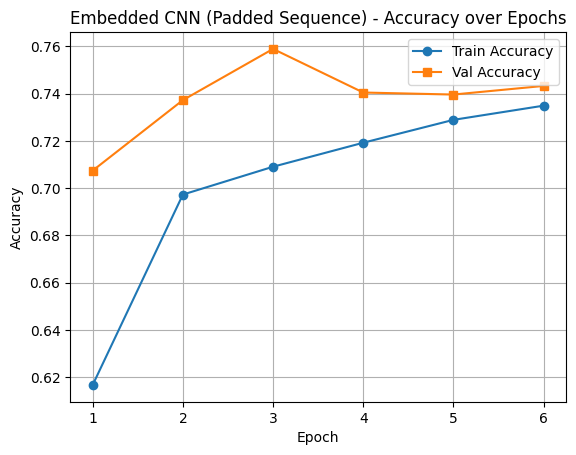

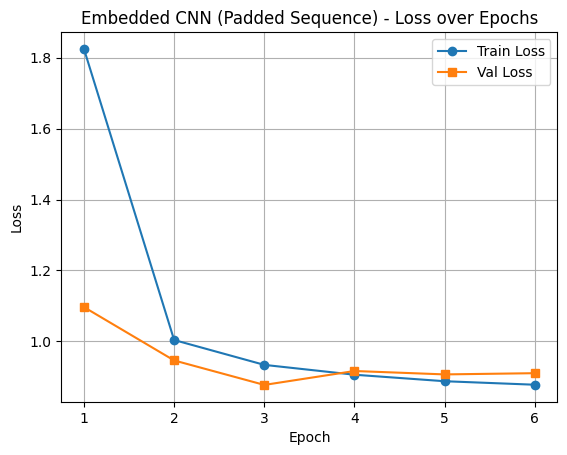

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

📊 Embedded CNN (Padded Sequence) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.77      0.65      0.70      3768
       fraud_scam_identity_theft       0.59      0.87      0.71       828
    incorrect_info_credit_report       0.80      0.84      0.82      4143
threatened_negative_legal_action       0.56      0.56      0.56      1124
  trouble_during_payment_process       0.90      0.91      0.91      1791

                        accuracy                           0.76     11654
                       macro avg       0.73      0.77      0.74     11654
                    weighted avg       0.77      0.76      0.76     11654



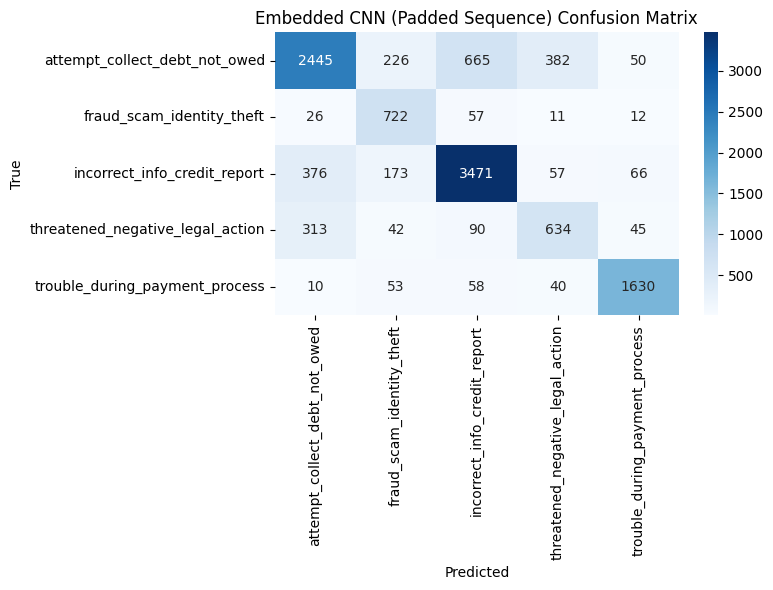

In [ ]:
# Embedded Matrix CNN Training on Padded Sequence - Variation 1

# Parameters
maxlen = X_train_pad_final.shape[1]
num_classes = len(np.unique(y_train_final))

# Compute class weights
unique_classes = np.unique(y_train_final)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_final
)
class_weights = dict(zip(unique_classes, class_weights_array))

# Build CNN model with L2 regularization and dropout
cnn_seq_model = Sequential([
    Embedding(
        input_dim=embedding_matrix.shape[0],
        output_dim=embedding_matrix.shape[1],
        weights=[embedding_matrix],
        input_length=maxlen,
        trainable=True
    ),
    Conv1D(filters=128, kernel_size=5, activation='relu', kernel_regularizer=l2(0.01)),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(num_classes, activation='softmax')
])

cnn_seq_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Checkpoint to save best model
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/FYP/Models/CNN_Seq_Embed.h5",
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history_cnn_seq = cnn_seq_model.fit(
    X_train_pad_final, y_train_onehot_final,
    validation_data=(X_val_pad, y_val_onehot),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)

# Print model architecture summary
cnn_seq_model.summary()

# Plot training history
plot_history(history_cnn_seq, "Embedded CNN (Padded Sequence)")


# Generate predictions on test set
cnn_seq_preds = np.argmax(cnn_seq_model.predict(X_test_pad), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 Embedded CNN (Padded Sequence) Report")
print(classification_report(y_true, cnn_seq_preds, target_names=class_names))
plot_cm(y_true, cnn_seq_preds, "Embedded CNN (Padded Sequence) Confusion Matrix")

## RNN (Embedding Matrix) - Variation 1: Padded Sequence

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1311/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4275 - loss: 1.4184
Epoch 1: val_loss improved from inf to 1.07572, saving model to /content/drive/MyDrive/FYP/Models/RNN_Seq_Embed.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4276 - loss: 1.4182 - val_accuracy: 0.5560 - val_loss: 1.0757
Epoch 2/20
1310/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5365 - loss: 1.1102
Epoch 2: val_loss did not improve from 1.07572
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.5365 - loss: 1.1103 - val_accuracy: 0.2205 - val_loss: 1.5386
Epoch 3/20
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3478 - loss: 1.3503
Epoch 3: val_loss improved from 1.07572 to 0.95342, saving model to /content/drive/MyDrive/FYP/Models/RNN_Seq_Embed.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.3478 - loss: 1.3502 - val_accuracy: 0.6051 - val_loss: 0.9534
Epoch 4/20
1311/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6135 - loss: 0.8887
Epoch 4: val_loss improved from 0.95342 to 0.82106, saving model to /content/drive/MyDrive/FYP/Models/RNN_Seq_Embed.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.6136 - loss: 0.8886 - val_accuracy: 0.6720 - val_loss: 0.8211
Epoch 5/20
1310/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7148 - loss: 0.7143
Epoch 5: val_loss improved from 0.82106 to 0.71210, saving model to /content/drive/MyDrive/FYP/Models/RNN_Seq_Embed.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 100)       │     1,489,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,846,589 (18.49 MB)

 Trainable params: 1,615,529 (6.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,231,060 (12.33 MB)

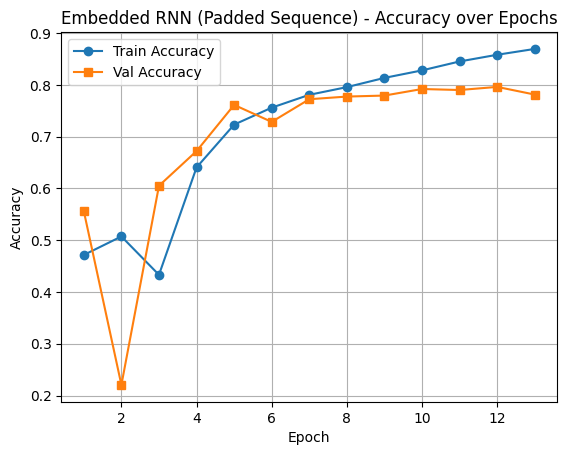

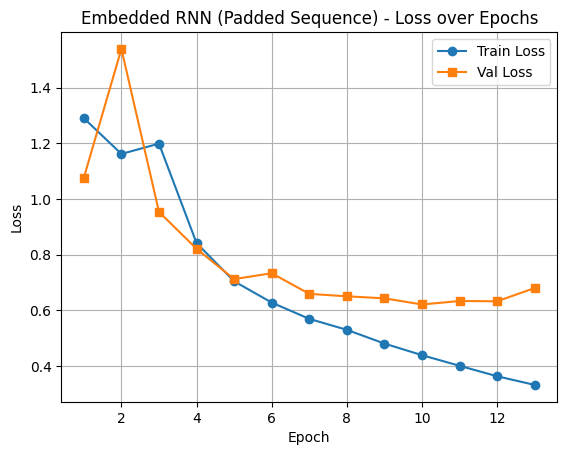

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

📊 Embedded RNN (Embedded Sequence) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.75      0.77      0.76      3768
       fraud_scam_identity_theft       0.69      0.85      0.76       828
    incorrect_info_credit_report       0.88      0.80      0.84      4143
threatened_negative_legal_action       0.57      0.60      0.59      1124
  trouble_during_payment_process       0.90      0.92      0.91      1791

                        accuracy                           0.79     11654
                       macro avg       0.76      0.79      0.77     11654
                    weighted avg       0.80      0.79      0.80     11654



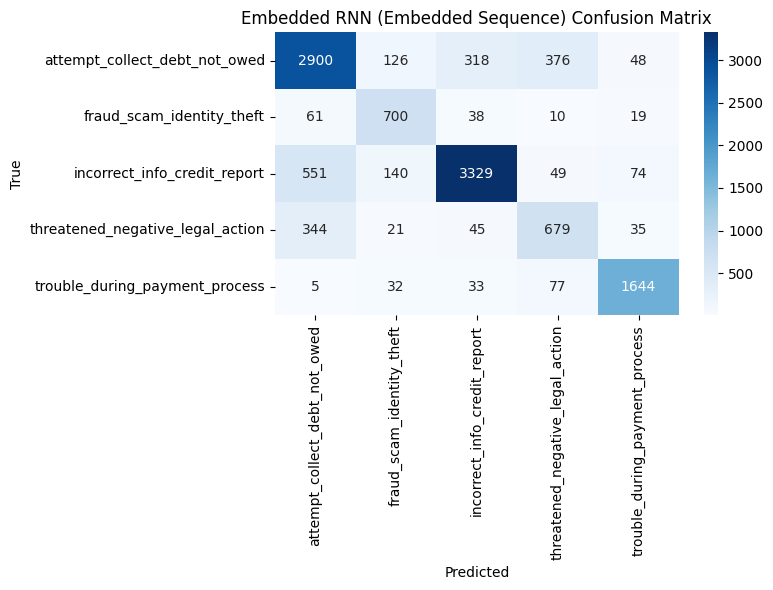

In [ ]:
# Embedded Matrix RNN Training on Padded Sequence - Variation 1

# Parameters
maxlen = X_train_pad.shape[1]
num_classes = len(np.unique(y_train_final))

# Compute class weights
unique_classes = np.unique(y_train_final)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_final
)
class_weights = dict(zip(unique_classes, class_weights_array))

# Build RNN model with LSTM + L2 regularization on Dense layers
rnn_seq_model = Sequential([
    Embedding(
      input_dim=embedding_matrix.shape[0],
      output_dim=embedding_matrix.shape[1],
      weights=[embedding_matrix],
      input_length=maxlen,
      trainable=True
    ),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(num_classes, activation='softmax')
])

rnn_seq_model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks: ModelCheckpoint and EarlyStopping
checkpoint_path = "/content/drive/MyDrive/FYP/Models/RNN_Seq_Embed.h5"
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# Train the model with class weights and callbacks
history_rnn_seq = rnn_seq_model.fit(
    X_train_pad_final, y_train_onehot_final,
    validation_data=(X_val_pad, y_val_onehot),
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint, early_stop],
    class_weight=class_weights
)

# Print model architecture summary
rnn_seq_model.summary()

# Plot training history
plot_history(history_rnn_seq, "Embedded RNN (Padded Sequence)")


# Generate predictions on test set
rnn_seq_preds = np.argmax(rnn_seq_model.predict(X_test_pad), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 Embedded RNN (Embedded Sequence) Report")
print(classification_report(y_true, rnn_seq_preds, target_names=class_names))
plot_cm(y_true, rnn_seq_preds, "Embedded RNN (Embedded Sequence) Confusion Matrix")

To enhance the RNN model, Bidirectional LSTM layer is employed, added batch normalization and learning rate scheduler, label smoothing

## BiLSTM (Batch Normalization + LR Scheduler + Label Smoothing) - Variation 1: Padded Sequence

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1311/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6044 - loss: 1.2503
Epoch 1: val_loss improved from inf to 1.05014, saving model to /content/drive/MyDrive/FYP/Models/BiLSTM_RNN_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6045 - loss: 1.2501 - val_accuracy: 0.7143 - val_loss: 1.0501 - learning_rate: 0.0010
Epoch 2/20
1309/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7439 - loss: 0.9319
Epoch 2: val_loss improved from 1.05014 to 0.96353, saving model to /content/drive/MyDrive/FYP/Models/BiLSTM_RNN_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7439 - loss: 0.9318 - val_accuracy: 0.7357 - val_loss: 0.9635 - learning_rate: 0.0010
Epoch 3/20
1310/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7729 - loss: 0.8423
Epoch 3: val_loss improved from 0.96353 to 0.89446, saving model to /content/drive/MyDrive/FYP/Models/BiLSTM_RNN_Seq.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 100)       │     1,489,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,223,421 (19.93 MB)

 Trainable params: 1,741,097 (6.64 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 3,482,196 (13.28 MB)

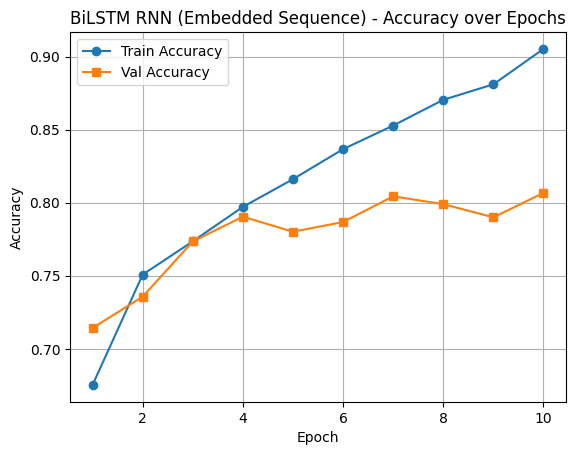

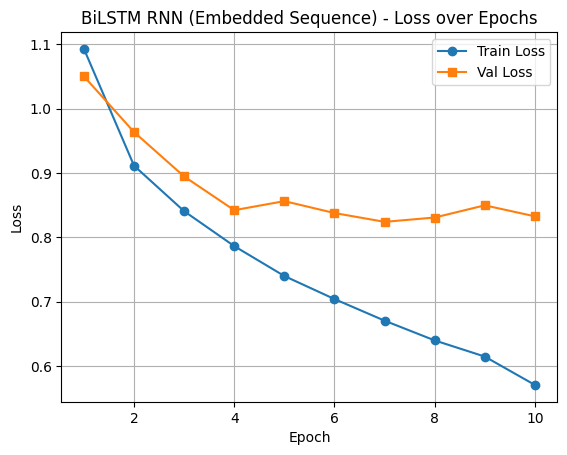

365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

📊 BiLSTM RNN (Embedded Sequence) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.79      0.75      0.77      3768
       fraud_scam_identity_theft       0.73      0.85      0.78       828
    incorrect_info_credit_report       0.89      0.84      0.86      4143
threatened_negative_legal_action       0.54      0.65      0.59      1124
  trouble_during_payment_process       0.91      0.93      0.92      1791

                        accuracy                           0.81     11654
                       macro avg       0.77      0.80      0.78     11654
                    weighted avg       0.81      0.81      0.81     11654



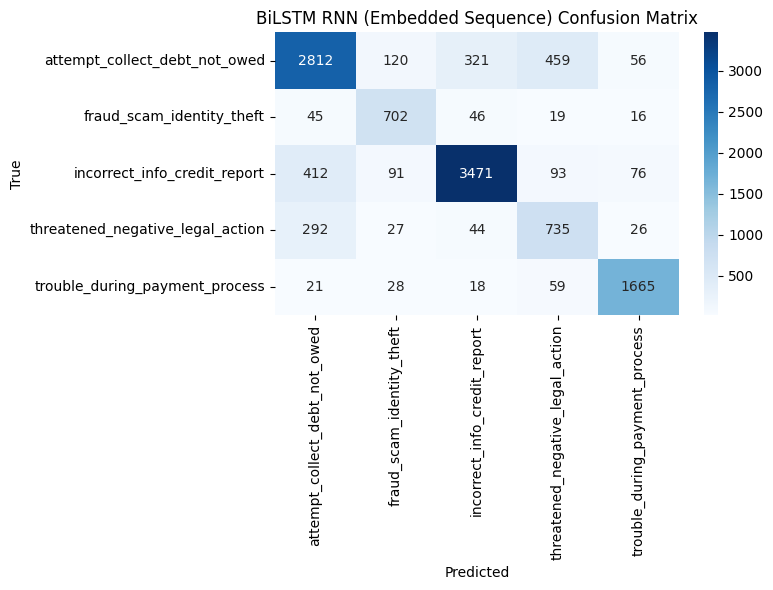

In [ ]:
# Embedded Matrix RNN (BiLSTM + Batch Normalization + LR Scheduler + Label Smoothing)

# Parameters
vocab_size = embedding_matrix.shape[0]
embedding_dim = embedding_matrix.shape[1]
maxlen = X_train_pad_final.shape[1]
num_classes = len(np.unique(y_train_final))

# Compute class weights
unique_classes = np.unique(y_train_final)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_final
)
class_weights = dict(zip(unique_classes, class_weights_array))

# Define model
rnn_seq_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=True),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dense(num_classes, activation='softmax')
])

# Compile model with label smoothing
rnn_seq_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/FYP/Models/BiLSTM_RNN_Seq.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Training
history_rnn_seq = rnn_seq_model.fit(
    X_train_pad_final, y_train_onehot_final,
    validation_data=(X_val_pad, y_val_onehot),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

print("")
rnn_seq_model.summary()

# Plot epoch performance
plot_history(history_rnn_seq, "BiLSTM RNN (Embedded Sequence)")


# Generate Predictions & Plot Classification Report & Confusion Matrix
rnn_seq_preds = np.argmax(rnn_seq_model.predict(X_test_pad), axis=1)
y_true = y_test
class_names = label_encoder.classes_
print("\n📊 BiLSTM RNN (Embedded Sequence) Report")
print(classification_report(y_true, rnn_seq_preds, target_names=class_names))
plot_cm(y_true, rnn_seq_preds, "BiLSTM RNN (Embedded Sequence) Confusion Matrix")

## BiLSTM (Attention Layer) - Variation 1: Padded Sequence

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1311/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6455 - loss: 1.1605
Epoch 1: val_loss improved from inf to 0.95034, saving model to /content/drive/MyDrive/FYP/Models/BiLSTM_RNN_Attention_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6456 - loss: 1.1603 - val_accuracy: 0.7505 - val_loss: 0.9503 - learning_rate: 0.0010
Epoch 2/20
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7566 - loss: 0.8999
Epoch 2: val_loss improved from 0.95034 to 0.88408, saving model to /content/drive/MyDrive/FYP/Models/BiLSTM_RNN_Attention_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7566 - loss: 0.8999 - val_accuracy: 0.7649 - val_loss: 0.8841 - learning_rate: 0.0010
Epoch 3/20
1310/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7863 - loss: 0.8059
Epoch 3: val_loss improved from 0.88408 to 0.84999, saving model to /content/drive/MyDrive/FYP/Models/BiLSTM_RNN_Attention_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.7863 - loss: 0.8059 - val_accuracy: 0.7735 - val_loss: 0.8500 - learning_rate: 0.0010
Epoch 4/20
1308/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8120 - loss: 0.7445
Epoch 4: val_loss did not improve from 0.84999
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.8120 - loss: 0.7445 - val_accuracy: 0.7692 - val_loss: 0.8574 - learning_rate: 0.0010
Epoch 5/20
1309/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8199 - loss: 0.7267
Epoch 5: val_loss improved from 0.84999 to 0.83998, saving model to /content/drive/MyDrive/FYP/Models/BiLSTM_RNN_Attention_Seq.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 100)       │     1,489,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 256)            │           356 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,224,489 (19.93 MB)

 Trainable params: 1,741,453 (6.64 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 3,482,908 (13.29 MB)

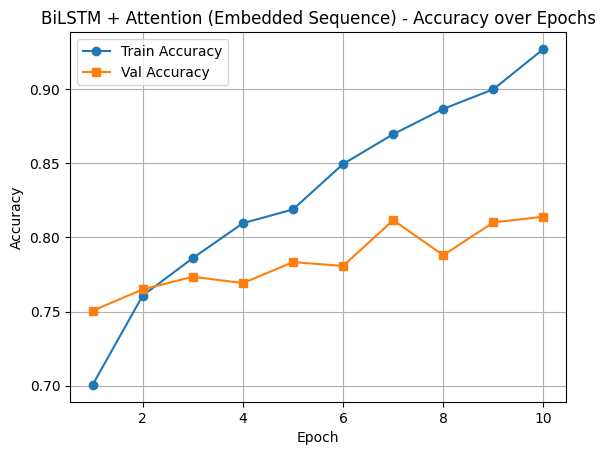

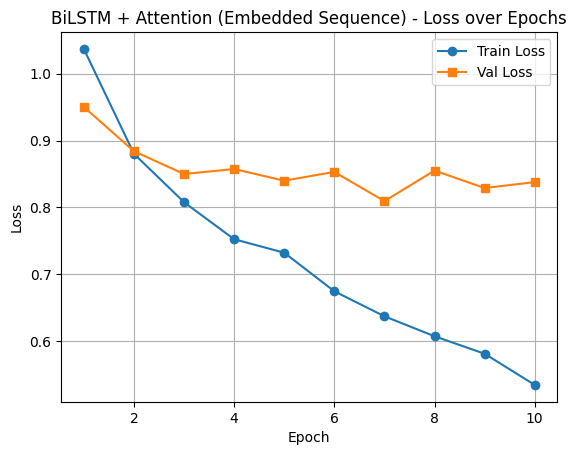

365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

📊 BiLSTM + Attention (Embedded Sequence) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.80      0.75      0.77      3768
       fraud_scam_identity_theft       0.72      0.84      0.77       828
    incorrect_info_credit_report       0.87      0.86      0.87      4143
threatened_negative_legal_action       0.59      0.61      0.60      1124
  trouble_during_payment_process       0.90      0.95      0.92      1791

                        accuracy                           0.81     11654
                       macro avg       0.78      0.80      0.79     11654
                    weighted avg       0.81      0.81      0.81     11654



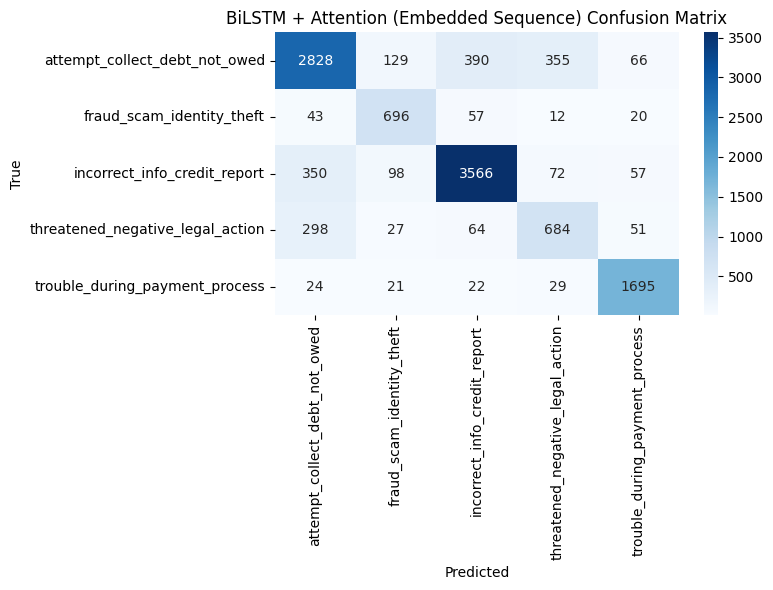

In [ ]:
# BiLSTM + Attention Layer

# Define custom attention layer
class Attention(Layer):
    def __init__(self, return_attention=False, **kwargs):
        self.return_attention = return_attention
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros", trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, inputs):
        e = K.tanh(K.dot(inputs, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = inputs * a
        output = K.sum(output, axis=1)
        if self.return_attention:
            return [output, a]
        return output

# Parameters
vocab_size = embedding_matrix.shape[0]
embedding_dim = embedding_matrix.shape[1]
maxlen = X_train_pad_final.shape[1]
num_classes = len(np.unique(y_train_final))

# Compute class weights
unique_classes = np.unique(y_train_final)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_final
)
class_weights = dict(zip(unique_classes, class_weights_array))

# Define Model
input_layer = Input(shape=(maxlen,))
embedding = Embedding(input_dim=vocab_size,
                      output_dim=embedding_dim,
                      weights=[embedding_matrix],
                      input_length=maxlen,
                      trainable=True)(input_layer)

bilstm = Bidirectional(LSTM(128, return_sequences=True))(embedding)
attention = Attention()(bilstm)
drop1 = Dropout(0.5)(attention)
dense = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(drop1)
bn = BatchNormalization()(dense)
output = Dense(num_classes, activation='softmax')(bn)

rnn_att_model = Model(inputs=input_layer, outputs=output)

# Compile
rnn_att_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/FYP/Models/BiLSTM_RNN_Attention_Seq.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Train model
history_rnn_att = rnn_att_model.fit(
    X_train_pad_final, y_train_onehot_final,
    validation_data=(X_val_pad, y_val_onehot),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

print("")
rnn_att_model.summary()

# Plot epoch performance
plot_history(history_rnn_att, "BiLSTM + Attention (Embedded Sequence)")

# Generate predictions on test set
rnn_att_preds = np.argmax(rnn_att_model.predict(X_test_pad), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 BiLSTM + Attention (Embedded Sequence) Report")
print(classification_report(y_true, rnn_att_preds, target_names=class_names))
plot_cm(y_true, rnn_att_preds, "BiLSTM + Attention (Embedded Sequence) Confusion Matrix")

## CNN + BiLSTM Hybrid Model - Variation 1: Padded Sequence

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5744 - loss: 1.2803
Epoch 1: val_loss improved from inf to 0.97716, saving model to /content/drive/MyDrive/FYP/Models/CNN_BiLSTM_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.5745 - loss: 1.2802 - val_accuracy: 0.7488 - val_loss: 0.9772 - learning_rate: 0.0010
Epoch 2/20
1309/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7376 - loss: 0.9491
Epoch 2: val_loss improved from 0.97716 to 0.90896, saving model to /content/drive/MyDrive/FYP/Models/CNN_BiLSTM_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - accuracy: 0.7376 - loss: 0.9491 - val_accuracy: 0.7593 - val_loss: 0.9090 - learning_rate: 0.0010
Epoch 3/20
1310/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7580 - loss: 0.8701
Epoch 3: val_loss improved from 0.90896 to 0.85323, saving model to /content/drive/MyDrive/FYP/Models/CNN_BiLSTM_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.7580 - loss: 0.8701 - val_accuracy: 0.7827 - val_loss: 0.8532 - learning_rate: 0.0010
Epoch 4/20
1311/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7733 - loss: 0.8258
Epoch 4: val_loss did not improve from 0.85323
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.7734 - loss: 0.8258 - val_accuracy: 0.7561 - val_loss: 0.8897 - learning_rate: 0.0010
Epoch 5/20
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7890 - loss: 0.7887
Epoch 5: val_loss did not improve from 0.85323

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.7890 - loss: 0.7887 - val_accuracy: 0.7606 - val_loss: 0.8611 - learning_rate: 0.0010
Epoch 6/20
1309/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8086 - loss: 0.7384
Epoch 6: val_loss improved from 0.85323 to 0.81138, saving model to /content/drive/MyDrive/FYP/Models/CNN_BiLSTM_Seq.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 100)       │     1,489,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 100, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 100, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,502,845 (20.99 MB)

 Trainable params: 1,834,153 (7.00 MB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 3,668,308 (13.99 MB)

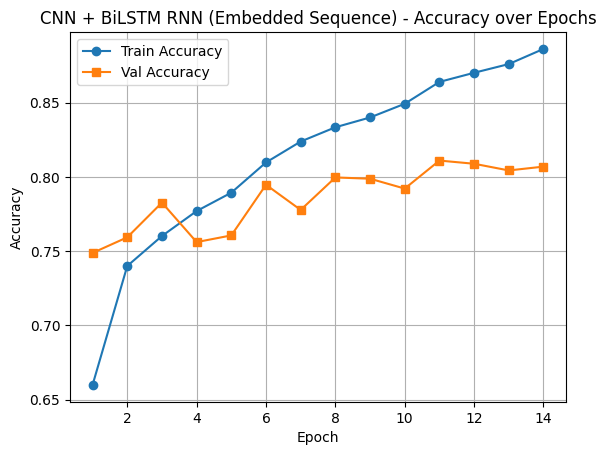

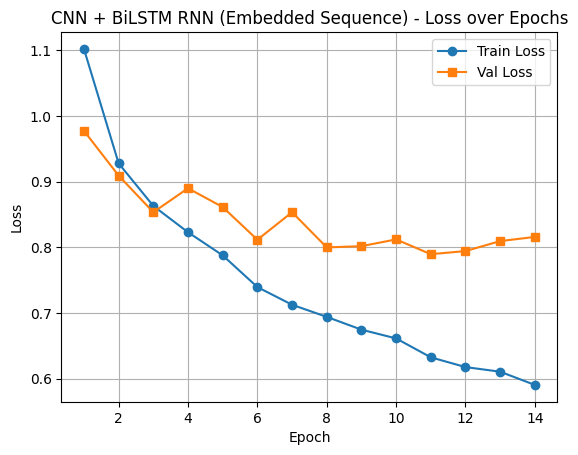

365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

📊 CNN + BiLSTM RNN (Embedded Sequence) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.80      0.75      0.78      3768
       fraud_scam_identity_theft       0.69      0.87      0.77       828
    incorrect_info_credit_report       0.89      0.85      0.87      4143
threatened_negative_legal_action       0.59      0.65      0.62      1124
  trouble_during_payment_process       0.91      0.95      0.93      1791

                        accuracy                           0.82     11654
                       macro avg       0.78      0.81      0.79     11654
                    weighted avg       0.82      0.82      0.82     11654



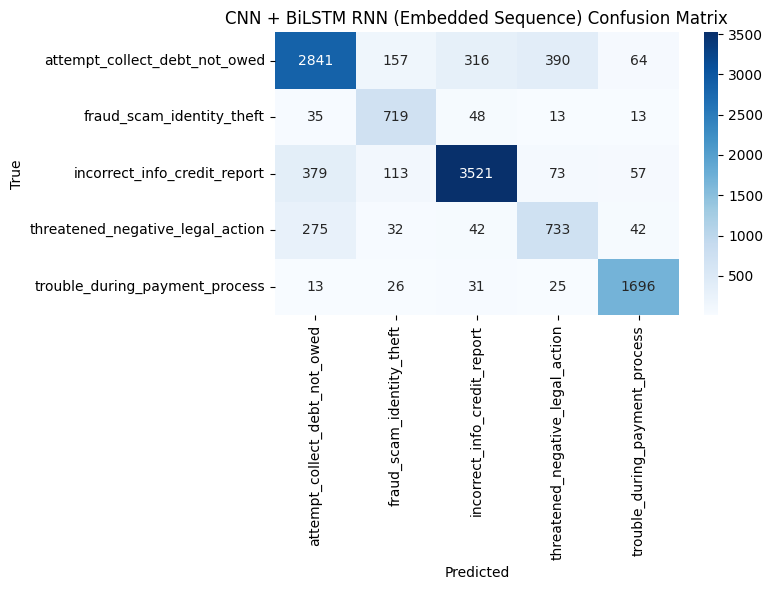

In [ ]:
# CNN + BiLSTM (Embedding Matrix + Batch Normalization + LR Scheduler + Label Smoothing)

# Parameters
vocab_size = embedding_matrix.shape[0]
embedding_dim = embedding_matrix.shape[1]
maxlen = X_train_pad_final.shape[1]
num_classes = len(np.unique(y_train_final))

# Compute class weights
unique_classes = np.unique(y_train_final)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_final
)
class_weights = dict(zip(unique_classes, class_weights_array))

# Define model
cnn_bilstm_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=True),

    Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.3),

    # Bidirectional(LSTM(128, return_sequences=False)),
    Bidirectional(LSTM(128, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(0.5),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),

    Dense(num_classes, activation='softmax')
])

# Compile model with label smoothing
cnn_bilstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/FYP/Models/CNN_BiLSTM_Seq.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Training
history_cnn_bilstm = cnn_bilstm_model.fit(
    X_train_pad_final, y_train_onehot_final,
    validation_data=(X_val_pad, y_val_onehot),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

print("")
cnn_bilstm_model.summary()

# Plot epoch performance
plot_history(history_cnn_bilstm, "CNN + BiLSTM RNN (Embedded Sequence)")

# Generate predictions on test set
cnn_bilstm_preds = np.argmax(cnn_bilstm_model.predict(X_test_pad), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 CNN + BiLSTM RNN (Embedded Sequence) Report")
print(classification_report(y_true, cnn_bilstm_preds, target_names=class_names))
plot_cm(y_true, cnn_bilstm_preds, "CNN + BiLSTM RNN (Embedded Sequence) Confusion Matrix")

## 3-Layer GCN (V1 & V2)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001: val_accuracy = 0.2424, val_loss improved to 2.1635, saving model...
Epoch 002: val_accuracy = 0.3187, val_loss improved to 1.5738, saving model...
Epoch 003: val_accuracy = 0.4560, val_loss improved to 1.3138, saving model...
Epoch 004: val_accuracy = 0.5367, val_loss improved to 1.1334, saving model...
Epoch 005: val_accuracy = 0.5682, val_loss improved to 1.0676, saving model...
Epoch 006: val_accuracy = 0.5972, val_loss improved to 1.0261, saving model...
Epoch 007: val_accuracy = 0.6182, val_loss improved to 1.0033, saving model...
Epoch 008: val_accuracy = 0.6296, val_loss improved to 0.9468, saving model...
Epoch 009: val_accuracy = 0.6212, val_loss improved to 0.9448, saving model...
Epoch 010: val_accuracy = 0.6113, val_loss improved to 0.9368, saving model...
Epoch 011: val_accuracy = 0.6077, val_loss improved to 0.9144, saving model...
Epoch 012: val_accuracy = 0.6229, val_loss improved to 0.9029, saving model...
Epoch 013: val_accuracy = 0.6270, val_loss = 0.9032


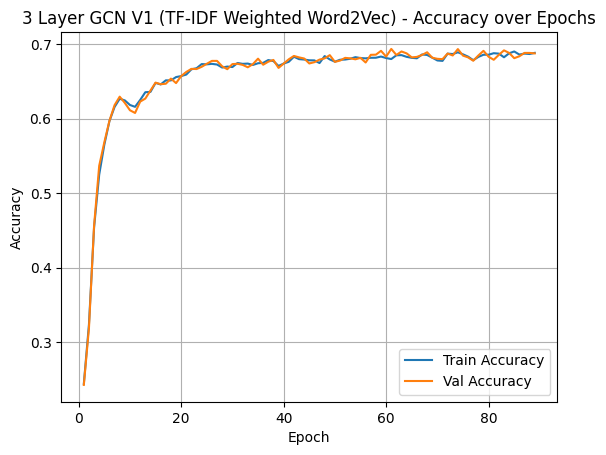

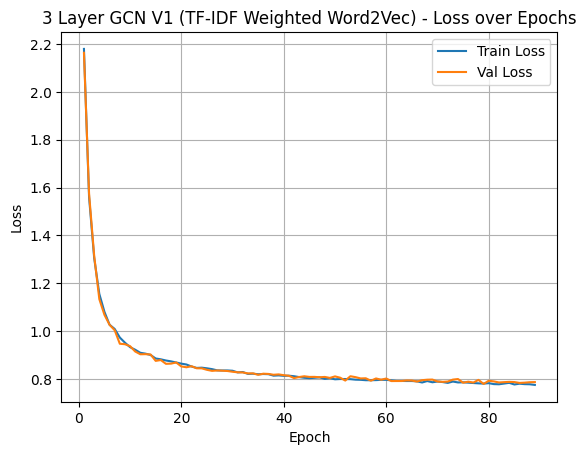


📊 3 Layer GCN V1 (TF-IDF Weighted Word2Vec) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.50      0.86      0.63      3768
       fraud_scam_identity_theft       0.81      0.27      0.40       828
    incorrect_info_credit_report       0.86      0.52      0.65      4143
threatened_negative_legal_action       0.25      0.45      0.32      1124
  trouble_during_payment_process       0.98      0.25      0.40      1791

                        accuracy                           0.56     11654
                       macro avg       0.68      0.47      0.48     11654
                    weighted avg       0.70      0.56      0.56     11654



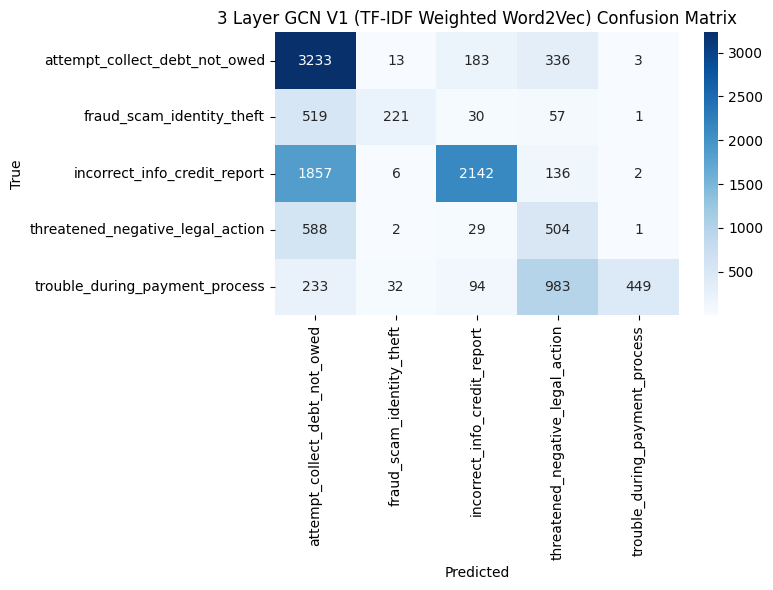

In [ ]:
# GCN V1 (3 GCN layers + LR Scheduler)

# Concatenate for full graph using TF-IDF weighted Word2Vec features
X_all = np.vstack([tfidf_w2v_train, tfidf_w2v_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(tfidf_w2v_train_final)
num_val = len(tfidf_w2v_val)
num_train_total = num_train_final + num_val
num_test = len(tfidf_w2v_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Construct graph using KNN (only for adjacency, not learning)
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v1 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v1 = NormalizeFeatures()(data_gcn_v1)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v1.train_mask = train_mask
data_gcn_v1.val_mask = val_mask
data_gcn_v1.test_mask = test_mask

# GCN Model Definition
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(0.5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v1.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = GCN(in_dim, hidden_dim, out_dim)
model = model.to(device)
data_gcn_v1 = data_gcn_v1.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Directory to save models
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "GCN_V1_3L.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None
early_stopping_patience = 10
no_improve_epochs = 0


for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v1)
    loss = F.cross_entropy(
        out[data_gcn_v1.train_mask],
        data_gcn_v1.y[data_gcn_v1.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v1.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v1.y[data_gcn_v1.train_mask]).sum().item() / data_gcn_v1.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v1.val_mask]
        val_labels = data_gcn_v1.y[data_gcn_v1.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels, weight=class_weights)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v1.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)
    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        no_improve_epochs = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        no_improve_epochs += 1
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

    if no_improve_epochs >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs with no improvement in val_loss.")
        break

print(f"Best model saved to: {best_model_path} with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "3 Layer GCN V1 (TF-IDF Weighted Word2Vec)")

# Generate predictions on test set
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v1)
    preds = out.argmax(dim=1)[data_gcn_v1.test_mask].cpu().numpy()
y_true_gcn_v1 = data_gcn_v1.y[data_gcn_v1.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 3 Layer GCN V1 (TF-IDF Weighted Word2Vec) Classification Report")
print(classification_report(y_true_gcn_v1, preds, target_names=class_names))
plot_cm(y_true_gcn_v1, preds, "3 Layer GCN V1 (TF-IDF Weighted Word2Vec) Confusion Matrix")

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001: val_accuracy = 0.0948, val_loss improved to 3.2317, saving model...
Epoch 002: val_accuracy = 0.2705, val_loss improved to 1.7860, saving model...
Epoch 003: val_accuracy = 0.4891, val_loss improved to 1.4542, saving model...
Epoch 004: val_accuracy = 0.5330, val_loss = 1.4942
Epoch 005: val_accuracy = 0.5581, val_loss improved to 1.3675, saving model...
Epoch 006: val_accuracy = 0.5972, val_loss improved to 1.2002, saving model...
Epoch 007: val_accuracy = 0.5957, val_loss improved to 1.1368, saving model...
Epoch 008: val_accuracy = 0.5813, val_loss improved to 1.0781, saving model...
Epoch 009: val_accuracy = 0.5663, val_loss improved to 1.0529, saving model...
Epoch 010: val_accuracy = 0.5697, val_loss improved to 1.0268, saving model...
Epoch 011: val_accuracy = 0.5676, val_loss improved to 1.0053, saving model...
Epoch 012: val_accuracy = 0.5725, val_loss improved to 0.9809, saving model...
Epoch 013: val_accuracy = 0.5905, val_loss improved to 0.9770, saving model...


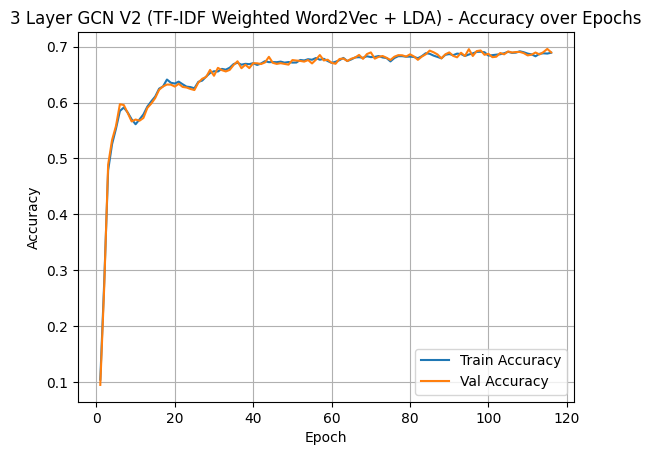

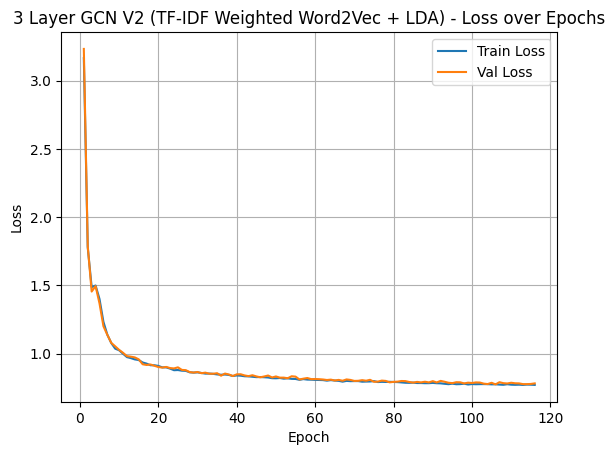


📊 3 Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.62      0.79      0.70      3768
       fraud_scam_identity_theft       0.57      0.76      0.65       828
    incorrect_info_credit_report       0.83      0.72      0.77      4143
threatened_negative_legal_action       0.57      0.28      0.37      1124
  trouble_during_payment_process       0.89      0.80      0.84      1791

                        accuracy                           0.72     11654
                       macro avg       0.70      0.67      0.67     11654
                    weighted avg       0.73      0.72      0.71     11654



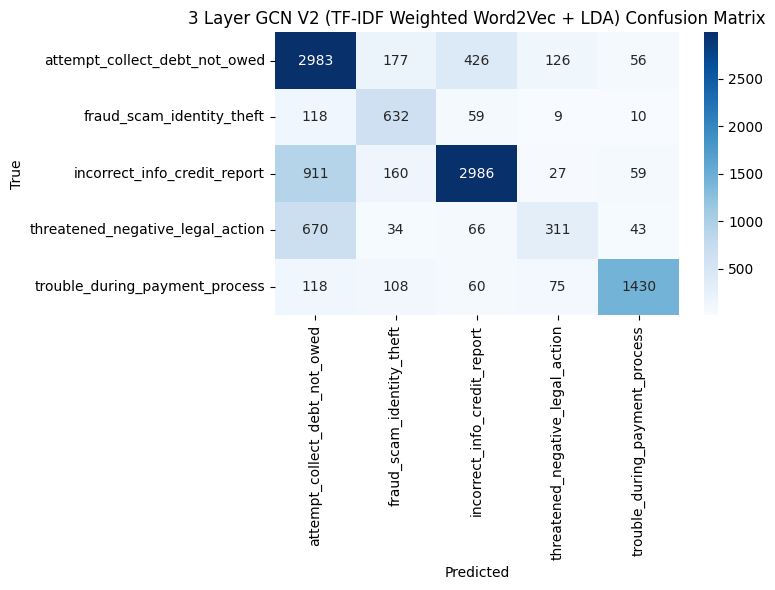

In [ ]:
# GCN V2 (3 GCN layers + LR Scheduler)

# Concatenate for full graph using combined TF-IDF weighted Word2Vec + LDA features
X_all = np.vstack([combined_train, combined_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(combined_train_final)
num_val = len(combined_val)
num_train_total = num_train_final + num_val
num_test = len(combined_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Construct graph using KNN (only for adjacency, not learning)
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v2 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v2 = NormalizeFeatures()(data_gcn_v2)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v2.train_mask = train_mask
data_gcn_v2.val_mask = val_mask
data_gcn_v2.test_mask = test_mask

# GCN Model Definition
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(0.5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v2.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = GCN(in_dim, hidden_dim, out_dim)
model = model.to(device)
data_gcn_v2 = data_gcn_v2.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Directory to save models
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "GCN_V2_3L.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None
early_stopping_patience = 10
no_improve_epochs = 0

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v2)
    loss = F.cross_entropy(
        out[data_gcn_v2.train_mask],
        data_gcn_v2.y[data_gcn_v2.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v2.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v2.y[data_gcn_v2.train_mask]).sum().item() / data_gcn_v2.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v2.val_mask]
        val_labels = data_gcn_v2.y[data_gcn_v2.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels, weight=class_weights)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v2.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)
    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        no_improve_epochs = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        no_improve_epochs += 1
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

    if no_improve_epochs >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs with no improvement in val_loss.")
        break

print(f"Best model saved to: {best_model_path} with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "3 Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA)")


# Generate predictions on test set
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v2)
    preds = out.argmax(dim=1)[data_gcn_v2.test_mask].cpu().numpy()
y_true_gcn_v2 = data_gcn_v2.y[data_gcn_v2.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 3 Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report")
print(classification_report(y_true_gcn_v2, preds, target_names=class_names))
plot_cm(y_true_gcn_v2, preds, "3 Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Confusion Matrix")

## 4-Layer GCN (V1 & V2)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001: val_accuracy = 0.1658, val_loss improved to 2.5230, saving model...
Epoch 002: val_accuracy = 0.3769, val_loss improved to 1.5451, saving model...
Epoch 003: val_accuracy = 0.5328, val_loss improved to 1.2754, saving model...
Epoch 004: val_accuracy = 0.5764, val_loss improved to 1.1386, saving model...
Epoch 005: val_accuracy = 0.5601, val_loss improved to 1.0785, saving model...
Epoch 006: val_accuracy = 0.5864, val_loss improved to 1.0141, saving model...
Epoch 007: val_accuracy = 0.5828, val_loss improved to 0.9884, saving model...
Epoch 008: val_accuracy = 0.5856, val_loss improved to 0.9748, saving model...
Epoch 009: val_accuracy = 0.5871, val_loss improved to 0.9488, saving model...
Epoch 010: val_accuracy = 0.5897, val_loss improved to 0.9443, saving model...
Epoch 011: val_accuracy = 0.6115, val_loss improved to 0.9341, saving model...
Epoch 012: val_accuracy = 0.6321, val_loss improved to 0.9128, saving model...
Epoch 013: val_accuracy = 0.6381, val_loss improved 

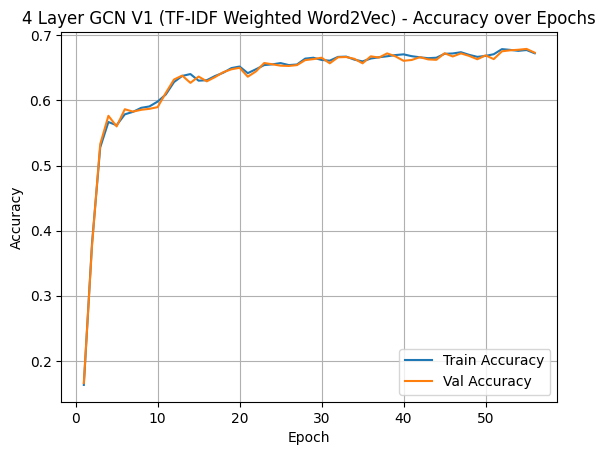

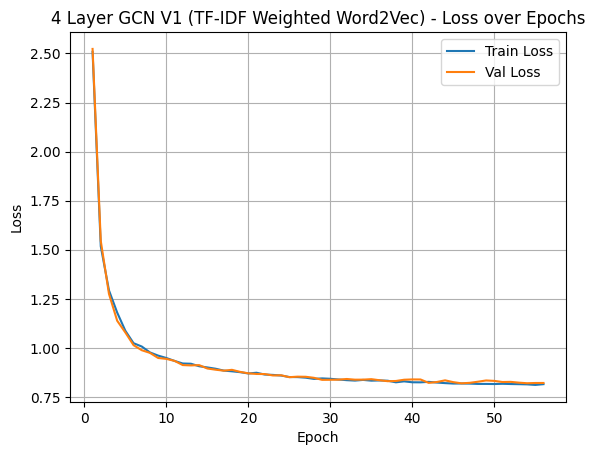


📊 4 Layer GCN V1 (TF-IDF Weighted Word2Vec) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.43      0.90      0.58      3768
       fraud_scam_identity_theft       0.00      0.00      0.00       828
    incorrect_info_credit_report       0.69      0.62      0.65      4143
threatened_negative_legal_action       0.00      0.00      0.00      1124
  trouble_during_payment_process       0.00      0.00      0.00      1791

                        accuracy                           0.51     11654
                       macro avg       0.22      0.30      0.25     11654
                    weighted avg       0.38      0.51      0.42     11654



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


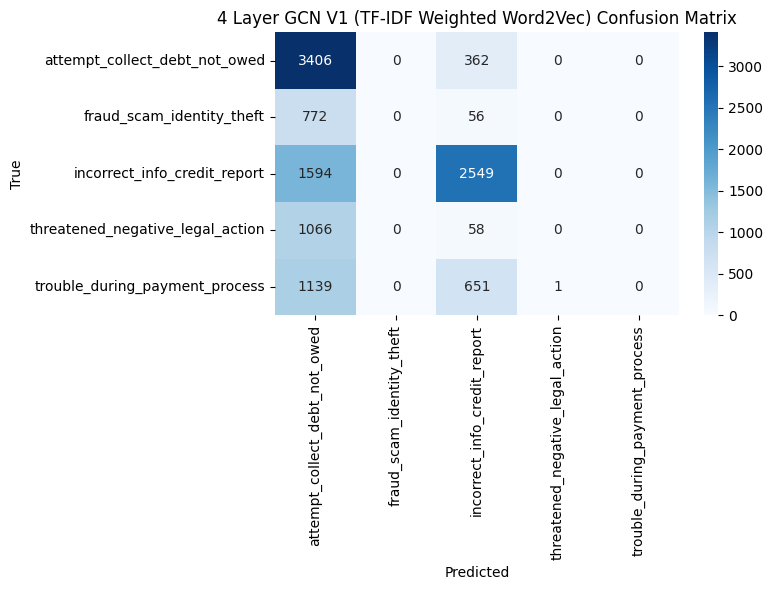

In [ ]:
# 4 layers GCN V1 (4 GCN layers + LR Scheduler)

# Concatenate for full graph using TF-IDF weighted Word2Vec features
X_all = np.vstack([tfidf_w2v_train, tfidf_w2v_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(tfidf_w2v_train_final)
num_val = len(tfidf_w2v_val)
num_train_total = num_train_final + num_val
num_test = len(tfidf_w2v_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Construct graph using KNN (only for adjacency, not learning)
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v1 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v1 = NormalizeFeatures()(data_gcn_v1)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v1.train_mask = train_mask
data_gcn_v1.val_mask = val_mask
data_gcn_v1.test_mask = test_mask

# GCN Model Definition
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3 = BatchNorm1d(hidden_channels)

        self.conv4 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(0.5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv4(x, edge_index)
        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v1.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = GCN(in_dim, hidden_dim, out_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data_gcn_v1 = data_gcn_v1.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Directory to save models
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "GCN_V1_4L.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None
early_stopping_patience = 10
no_improve_epochs = 0


for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v1)
    loss = F.cross_entropy(
        out[data_gcn_v1.train_mask],
        data_gcn_v1.y[data_gcn_v1.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v1.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v1.y[data_gcn_v1.train_mask]).sum().item() / data_gcn_v1.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v1.val_mask]
        val_labels = data_gcn_v1.y[data_gcn_v1.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels, weight=class_weights)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v1.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)
    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        no_improve_epochs = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        no_improve_epochs += 1
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

    if no_improve_epochs >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs with no improvement in val_loss.")
        break

print(f"Best model saved to: {best_model_path} with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "4 Layer GCN V1 (TF-IDF Weighted Word2Vec)")


# Generate predictions on test set
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v1)
    preds = out.argmax(dim=1)[data_gcn_v1.test_mask].cpu().numpy()
y_true_gcn_v1 = data_gcn_v1.y[data_gcn_v1.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 4 Layer GCN V1 (TF-IDF Weighted Word2Vec) Classification Report")
print(classification_report(y_true_gcn_v1, preds, target_names=class_names))
plot_cm(y_true_gcn_v1, preds, "4 Layer GCN V1 (TF-IDF Weighted Word2Vec) Confusion Matrix")

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001: val_accuracy = 0.2913, val_loss improved to 2.4892, saving model...
Epoch 002: val_accuracy = 0.3771, val_loss improved to 1.5821, saving model...
Epoch 003: val_accuracy = 0.4273, val_loss improved to 1.5125, saving model...
Epoch 004: val_accuracy = 0.4725, val_loss improved to 1.3553, saving model...
Epoch 005: val_accuracy = 0.5264, val_loss improved to 1.1617, saving model...
Epoch 006: val_accuracy = 0.5663, val_loss improved to 1.0829, saving model...
Epoch 007: val_accuracy = 0.5894, val_loss improved to 1.0517, saving model...
Epoch 008: val_accuracy = 0.6171, val_loss improved to 1.0186, saving model...
Epoch 009: val_accuracy = 0.6229, val_loss improved to 1.0010, saving model...
Epoch 010: val_accuracy = 0.6240, val_loss improved to 0.9758, saving model...
Epoch 011: val_accuracy = 0.6356, val_loss improved to 0.9380, saving model...
Epoch 012: val_accuracy = 0.6300, val_loss = 0.9469
Epoch 013: val_accuracy = 0.6315, val_loss improved to 0.9316, saving model...


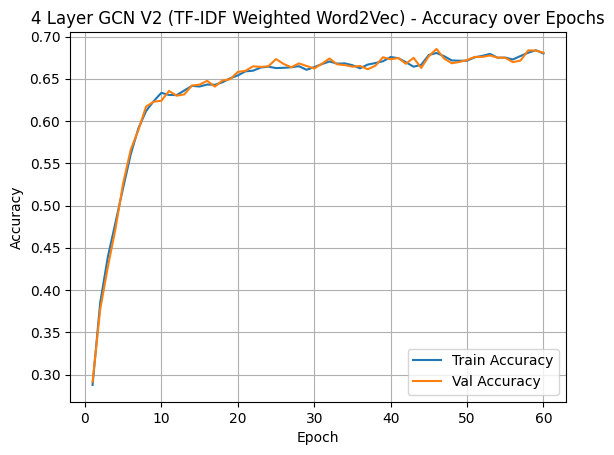

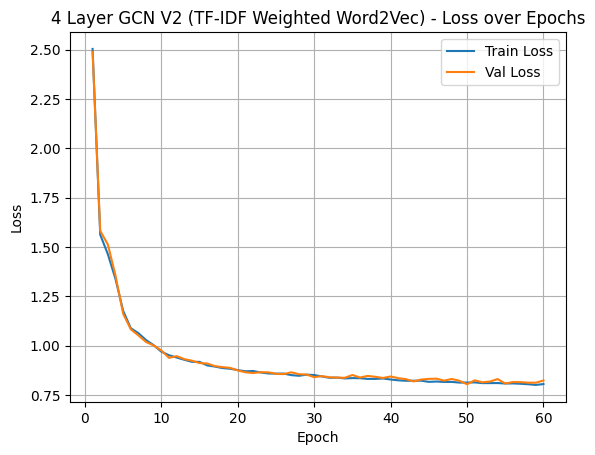


📊 4 Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.32      1.00      0.49      3768
       fraud_scam_identity_theft       0.00      0.00      0.00       828
    incorrect_info_credit_report       0.00      0.00      0.00      4143
threatened_negative_legal_action       0.00      0.00      0.00      1124
  trouble_during_payment_process       0.00      0.00      0.00      1791

                        accuracy                           0.32     11654
                       macro avg       0.06      0.20      0.10     11654
                    weighted avg       0.10      0.32      0.16     11654



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


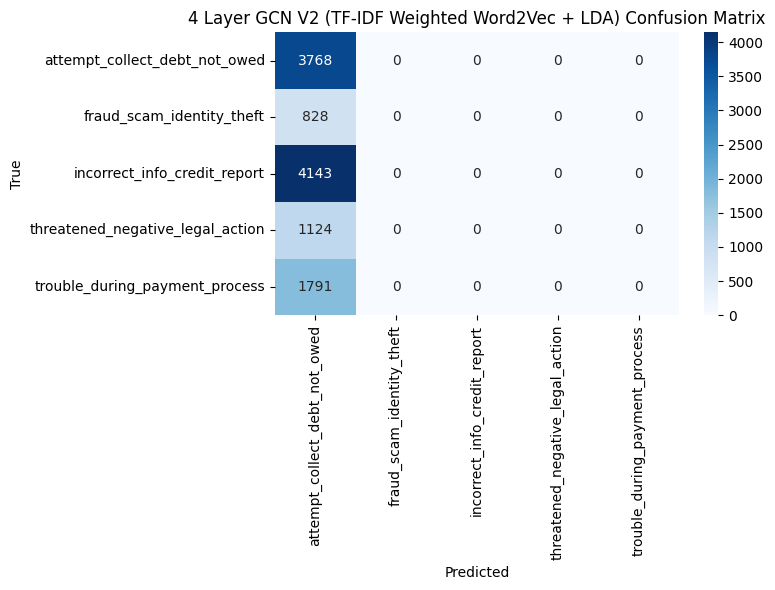

In [ ]:
# 4 layers GCN V2 (4 GCN layers + LR Scheduler)

# Concatenate for full graph using combined TF-IDF weighted Word2Vec + LDA features
X_all = np.vstack([combined_train, combined_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(combined_train_final)
num_val = len(combined_val)
num_train_total = num_train_final + num_val
num_test = len(combined_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Construct graph using KNN (only for adjacency, not learning)
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v2 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v2 = NormalizeFeatures()(data_gcn_v2)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v2.train_mask = train_mask
data_gcn_v2.val_mask = val_mask
data_gcn_v2.test_mask = test_mask

# GCN Model Definition
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3 = BatchNorm1d(hidden_channels)

        self.conv4 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(0.5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv4(x, edge_index)
        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v2.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = GCN(in_dim, hidden_dim, out_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data_gcn_v2 = data_gcn_v2.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Directory to save models
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "GCN_V2_4L.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None
early_stopping_patience = 10
no_improve_epochs = 0


for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v2)
    loss = F.cross_entropy(
        out[data_gcn_v2.train_mask],
        data_gcn_v2.y[data_gcn_v2.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v2.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v2.y[data_gcn_v2.train_mask]).sum().item() / data_gcn_v2.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v2.val_mask]
        val_labels = data_gcn_v2.y[data_gcn_v2.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels, weight=class_weights)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v2.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)
    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        no_improve_epochs = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        no_improve_epochs += 1
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

    if no_improve_epochs >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs with no improvement in val_loss.")
        break

print(f"Best model saved to: {best_model_path} with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "4 Layer GCN V2 (TF-IDF Weighted Word2Vec)")


# Generate predictions on test set
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v2)
    preds = out.argmax(dim=1)[data_gcn_v2.test_mask].cpu().numpy()
y_true_gcn_v2 = data_gcn_v2.y[data_gcn_v2.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 4 Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report")
print(classification_report(y_true_gcn_v2, preds, target_names=class_names))
plot_cm(y_true_gcn_v2, preds, "4 Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Confusion Matrix")

## Extra GCN try out: Label Smoothing & Mutual KNN, Residual GCN, JKNet GCN

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001: val_accuracy = 0.2677, val_loss improved to 1.8806
Epoch 002: val_accuracy = 0.3840, val_loss improved to 1.7194
Epoch 003: val_accuracy = 0.4730, val_loss improved to 1.4270
Epoch 004: val_accuracy = 0.4966, val_loss improved to 1.3594
Epoch 005: val_accuracy = 0.5294, val_loss improved to 1.3175
Epoch 006: val_accuracy = 0.5768, val_loss improved to 1.2590
Epoch 007: val_accuracy = 0.6137, val_loss improved to 1.2532
Epoch 008: val_accuracy = 0.6184, val_loss improved to 1.2394
Epoch 009: val_accuracy = 0.6251, val_loss improved to 1.2160
Epoch 010: val_accuracy = 0.6088, val_loss = 1.2162
Epoch 011: val_accuracy = 0.6053, val_loss improved to 1.2124
Epoch 012: val_accuracy = 0.6068, val_loss improved to 1.2020
Epoch 013: val_accuracy = 0.6208, val_loss improved to 1.1883
Epoch 014: val_accuracy = 0.6409, val_loss improved to 1.1744
Epoch 015: val_accuracy = 0.6478, val_loss improved to 1.1651
Epoch 016: val_accuracy = 0.6482, val_loss = 1.1675
Epoch 017: val_accuracy = 0.

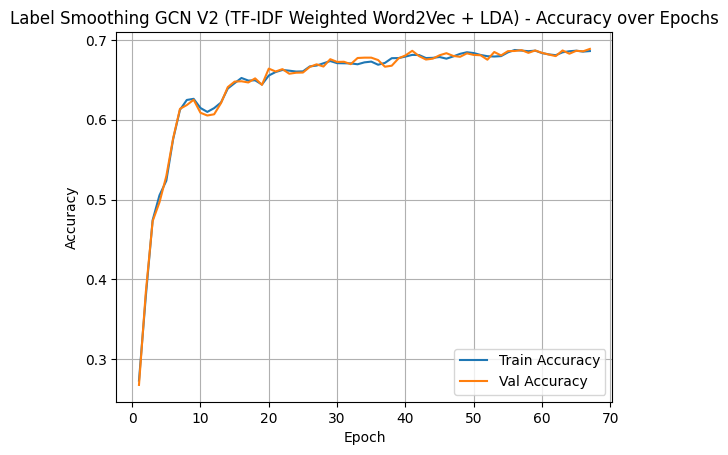

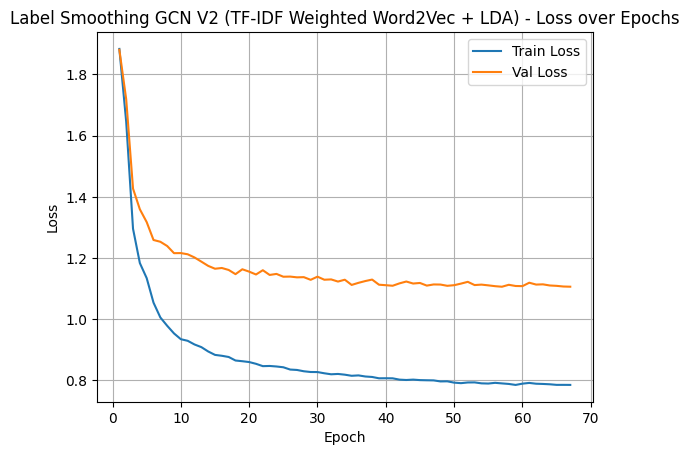


📊 Label Smoothing GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.32      1.00      0.49      3768
       fraud_scam_identity_theft       0.00      0.00      0.00       828
    incorrect_info_credit_report       0.75      0.01      0.02      4143
threatened_negative_legal_action       0.00      0.00      0.00      1124
  trouble_during_payment_process       0.00      0.00      0.00      1791

                        accuracy                           0.33     11654
                       macro avg       0.21      0.20      0.10     11654
                    weighted avg       0.37      0.33      0.17     11654



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


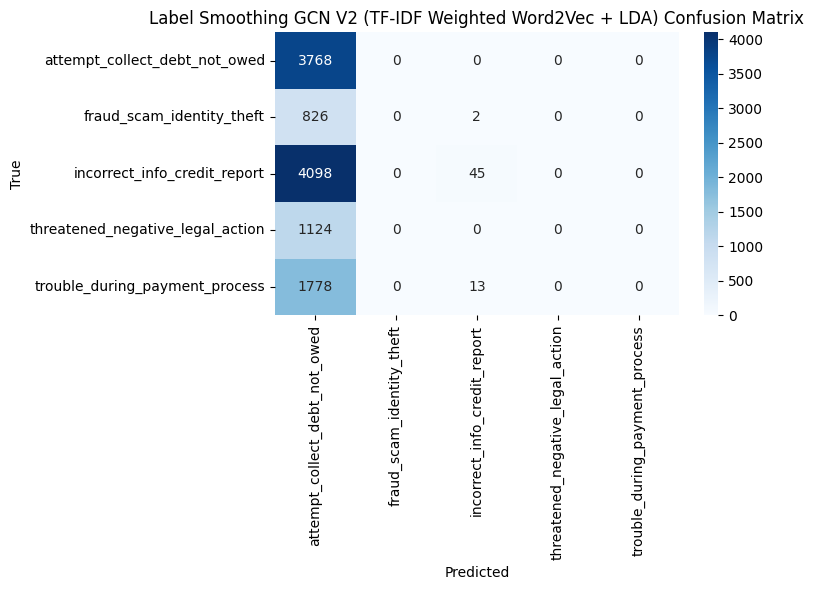

In [ ]:
# GCN V2 (3 GCN layers + LR Scheduler + Label Smoothing)

# Concatenate for full graph using combined TF-IDF weighted Word2Vec + LDA features
X_all = np.vstack([combined_train, combined_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(combined_train_final)
num_val = len(combined_val)
num_train_total = num_train_final + num_val
num_test = len(combined_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Construct graph using KNN (only for adjacency, not learning)
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v2 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v2 = NormalizeFeatures()(data_gcn_v2)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v2.train_mask = train_mask
data_gcn_v2.val_mask = val_mask
data_gcn_v2.test_mask = test_mask

def label_smoothing_loss(preds, targets, smoothing=0.1, weight=None):
    n_classes = preds.size(1)
    confidence = 1.0 - smoothing
    smoothed_labels = torch.full(size=(targets.size(0), n_classes),
                                 fill_value=smoothing / (n_classes - 1)).to(preds.device)
    smoothed_labels.scatter_(1, targets.unsqueeze(1), confidence)

    log_probs = F.log_softmax(preds, dim=1)
    loss = -torch.sum(smoothed_labels * log_probs, dim=1)

    if weight is not None:
        weight = weight[targets]
        loss = loss * weight

    return loss.mean()

# GCN Model Definition
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(0.5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v2.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = GCN(in_dim, hidden_dim, out_dim)
model = model.to(device)
data_gcn_v2 = data_gcn_v2.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None
early_stopping_patience = 10
no_improve_epochs = 0


for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v2)
    loss = F.cross_entropy(
        out[data_gcn_v2.train_mask],
        data_gcn_v2.y[data_gcn_v2.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v2.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v2.y[data_gcn_v2.train_mask]).sum().item() / data_gcn_v2.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v2.val_mask]
        val_labels = data_gcn_v2.y[data_gcn_v2.val_mask]
        val_loss = label_smoothing_loss(val_logits, val_labels, smoothing=0.1, weight=class_weights)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v2.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)
    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        no_improve_epochs = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}")
    else:
        no_improve_epochs += 1
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

    if no_improve_epochs >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs with no improvement in val_loss.")
        break

print(f"Best model with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "Label Smoothing GCN V2 (TF-IDF Weighted Word2Vec + LDA)")


# Generate predictions on test mask
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v2)
    preds = out.argmax(dim=1)[data_gcn_v2.test_mask].cpu().numpy()
y_true_gcn_v2 = data_gcn_v2.y[data_gcn_v2.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 Label Smoothing GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report")
print(classification_report(y_true_gcn_v2, preds, target_names=class_names))
plot_cm(y_true_gcn_v2, preds, "Label Smoothing GCN V2 (TF-IDF Weighted Word2Vec + LDA) Confusion Matrix")

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001: val_accuracy = 0.2411, val_loss improved to 1.8869
Epoch 002: val_accuracy = 0.5105, val_loss improved to 1.1882
Epoch 003: val_accuracy = 0.5459, val_loss improved to 1.0524
Epoch 004: val_accuracy = 0.5781, val_loss improved to 0.9859
Epoch 005: val_accuracy = 0.6201, val_loss improved to 0.9366
Epoch 006: val_accuracy = 0.6484, val_loss improved to 0.9193
Epoch 007: val_accuracy = 0.6540, val_loss improved to 0.8859
Epoch 008: val_accuracy = 0.6456, val_loss improved to 0.8820
Epoch 009: val_accuracy = 0.6497, val_loss improved to 0.8583
Epoch 010: val_accuracy = 0.6489, val_loss improved to 0.8448
Epoch 011: val_accuracy = 0.6656, val_loss improved to 0.8367
Epoch 012: val_accuracy = 0.6703, val_loss improved to 0.8162
Epoch 013: val_accuracy = 0.6770, val_loss improved to 0.8082
Epoch 014: val_accuracy = 0.6752, val_loss improved to 0.8035
Epoch 015: val_accuracy = 0.6692, val_loss = 0.8095
Epoch 016: val_accuracy = 0.6628, val_loss improved to 0.7933
Epoch 017: val_acc

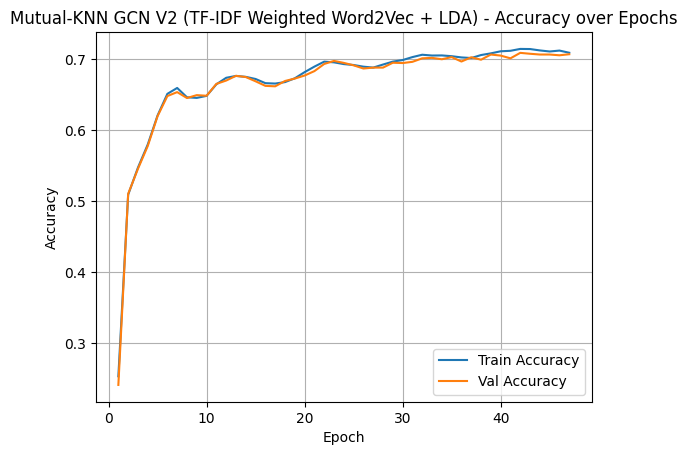

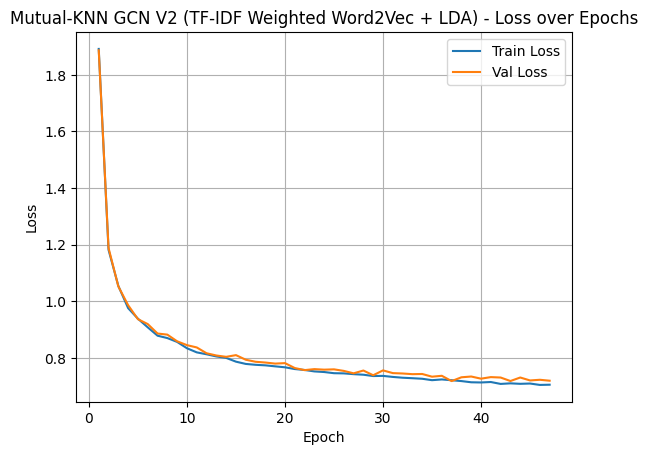


📊 Mutual-KNN GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.32      1.00      0.49      3768
       fraud_scam_identity_theft       0.00      0.00      0.00       828
    incorrect_info_credit_report       0.88      0.00      0.01      4143
threatened_negative_legal_action       0.00      0.00      0.00      1124
  trouble_during_payment_process       0.00      0.00      0.00      1791

                        accuracy                           0.32     11654
                       macro avg       0.24      0.20      0.10     11654
                    weighted avg       0.42      0.32      0.16     11654



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


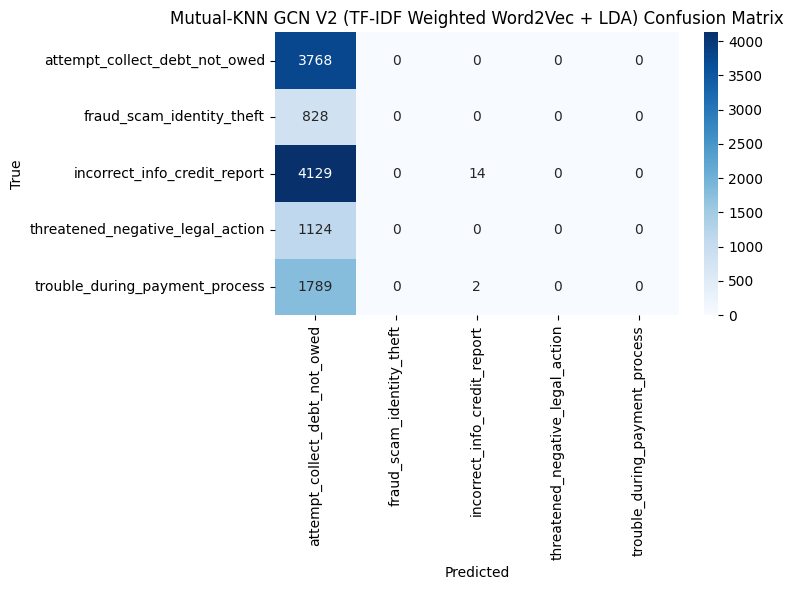

In [ ]:
# GCN V2 (3 GCN layers + LR Scheduler + Mutual KNN)

# Concatenate for full graph using combined TF-IDF weighted Word2Vec + LDA features
X_all = np.vstack([combined_train, combined_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(combined_train_final)
num_val = len(combined_val)
num_train_total = num_train_final + num_val
num_test = len(combined_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Construct graph using mutual KNN with cosine similarity index
k = 10
nn_model = NearestNeighbors(n_neighbors=k+1, metric='cosine', n_jobs=-1)  # +1 because first neighbor is self
nn_model.fit(X_all)
distances, neighbors = nn_model.kneighbors(X_all)
rows, cols = [], []
for i in range(num_nodes):
    for j in neighbors[i][1:]:  # skip self
        if i in neighbors[j][1:]:  # mutual
            rows.append(i)
            cols.append(j)

edge_index = torch.tensor([rows, cols], dtype=torch.long)

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v2 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v2 = NormalizeFeatures()(data_gcn_v2)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v2.train_mask = train_mask
data_gcn_v2.val_mask = val_mask
data_gcn_v2.test_mask = test_mask

# GCN Model Definition
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(0.5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v2.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = GCN(in_dim, hidden_dim, out_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data_gcn_v2 = data_gcn_v2.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)


# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None
early_stopping_patience = 10
no_improve_epochs = 0


for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v2)
    loss = F.cross_entropy(
        out[data_gcn_v2.train_mask],
        data_gcn_v2.y[data_gcn_v2.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v2.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v2.y[data_gcn_v2.train_mask]).sum().item() / data_gcn_v2.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v2.val_mask]
        val_labels = data_gcn_v2.y[data_gcn_v2.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels, weight=class_weights)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v2.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)
    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        no_improve_epochs = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}")
    else:
        no_improve_epochs += 1
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

    if no_improve_epochs >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs with no improvement in val_loss.")
        break

print(f"Best model with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "Mutual-KNN GCN V2 (TF-IDF Weighted Word2Vec + LDA)")


# Generate predictions on test set
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v2)
    preds = out.argmax(dim=1)[data_gcn_v2.test_mask].cpu().numpy()
y_true_gcn_v2 = data_gcn_v2.y[data_gcn_v2.test_mask].cpu().numpy()

# Classification report
print("\n📊 Mutual-KNN GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report")
print(classification_report(y_true_gcn_v2, preds, target_names=class_names))
plot_cm(y_true_gcn_v2, preds, "Mutual-KNN GCN V2 (TF-IDF Weighted Word2Vec + LDA) Confusion Matrix")

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001: val_accuracy = 0.1718, val_loss improved to 2.4261
Epoch 002: val_accuracy = 0.3293, val_loss improved to 1.8733
Epoch 003: val_accuracy = 0.3917, val_loss improved to 1.5255
Epoch 004: val_accuracy = 0.4434, val_loss improved to 1.3195
Epoch 005: val_accuracy = 0.4987, val_loss improved to 1.1781
Epoch 006: val_accuracy = 0.5135, val_loss = 1.2018
Epoch 007: val_accuracy = 0.5390, val_loss improved to 1.1335
Epoch 008: val_accuracy = 0.5523, val_loss improved to 1.0953
Epoch 009: val_accuracy = 0.5626, val_loss improved to 1.0501
Epoch 010: val_accuracy = 0.5592, val_loss improved to 1.0283
Epoch 011: val_accuracy = 0.5699, val_loss improved to 1.0236
Epoch 012: val_accuracy = 0.5755, val_loss improved to 0.9696
Epoch 013: val_accuracy = 0.5746, val_loss = 0.9852
Epoch 014: val_accuracy = 0.6047, val_loss improved to 0.9524
Epoch 015: val_accuracy = 0.6062, val_loss improved to 0.9368
Epoch 016: val_accuracy = 0.6238, val_loss improved to 0.9300
Epoch 017: val_accuracy = 0.

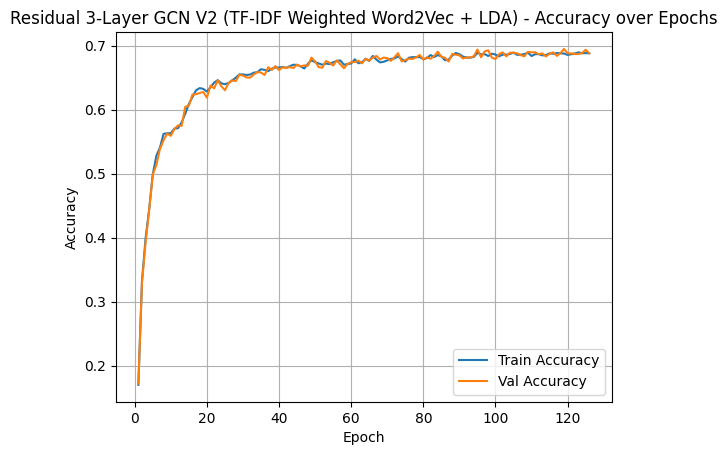

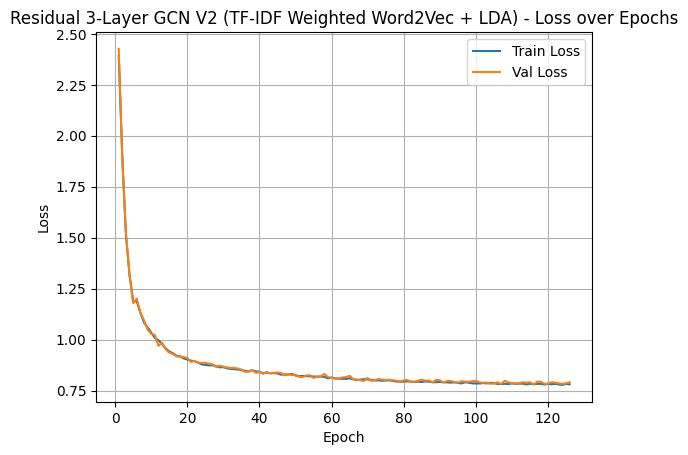


📊 Residual 3-Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.69      0.62      0.65      3768
       fraud_scam_identity_theft       0.61      0.75      0.67       828
    incorrect_info_credit_report       0.83      0.74      0.78      4143
threatened_negative_legal_action       0.40      0.59      0.48      1124
  trouble_during_payment_process       0.85      0.88      0.86      1791

                        accuracy                           0.71     11654
                       macro avg       0.67      0.72      0.69     11654
                    weighted avg       0.73      0.71      0.72     11654



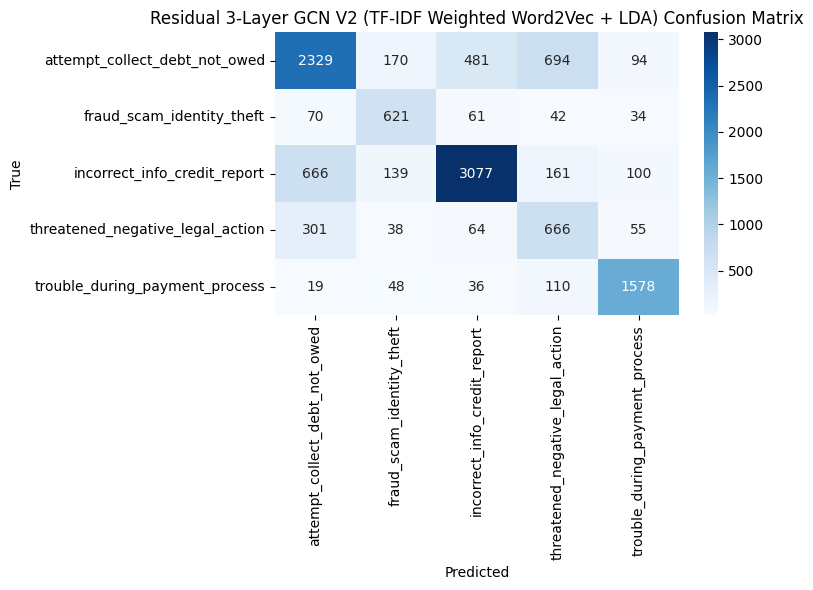

In [ ]:
# Residual GCN V2 (TF-IDF Weighted Word2Vec + LDA)
# Residual connection between layers enable models to reuse earlier features if deeper layers oversmooth or degrade them

# Concatenate for full graph using combined TF-IDF weighted Word2Vec + LDA features
X_all = np.vstack([combined_train, combined_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(combined_train_final)
num_val = len(combined_val)
num_train_total = num_train_final + num_val
num_test = len(combined_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Construct graph using KNN (only for adjacency, not learning)
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v2 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v2 = NormalizeFeatures()(data_gcn_v2)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v2.train_mask = train_mask
data_gcn_v2.val_mask = val_mask
data_gcn_v2.test_mask = test_mask

# Residual GCN model definition
class ResidualGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(ResidualGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # First layer
        x1 = self.conv1(x, edge_index)
        x1 = self.bn1(x1)
        x1 = F.relu(x1)
        x1 = self.dropout(x1)

        # Second layer with residual
        x2 = self.conv2(x1, edge_index)
        x2 = self.bn2(x2)
        x2 = F.relu(x2 + x1)  # Residual connection
        x2 = self.dropout(x2)

        # Final layer
        x3 = self.conv3(x2, edge_index)
        return F.log_softmax(x3, dim=1)

# Hyperparameters
in_dim = data_gcn_v2.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = ResidualGCN(in_dim, hidden_dim, out_dim)
model = model.to(device)
data_gcn_v2 = data_gcn_v2.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None
early_stopping_patience = 10
no_improve_epochs = 0

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v2)
    loss = F.cross_entropy(
        out[data_gcn_v2.train_mask],
        data_gcn_v2.y[data_gcn_v2.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v2.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v2.y[data_gcn_v2.train_mask]).sum().item() / data_gcn_v2.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v2.val_mask]
        val_labels = data_gcn_v2.y[data_gcn_v2.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels, weight=class_weights)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v2.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)
    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        no_improve_epochs = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}")
    else:
        no_improve_epochs += 1
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

    if no_improve_epochs >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs with no improvement in val_loss.")
        break

print(f"Best model with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "Residual 3-Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA)")


# Generate predictions on test set
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v2)
    preds = out.argmax(dim=1)[data_gcn_v2.test_mask].cpu().numpy()
y_true_gcn_v2 = data_gcn_v2.y[data_gcn_v2.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 Residual 3-Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report")
print(classification_report(y_true_gcn_v2, preds, target_names=class_names))
plot_cm(y_true_gcn_v2, preds, "Residual 3-Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Confusion Matrix")

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001: val_accuracy = 0.0886, val_loss improved to 1.6103
Epoch 002: val_accuracy = 0.1707, val_loss improved to 1.6091
Epoch 003: val_accuracy = 0.1710, val_loss improved to 1.6088
Epoch 004: val_accuracy = 0.1864, val_loss improved to 1.6086
Epoch 005: val_accuracy = 0.1740, val_loss improved to 1.6080
Epoch 006: val_accuracy = 0.2523, val_loss improved to 1.6073
Epoch 007: val_accuracy = 0.2149, val_loss improved to 1.6071
Epoch 008: val_accuracy = 0.2119, val_loss improved to 1.6071
Epoch 009: val_accuracy = 0.1931, val_loss improved to 1.6066
Epoch 010: val_accuracy = 0.2377, val_loss improved to 1.6064
Epoch 011: val_accuracy = 0.1701, val_loss improved to 1.6058
Epoch 012: val_accuracy = 0.3061, val_loss improved to 1.6033
Epoch 013: val_accuracy = 0.2160, val_loss improved to 1.6026
Epoch 014: val_accuracy = 0.1690, val_loss improved to 1.6014
Epoch 015: val_accuracy = 0.3222, val_loss improved to 1.5990
Epoch 016: val_accuracy = 0.2756, val_loss improved to 1.5957
Epoch 01

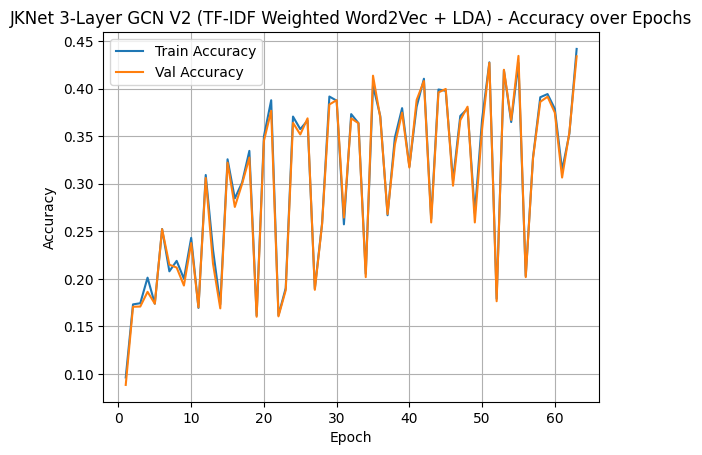

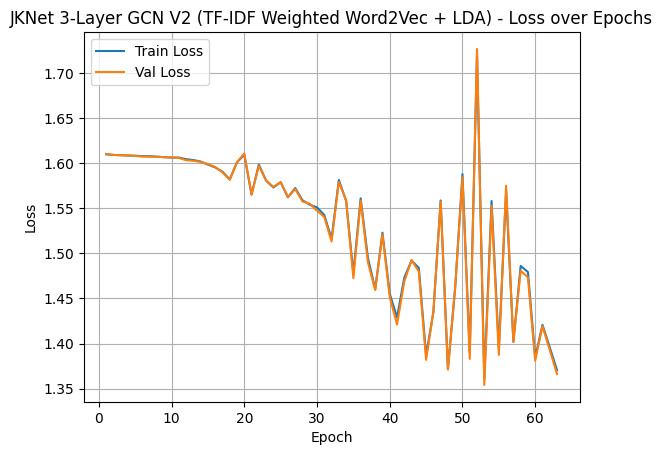


📊 JKNet 3-Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.17      0.02      0.03      3768
       fraud_scam_identity_theft       0.06      0.07      0.06       828
    incorrect_info_credit_report       0.42      0.98      0.59      4143
threatened_negative_legal_action       0.05      0.02      0.03      1124
  trouble_during_payment_process       0.98      0.07      0.13      1791

                        accuracy                           0.37     11654
                       macro avg       0.34      0.23      0.17     11654
                    weighted avg       0.36      0.37      0.25     11654



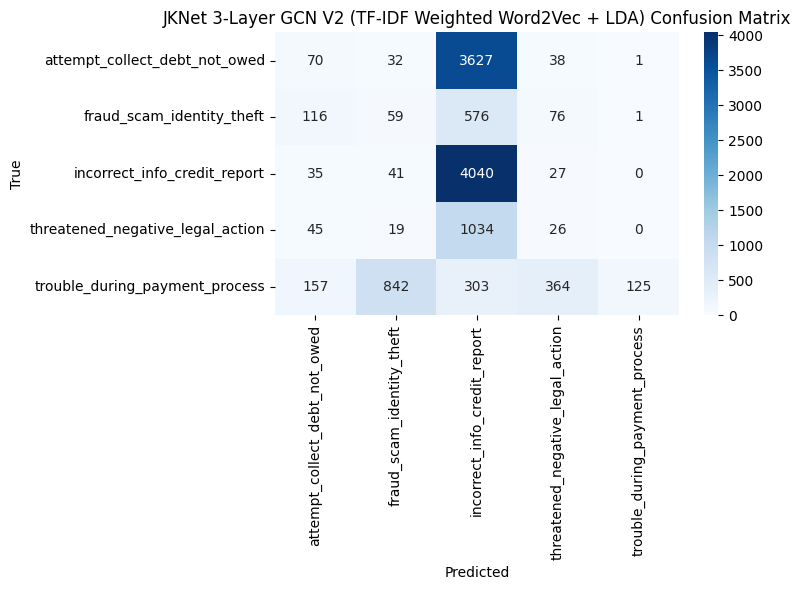

In [ ]:
# JKNet GCN V2 (TF-IDF Weighted Word2Vec + LDA)
# JKNet aggregates outputs from all GCN layers rather than just the last one.
# It’s useful for avoiding over-smoothing and retaining both local and global features.

# Concatenate for full graph using combined TF-IDF weighted Word2Vec + LDA features
X_all = np.vstack([combined_train, combined_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(combined_train_final)
num_val = len(combined_val)
num_train_total = num_train_final + num_val
num_test = len(combined_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Construct graph using KNN (only for adjacency, not learning)
k = 10
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v2 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v2 = NormalizeFeatures()(data_gcn_v2)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v2.train_mask = train_mask
data_gcn_v2.val_mask = val_mask
data_gcn_v2.test_mask = test_mask

# Jumping Knowledge Network GCN model definition
class JKNetGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(JKNetGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.jk = JumpingKnowledge(mode='cat')  # Can also try 'max' or 'lstm'
        self.lin = nn.Linear(3 * hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        xs = []
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        xs.append(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        xs.append(x)
        x = self.dropout(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        xs.append(x)
        x = self.jk(xs)  # Aggregate outputs from all layers
        x = self.dropout(x)
        x = self.lin(x)

        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v2.num_node_features
hidden_dim = 128
out_dim = len(np.unique(y_all))
model = JKNetGCN(in_dim, hidden_dim, out_dim)
model = model.to(device)
data_gcn_v2 = data_gcn_v2.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None
early_stopping_patience = 10
no_improve_epochs = 0

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v2)
    loss = F.cross_entropy(
        out[data_gcn_v2.train_mask],
        data_gcn_v2.y[data_gcn_v2.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v2.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v2.y[data_gcn_v2.train_mask]).sum().item() / data_gcn_v2.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v2.val_mask]
        val_labels = data_gcn_v2.y[data_gcn_v2.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels, weight=class_weights)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v2.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)
    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        no_improve_epochs = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}")
    else:
        no_improve_epochs += 1
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

    if no_improve_epochs >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs with no improvement in val_loss.")
        break

print(f"Best model with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "JKNet 3-Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA)")


# Generate predictions on test set
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v2)
    preds = out.argmax(dim=1)[data_gcn_v2.test_mask].cpu().numpy()
y_true_gcn_v2 = data_gcn_v2.y[data_gcn_v2.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 JKNet 3-Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report")
print(classification_report(y_true_gcn_v2, preds, target_names=class_names))
plot_cm(y_true_gcn_v2, preds, "JKNet 3-Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Confusion Matrix")

# Hyperparameter Tuning

### Tuned RNN (BiLSTM) Padded Sequence with Embedding Matrix

In [ ]:
# Hyperparameter tuning using Optuna (BiLSTM Variation 1 - Padded Sequence)
vocab_size = embedding_matrix.shape[0]
embedding_dim = embedding_matrix.shape[1]
maxlen = X_train_pad_final.shape[1]
num_classes = len(np.unique(y_train_final))

unique_classes = np.unique(y_train_final)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_final
)
class_weights = dict(zip(unique_classes, class_weights_array))

# Define objective function for Optuna
def objective(trial):
    # Hyperparameters to tune
    lstm_units = trial.suggest_int("lstm_units", 64, 256, step=64)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)
    dense_units = trial.suggest_int("dense_units", 32, 128, step=32)
    l2_reg = trial.suggest_float("l2_reg", 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    # Model definition
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
                  input_length=maxlen,
                  trainable=True),
        Bidirectional(LSTM(lstm_units, return_sequences=False)),
        Dropout(dropout_rate), Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg)),
        BatchNormalization(), Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
    # Implement pruning callback to end bad trials early
    pruning_callback = TFKerasPruningCallback(trial, "val_loss")

    history = model.fit(
        X_train_pad_final, y_train_onehot_final,
        validation_data=(X_val_pad, y_val_onehot),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop, reduce_lr, pruning_callback],
        verbose=0
    )
    val_loss = min(history.history['val_loss'])
    return val_loss

# Run Optuna study
study = optuna.create_study(
    direction='minimize',
    # give each trail 3 epoch chances to prove before prune
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)
study.optimize(objective, n_trials=30)

# Save and print the best hyperparameter combination
save_path = "/content/drive/MyDrive/FYP/Hyperparameter_Tuning/BiLSTM_best_hyperparams.json"
with open(save_path, "w") as f:
    json.dump(study.best_trial.params, f)

print("Best hyperparameters:")
print(study.best_trial.params)

[I 2025-05-31 04:42:59,918] A new study created in memory with name: no-name-44a13501-5d79-4dd8-a279-e6f8c36ebb31
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005863079568371177.
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 5.


[I 2025-05-31 04:47:59,516] Trial 0 finished with value: 0.82354336977005 and parameters: {'lstm_units': 256, 'dropout_rate': 0.42017878483680937, 'dense_units': 128, 'l2_reg': 0.00496516971127545, 'learning_rate': 0.0011726159323485175}. Best is trial 0 with value: 0.82354336977005.



Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0015051565133035183.
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


[I 2025-05-31 04:52:32,982] Trial 1 finished with value: 0.8252959251403809 and parameters: {'lstm_units': 192, 'dropout_rate': 0.4625791782718496, 'dense_units': 96, 'l2_reg': 0.00038794355758829235, 'learning_rate': 0.00301031300990921}. Best is trial 0 with value: 0.82354336977005.


...


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0003941736649721861.
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 8.


[I 2025-05-31 05:58:46,240] Trial 23 finished with value: 0.8088487386703491 and parameters: {'lstm_units': 256, 'dropout_rate': 0.5002525557122446, 'dense_units': 32, 'l2_reg': 4.2412247343447386e-05, 'learning_rate': 0.0007883473560868521}. Best is trial 3 with value: 0.8087157011032104.



Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00037635210901498795.
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 6.


[I 2025-05-31 06:04:04,100] Trial 24 finished with value: 0.8138899803161621 and parameters: {'lstm_units': 192, 'dropout_rate': 0.48492106453046174, 'dense_units': 64, 'l2_reg': 4.819140620732543e-05, 'learning_rate': 0.000752704230208326}. Best is trial 3 with value: 0.8087157011032104.
[I 2025-05-31 06:06:34,129] Trial 25 pruned. Trial was pruned at epoch 3.
[I 2025-05-31 06:09:14,315] Trial 26 pruned. Trial was pruned at epoch 3.
[I 2025-05-31 06:12:01,048] Trial 27 pruned. Trial was pruned at epoch 3.
[I 2025-05-31 06:13:59,123] Trial 28 pruned. Trial was pruned at epoch 3.
[I 2025-05-31 06:15:49,721] Trial 29 pruned. Trial was pruned at epoch 3.


Best hyperparameters:
{'lstm_units': 256, 'dropout_rate': 0.5259004363425432, 'dense_units': 64, 'l2_reg': 1.4664594347106167e-05, 'learning_rate': 0.0026729428264828606}


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1310/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6104 - loss: 1.1547
Epoch 1: val_loss improved from inf to 1.02383, saving model to /content/drive/MyDrive/FYP/Models/Tuned_BiLSTM_RNN_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.6105 - loss: 1.1544 - val_accuracy: 0.6813 - val_loss: 1.0238 - learning_rate: 0.0027
Epoch 2/20
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7520 - loss: 0.8520
Epoch 2: val_loss improved from 1.02383 to 0.94105, saving model to /content/drive/MyDrive/FYP/Models/Tuned_BiLSTM_RNN_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.7520 - loss: 0.8520 - val_accuracy: 0.7169 - val_loss: 0.9411 - learning_rate: 0.0027
Epoch 3/20
1309/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7890 - loss: 0.7903
Epoch 3: val_loss improved from 0.94105 to 0.89255, saving model to /content/drive/MyDrive/FYP/Models/Tuned_BiLSTM_RNN_Seq.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_30 (Embedding)        │ (None, 100, 100)       │     1,489,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_30                │ (None, 512)            │       731,136 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,762,493 (25.80 MB)

 Trainable params: 2,254,121 (8.60 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 4,508,244 (17.20 MB)

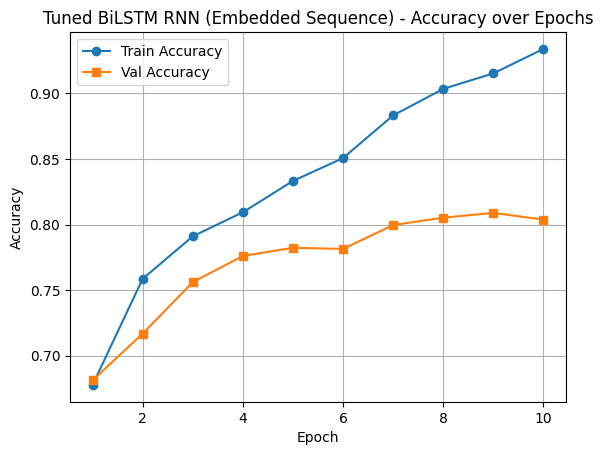

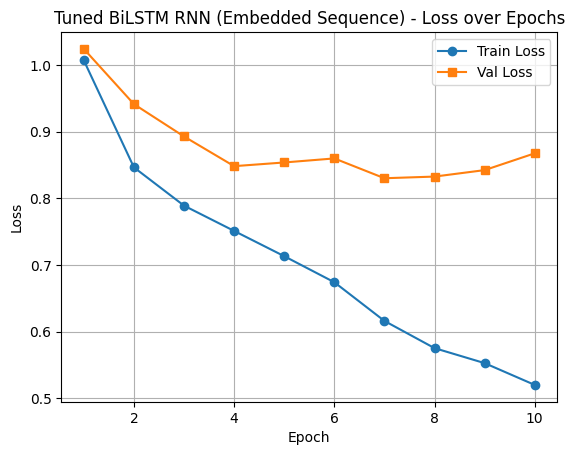

365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

📊 Tuned BiLSTM RNN (Embedded Sequence) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.79      0.74      0.76      3768
       fraud_scam_identity_theft       0.67      0.85      0.75       828
    incorrect_info_credit_report       0.89      0.84      0.86      4143
threatened_negative_legal_action       0.55      0.63      0.59      1124
  trouble_during_payment_process       0.90      0.94      0.92      1791

                        accuracy                           0.80     11654
                       macro avg       0.76      0.80      0.78     11654
                    weighted avg       0.81      0.80      0.80     11654



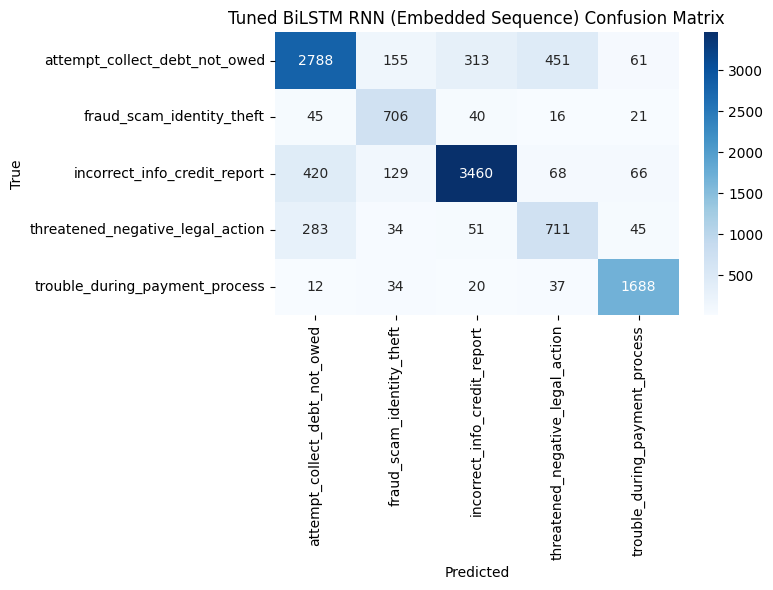

In [ ]:
# Build BiLSTM model based on the best hyperparameter combination

# Load best hyperparameters from file if run in next runtime
# load_path = "/content/drive/MyDrive/FYP/Hyperparameter_Tuning/BiLSTM_best_hyperparams.json"
# with open(load_path, "r") as f:
#     best_params = json.load(f)

best_params = study.best_trial.params

# Rebuild model with best hyperparameters
model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=True),
    Bidirectional(LSTM(best_params['lstm_units'], return_sequences=False)),
    Dropout(best_params['dropout_rate']),
    Dense(best_params['dense_units'], activation='relu', kernel_regularizer=l2(best_params['l2_reg'])),
    BatchNormalization(),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/FYP/Models/Tuned_BiLSTM_RNN_Seq.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Train on full training data
history = model.fit(
    X_train_pad_final, y_train_onehot_final,
    validation_data=(X_val_pad, y_val_onehot),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print("")
model.summary()

# Plot epoch performance
plot_history(history, "Tuned BiLSTM RNN (Embedded Sequence)")

# Generate predictions on test set
rnn_seq_preds = np.argmax(model.predict(X_test_pad), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 Tuned BiLSTM RNN (Embedded Sequence) Report")
print(classification_report(y_true, rnn_seq_preds, target_names=class_names))
plot_cm(y_true, rnn_seq_preds, "Tuned BiLSTM RNN (Embedded Sequence) Confusion Matrix")

## Tuned CNN + BiLSTM Hybrid Padded Sequence with Embedding Matrix

In [ ]:
# Model input params
vocab_size = embedding_matrix.shape[0]
embedding_dim = embedding_matrix.shape[1]
maxlen = X_train_pad_final.shape[1]
num_classes = len(np.unique(y_train_final))

unique_classes = np.unique(y_train_final)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_final
)
class_weights = dict(zip(unique_classes, class_weights_array))

# Objective function
def objective(trial):
    # Hyperparameters
    conv_filters = trial.suggest_categorical("conv_filters", [64, 128, 256])
    kernel_size = trial.suggest_categorical("kernel_size", [3, 5, 7])
    dropout_conv = trial.suggest_float("dropout_conv", 0.2, 0.5)

    lstm_units = trial.suggest_int("lstm_units", 64, 256, step=64)
    dropout_lstm = trial.suggest_float("dropout_lstm", 0.3, 0.6)

    dense_units = trial.suggest_int("dense_units", 32, 128, step=32)
    l2_reg = trial.suggest_float("l2_reg", 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    # Model definition
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
                  input_length=maxlen,
                  trainable=True),

        Conv1D(filters=conv_filters, kernel_size=kernel_size, activation='relu', padding='same'),
        BatchNormalization(),
        Dropout(dropout_conv),

        Bidirectional(LSTM(lstm_units, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dropout(dropout_lstm),

        Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
    pruning_callback = TFKerasPruningCallback(trial, "val_loss")

    history = model.fit(
        X_train_pad_final, y_train_onehot_final,
        validation_data=(X_val_pad, y_val_onehot),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop, reduce_lr, pruning_callback],
        verbose=0
    )

    val_loss = min(history.history['val_loss'])
    return val_loss

# Run Optuna study
study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)
study.optimize(objective, n_trials=15)

# Save best hyperparameters
save_path = "/content/drive/MyDrive/FYP/Hyperparameter_Tuning/CNN_BiLSTM_best_hyperparams.json"
with open(save_path, "w") as f:
    json.dump(study.best_trial.params, f)

print("✅ Best hyperparameters found:")
print(study.best_trial.params)

[I 2025-06-17 07:50:42,251] A new study created in memory with name: no-name-9d28d69e-c96a-4dfc-b22d-a7d96f22f70d
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.003350973827764392.
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 5.


[I 2025-06-17 07:55:46,009] Trial 0 finished with value: 0.8151881694793701 and parameters: {'conv_filters': 256, 'kernel_size': 5, 'dropout_conv': 0.3809228586408867, 'lstm_units': 256, 'dropout_lstm': 0.4448782305721548, 'dense_units': 32, 'l2_reg': 4.439185441506277e-05, 'learning_rate': 0.006701947753275746}. Best is trial 0 with value: 0.8151881694793701.



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00010331024532206357.

Epoch 18: ReduceLROnPlateau reducing learning rate to 5.165512266103178e-05.
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 16.


[I 2025-06-17 08:07:54,023] Trial 1 finished with value: 0.8060173392295837 and parameters: {'conv_filters': 128, 'kernel_size': 5, 'dropout_conv': 0.4744400906101621, 'lstm_units': 192, 'dropout_lstm': 0.3020409892276104, 'dense_units': 64, 'l2_reg': 0.0001935885816678357, 'learning_rate': 0.00020662048964662088}. Best is trial 1 with value: 0.8060173392295837.


...


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0003239121288061142.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 7.


[I 2025-06-17 08:48:06,498] Trial 11 finished with value: 0.790596067905426 and parameters: {'conv_filters': 64, 'kernel_size': 5, 'dropout_conv': 0.20772593925064484, 'lstm_units': 128, 'dropout_lstm': 0.3596616375050433, 'dense_units': 64, 'l2_reg': 1.1174038594811712e-05, 'learning_rate': 0.0006478242390633307}. Best is trial 11 with value: 0.790596067905426.
[I 2025-06-17 08:49:52,125] Trial 12 pruned. Trial was pruned at epoch 3.
[I 2025-06-17 08:51:46,687] Trial 13 pruned. Trial was pruned at epoch 3.



Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00033728210837580264.
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


[I 2025-06-17 08:55:55,875] Trial 14 finished with value: 0.8223530054092407 and parameters: {'conv_filters': 256, 'kernel_size': 5, 'dropout_conv': 0.4091526630383016, 'lstm_units': 128, 'dropout_lstm': 0.36605180779287433, 'dense_units': 64, 'l2_reg': 0.008543378706516383, 'learning_rate': 0.0006745642065372679}. Best is trial 11 with value: 0.790596067905426.


✅ Best hyperparameters found:
{'conv_filters': 64, 'kernel_size': 5, 'dropout_conv': 0.20772593925064484, 'lstm_units': 128, 'dropout_lstm': 0.3596616375050433, 'dense_units': 64, 'l2_reg': 1.1174038594811712e-05, 'learning_rate': 0.0006478242390633307}


Epoch 1/20
1311/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5934 - loss: 1.1633
Epoch 1: val_loss improved from inf to 0.90439, saving model to /content/drive/MyDrive/FYP/Models/Tuned_CNN_BiLSTM_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.5935 - loss: 1.1630 - val_accuracy: 0.7447 - val_loss: 0.9044 - learning_rate: 6.4782e-04
Epoch 2/20
1311/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7386 - loss: 0.8670
Epoch 2: val_loss improved from 0.90439 to 0.86638, saving model to /content/drive/MyDrive/FYP/Models/Tuned_CNN_BiLSTM_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.7386 - loss: 0.8670 - val_accuracy: 0.7619 - val_loss: 0.8664 - learning_rate: 6.4782e-04
Epoch 3/20
1312/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7614 - loss: 0.8226
Epoch 3: val_loss improved from 0.86638 to 0.84880, saving model to /content/drive/MyDrive/FYP/Models/Tuned_CNN_BiLSTM_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.7614 - loss: 0.8226 - val_accuracy: 0.7711 - val_loss: 0.8488 - learning_rate: 6.4782e-04
Epoch 4/20
1311/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7751 - loss: 0.8007
Epoch 4: val_loss improved from 0.84880 to 0.82267, saving model to /content/drive/MyDrive/FYP/Models/Tuned_CNN_BiLSTM_Seq.h5


1312/1312 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.7751 - loss: 0.8007 - val_accuracy: 0.7842 - val_loss: 0.8227 - learning_rate: 6.4782e-04
Epoch 5/20
1310/1312 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7860 - loss: 0.7721
Epoch 5: val_loss improved from 0.82267 to 0.80550, saving model to /content/drive/MyDrive/FYP/Models/Tuned_CNN_BiLSTM_Seq.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_24 (Embedding)        │ (None, 100, 100)       │     1,489,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 100, 64)        │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_24                │ (None, 100, 256)       │       197,632 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_21         │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,209,533 (19.87 MB)

 Trainable params: 1,736,425 (6.62 MB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 3,472,852 (13.25 MB)

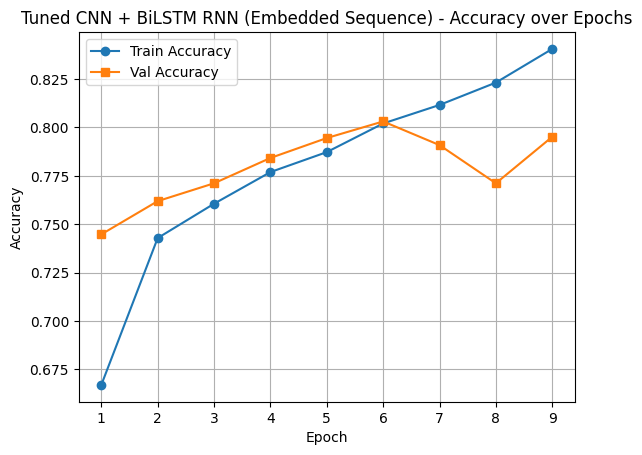

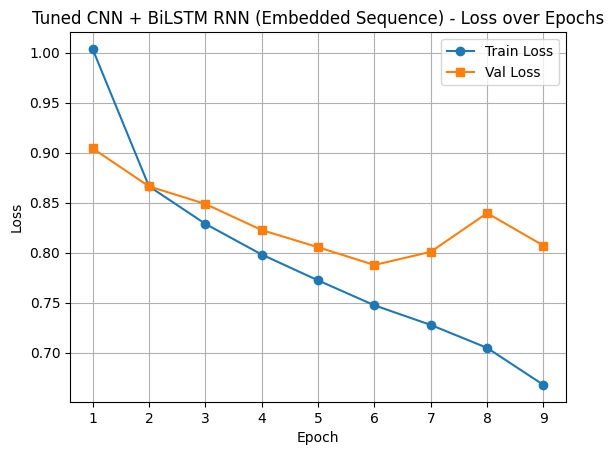

365/365 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

📊 Tuned CNN + BiLSTM RNN (Embedded Sequence) Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.78      0.76      0.77      3768
       fraud_scam_identity_theft       0.68      0.86      0.76       828
    incorrect_info_credit_report       0.88      0.84      0.86      4143
threatened_negative_legal_action       0.61      0.62      0.61      1124
  trouble_during_payment_process       0.92      0.92      0.92      1791

                        accuracy                           0.81     11654
                       macro avg       0.77      0.80      0.78     11654
                    weighted avg       0.81      0.81      0.81     11654



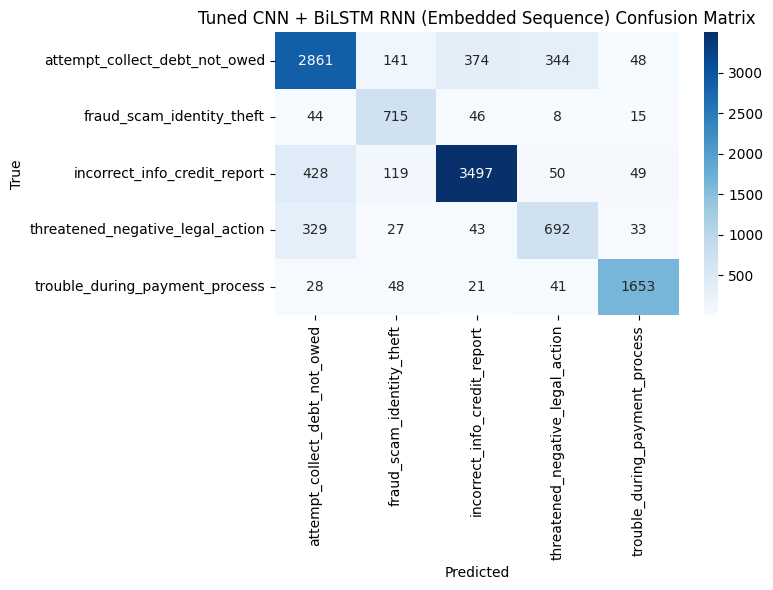

In [ ]:
# Build CNN + BiLSTM model built from best Optuna hyperparameters

# Load best hyperparameters from file (optional if restarting runtime)
# load_path = "/content/drive/MyDrive/FYP/Hyperparameter_Tuning/CNN_BiLSTM_best_hyperparams.json"
# with open(load_path, "r") as f:
#     best_params = json.load(f)

best_params = study.best_trial.params

# Rebuild model with best hyperparameters
model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=True),

    Conv1D(filters=best_params['conv_filters'],
           kernel_size=best_params['kernel_size'],
           activation='relu',
           padding='same'),
    BatchNormalization(),
    Dropout(best_params['dropout_conv']),

    Bidirectional(LSTM(best_params['lstm_units'], return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(best_params['dropout_lstm']),

    Dense(best_params['dense_units'], activation='relu',
          kernel_regularizer=l2(best_params['l2_reg'])),
    BatchNormalization(),

    Dense(num_classes, activation='softmax')
])

# Compile with label smoothing
model.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/FYP/Models/Tuned_CNN_BiLSTM_Seq.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Train on full training data
history = model.fit(
    X_train_pad_final, y_train_onehot_final,
    validation_data=(X_val_pad, y_val_onehot),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print("")
model.summary()

# Plot training performance
plot_history(history, "Tuned CNN + BiLSTM RNN (Embedded Sequence)")

# Generate predictions on test set
cnn_bilstm_preds = np.argmax(model.predict(X_test_pad), axis=1)
y_true = y_test
class_names = label_encoder.classes_

# Plot classification report & confusion matrix
print("\n📊 Tuned CNN + BiLSTM RNN (Embedded Sequence) Report")
print(classification_report(y_true, cnn_bilstm_preds, target_names=class_names))
plot_cm(y_true, cnn_bilstm_preds, "Tuned CNN + BiLSTM RNN (Embedded Sequence) Confusion Matrix")

## Tuned 3 Layers GCN V2 (TF-IDF Weighted Word2Vec + LDA)

In [ ]:
# GCN V2 (3 GCN layers + LR Scheduler)

# Concatenate for full graph using combined TF-IDF weighted Word2Vec + LDA features
X_all = np.vstack([combined_train, combined_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(combined_train_final)
num_val = len(combined_val)
num_train_total = num_train_final + num_val
num_test = len(combined_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

def objective(trial):
    # Hyperparameters to be tuned
    k = trial.suggest_int("k", 5, 30, step=5)
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    dropout_rate = trial.suggest_float("dropout", 0.3, 0.7)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    # Construct graph using KNN (only for adjacency, not learning)
    adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
    edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

    # Convert to PyTorch Geometric Data object
    x_tensor = torch.tensor(X_all, dtype=torch.float)
    y_tensor = torch.tensor(y_all, dtype=torch.long)
    data_gcn_v2 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
    data_gcn_v2 = NormalizeFeatures()(data_gcn_v2)

    # Define train/val/test masks
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[:num_train_final] = True
    val_mask[num_train_final:num_train_total] = True
    test_mask[num_train_total:] = True

    data_gcn_v2.train_mask = train_mask
    data_gcn_v2.val_mask = val_mask
    data_gcn_v2.test_mask = test_mask

    # GCN Model Definition
    class GCN(nn.Module):
        def __init__(self, in_channels, hidden_channels, out_channels, dropout_rate):
            super(GCN, self).__init__()
            self.conv1 = GCNConv(in_channels, hidden_channels)
            self.bn1 = BatchNorm1d(hidden_channels)

            self.conv2 = GCNConv(hidden_channels, hidden_channels)
            self.bn2 = BatchNorm1d(hidden_channels)

            self.conv3 = GCNConv(hidden_channels, out_channels)
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            x = self.conv1(x, edge_index)
            x = self.bn1(x)
            x = F.relu(x)
            x = self.dropout(x)

            x = self.conv2(x, edge_index)
            x = self.bn2(x)
            x = F.relu(x)
            x = self.dropout(x)

            x = self.conv3(x, edge_index)
            return F.log_softmax(x, dim=1)

    in_dim = data_gcn_v2.num_node_features
    out_dim = len(np.unique(y_all))
    data_gcn_v2 = data_gcn_v2.to(device)

    model = GCN(in_dim, hidden_dim, out_dim, dropout_rate).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    epochs = 500
    best_val_loss = float("inf")
    patience = 10
    patience_counter = 0
    prev_lr = optimizer.param_groups[0]['lr']

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data_gcn_v2)
        loss = F.cross_entropy(out[data_gcn_v2.train_mask], data_gcn_v2.y[data_gcn_v2.train_mask], weight=class_weights)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_out = model(data_gcn_v2)[data_gcn_v2.val_mask]
            val_loss = F.cross_entropy(val_out, data_gcn_v2.y[data_gcn_v2.val_mask], weight=class_weights)
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        if current_lr < prev_lr:
            print(f"[Trial {trial.number}] Epoch {epoch}: ReduceLROnPlateau reducing learning rate to {current_lr}")
        prev_lr = current_lr

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"[Trial {trial.number}] Epoch {epoch}: Early stopping triggered. Best val_loss: {best_val_loss:.5f}")
            break

    return best_val_loss

# Run Optuna study
study = optuna.create_study(
    direction='minimize',
    # give each trail 3 epoch chances to prove before prune
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)
study.optimize(objective, n_trials=30)

# Save and print the best hyperparameter combination
save_path = "/content/drive/MyDrive/FYP/Hyperparameter_Tuning/GCN_V2_best_hyperparams.json"
with open(save_path, "w") as f:
    json.dump(study.best_trial.params, f)

print("Best hyperparameters:")
print(study.best_trial.params)

[I 2025-05-31 06:36:49,088] A new study created in memory with name: no-name-ff3fb207-3ddd-4d7d-8bdd-1d00aec98fcf


[Trial 0] Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00012757608407351078


[I 2025-05-31 06:37:28,555] Trial 0 finished with value: 1.6093814373016357 and parameters: {'k': 15, 'hidden_dim': 128, 'dropout': 0.6170892228828144, 'learning_rate': 0.00025515216814702156, 'weight_decay': 0.00042108564755969046}. Best is trial 0 with value: 1.6093814373016357.


[Trial 0] Epoch 11: Early stopping triggered. Best val_loss: 1.60938
[Trial 1] Epoch 8: ReduceLROnPlateau reducing learning rate to 0.001972462424559856


[I 2025-05-31 06:38:04,043] Trial 1 finished with value: 1.6109973192214966 and parameters: {'k': 15, 'hidden_dim': 256, 'dropout': 0.5817881815482379, 'learning_rate': 0.003944924849119712, 'weight_decay': 0.0055593204252592735}. Best is trial 0 with value: 1.6093814373016357.


...

[Trial 27] Epoch 11: Early stopping triggered. Best val_loss: 1.61130


[I 2025-05-31 06:55:11,904] Trial 28 finished with value: 1.6127562522888184 and parameters: {'k': 10, 'hidden_dim': 64, 'dropout': 0.440941801541482, 'learning_rate': 0.00016697324391241352, 'weight_decay': 0.0001916741198735612}. Best is trial 26 with value: 1.609048843383789.


[Trial 28] Epoch 7: ReduceLROnPlateau reducing learning rate to 8.348662195620676e-05
[Trial 28] Epoch 11: Early stopping triggered. Best val_loss: 1.61276
[Trial 29] Epoch 7: ReduceLROnPlateau reducing learning rate to 6.456606839050506e-05


[I 2025-05-31 06:55:49,199] Trial 29 finished with value: 1.6107150316238403 and parameters: {'k': 15, 'hidden_dim': 256, 'dropout': 0.49867995489788414, 'learning_rate': 0.0001291321367810101, 'weight_decay': 1.3488847121886236e-06}. Best is trial 26 with value: 1.609048843383789.


[Trial 29] Epoch 11: Early stopping triggered. Best val_loss: 1.61072
Best hyperparameters:
{'k': 10, 'hidden_dim': 128, 'dropout': 0.478584767836697, 'learning_rate': 0.00010495690875870661, 'weight_decay': 2.704960752241457e-06}


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001: val_accuracy = 0.2252, val_loss improved to 1.9360, saving model...
Epoch 002: val_accuracy = 0.2454, val_loss improved to 1.9179, saving model...
Epoch 003: val_accuracy = 0.2349, val_loss = 1.9187
Epoch 004: val_accuracy = 0.2417, val_loss improved to 1.8752, saving model...
Epoch 005: val_accuracy = 0.2375, val_loss = 1.8827
Epoch 006: val_accuracy = 0.2447, val_loss improved to 1.8360, saving model...
Epoch 007: val_accuracy = 0.2563, val_loss improved to 1.8217, saving model...
Epoch 008: val_accuracy = 0.2533, val_loss improved to 1.8051, saving model...
Epoch 009: val_accuracy = 0.2589, val_loss improved to 1.7704, saving model...
Epoch 010: val_accuracy = 0.2595, val_loss improved to 1.7665, saving model...
Epoch 011: val_accuracy = 0.2625, val_loss improved to 1.7652, saving model...
Epoch 012: val_accuracy = 0.2686, val_loss improved to 1.7578, saving model...
Epoch 013: val_accuracy = 0.2765, val_loss improved to 1.7115, saving model...
Epoch 014: val_accuracy = 0

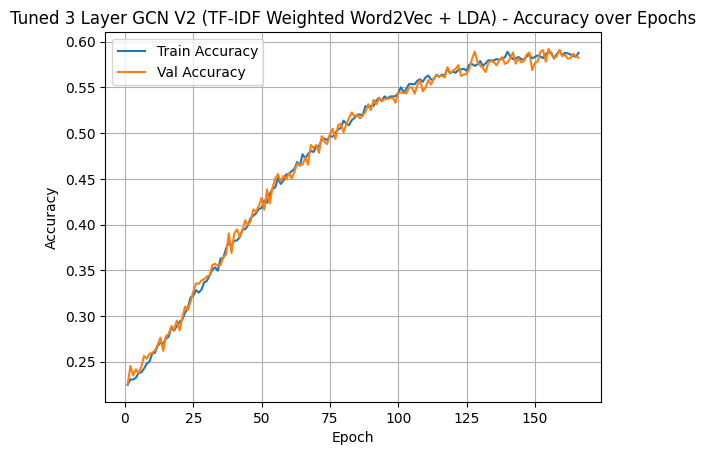

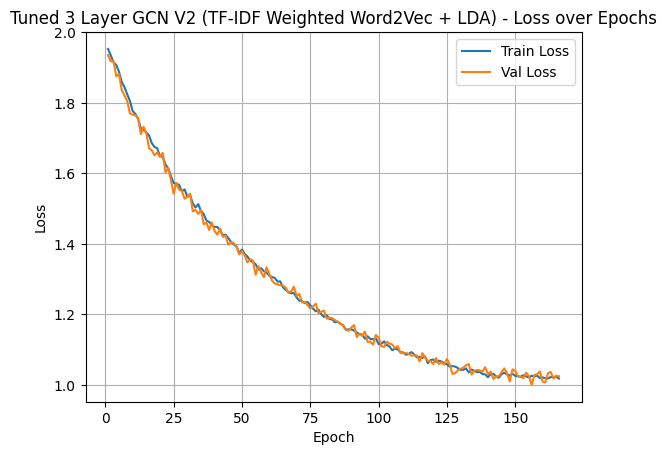


📊 Tuned 3 Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report
                                  precision    recall  f1-score   support

   attempt_collect_debt_not_owed       0.68      0.40      0.50      3768
       fraud_scam_identity_theft       0.44      0.82      0.57       828
    incorrect_info_credit_report       0.78      0.66      0.72      4143
threatened_negative_legal_action       0.29      0.64      0.40      1124
  trouble_during_payment_process       0.78      0.83      0.80      1791

                        accuracy                           0.61     11654
                       macro avg       0.59      0.67      0.60     11654
                    weighted avg       0.68      0.61      0.62     11654



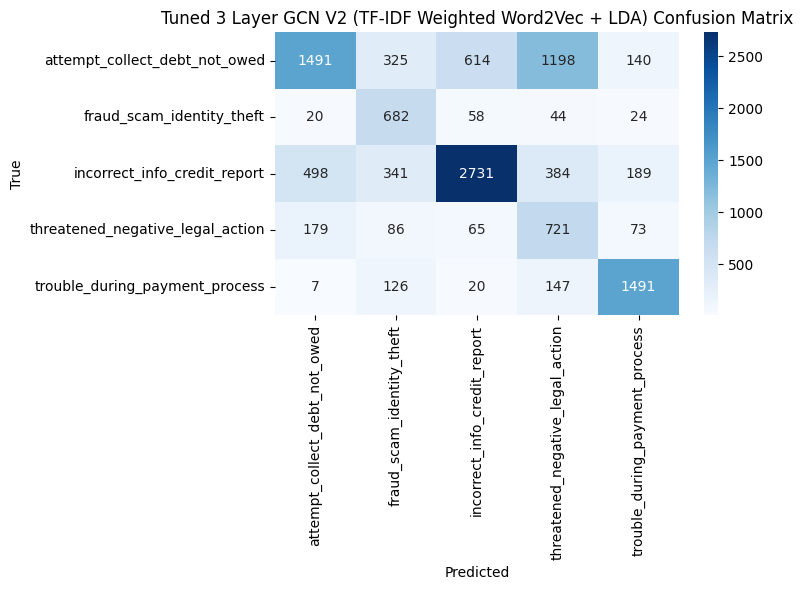

In [ ]:
# Build GCN model based on the best hyperparameter combination

# Reload best params
best_gcn_params = study.best_trial.params

# Concatenate for full graph using combined TF-IDF weighted Word2Vec + LDA features
X_all = np.vstack([combined_train, combined_test])
y_all = np.concatenate([y_train, y_test])
num_nodes = X_all.shape[0]

# Get correct sizes for train/val/test
num_train_final = len(combined_train_final)
num_val = len(combined_val)
num_train_total = num_train_final + num_val
num_test = len(combined_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Compute class weights from training labels
train_labels = y_all[:num_train_final]
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

# Construct graph using KNN (only for adjacency, not learning)
k = best_gcn_params['k']
adj_matrix = kneighbors_graph(X_all, k, mode='connectivity', include_self=True)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)  # shape [2, num_edges]

# Convert to PyTorch Geometric Data object
x_tensor = torch.tensor(X_all, dtype=torch.float)
y_tensor = torch.tensor(y_all, dtype=torch.long)
data_gcn_v2 = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data_gcn_v2 = NormalizeFeatures()(data_gcn_v2)

# Define train/val/test masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[:num_train_final] = True
val_mask[num_train_final:num_train_total] = True
test_mask[num_train_total:] = True

data_gcn_v2.train_mask = train_mask
data_gcn_v2.val_mask = val_mask
data_gcn_v2.test_mask = test_mask

# GCN Model Definition
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, droupout_rate):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(droupout_rate)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

# Hyperparameters
in_dim = data_gcn_v2.num_node_features
out_dim = len(np.unique(y_all))
data_gcn_v2 = data_gcn_v2.to(device)

model = GCN(in_dim, best_gcn_params['hidden_dim'], out_dim, best_gcn_params['dropout']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=best_gcn_params['learning_rate'], weight_decay=best_gcn_params['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Directory to save models
save_dir = "/content/drive/MyDrive/FYP/Models/"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "Tuned_GCN_V2_3L.pth")

# Initialize metric trackers
epochs = 500
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
best_model_state = None
early_stopping_patience = 10
no_improve_epochs = 0

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    out = model(data_gcn_v2)
    loss = F.cross_entropy(
        out[data_gcn_v2.train_mask],
        data_gcn_v2.y[data_gcn_v2.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # Training accuracy
    preds_train = out[data_gcn_v2.train_mask].argmax(dim=1)
    acc_train = preds_train.eq(data_gcn_v2.y[data_gcn_v2.train_mask]).sum().item() / data_gcn_v2.train_mask.sum().item()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = out[data_gcn_v2.val_mask]
        val_labels = data_gcn_v2.y[data_gcn_v2.val_mask]
        val_loss = F.cross_entropy(val_logits, val_labels, weight=class_weights)
        preds_val = val_logits.argmax(dim=1)
        acc_val = preds_val.eq(val_labels).sum().item() / data_gcn_v2.val_mask.sum().item()

    # Save metrics
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(acc_train)
    val_accuracies.append(acc_val)
    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        no_improve_epochs = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, best_model_path)
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss improved to {val_loss.item():.4f}, saving model...")
    else:
        no_improve_epochs += 1
        print(f"Epoch {epoch:03d}: val_accuracy = {acc_val:.4f}, val_loss = {val_loss.item():.4f}")

    if no_improve_epochs >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs with no improvement in val_loss.")
        break

print(f"Best model saved to: {best_model_path} with val_loss: {best_val_loss:.4f}")

# Print model archiecture summary
print("")
print(model)

# Plot model performance over epoch
plot_gnn_history(train_accuracies, val_accuracies, train_losses, val_losses, "Tuned 3 Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA)")


# Generate predictions on test set
model.load_state_dict(best_model_state)
model.eval()
class_names = label_encoder.classes_
with torch.no_grad():
    out = model(data_gcn_v2)
    preds = out.argmax(dim=1)[data_gcn_v2.test_mask].cpu().numpy()
y_true_gcn_v2 = data_gcn_v2.y[data_gcn_v2.test_mask].cpu().numpy()

# Plot classification report & confusion matrix
print("\n📊 Tuned 3 Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Classification Report")
print(classification_report(y_true_gcn_v2, preds, target_names=class_names))
plot_cm(y_true_gcn_v2, preds, "Tuned 3 Layer GCN V2 (TF-IDF Weighted Word2Vec + LDA) Confusion Matrix")

# Set Up Data Cleaning Pipeline in Deployment Interface

Experiment data preprocessing pipeline and SHAP explainable AI first then can move the code to deployment script

In [ ]:
# Link to Google Drive (straight away start from here, no need to rerun from start)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install contractions --quiet
!pip install shap --quiet

# Update tensorflow and keras to latest version to ensure model output is up-to-date
!pip install --upgrade keras tensorflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 59.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.19.0 which is incompatible.


In [ ]:
# Import library
import joblib
import shap
import numpy as np
import contractions
import re
import nltk
import pandas as pd
import random
import pickle
import ast

from nltk.corpus import stopwords, wordnet, words
from nltk.tokenize import regexp_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

In [ ]:
nltk.download("stopwords")
nltk.download("words")
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
# Load vectorizer & label encoder
with open('/content/drive/MyDrive/FYP/Features/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

with open("/content/drive/MyDrive/FYP/Features/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [ ]:
# Convert the old version of h5 model to keras model to be compatible in Streamlit deployment

# Load the original .h5 model
model_h5 = load_model("/content/drive/MyDrive/FYP/Models/CNN_BiLSTM_Seq.h5")

# Save it in .keras format
model_h5.save("/content/drive/MyDrive/FYP/Models/CNN_BiLSTM_Seq.keras", save_format="keras")

# Load the newly saved .keras model
model_keras = load_model("/content/drive/MyDrive/FYP/Models/CNN_BiLSTM_Seq.keras")

# Sanity check to ensure keras and h5 best_model are same

# Print model summaries to visually inspect
print(model_h5.summary())
print(model_keras.summary())

# Simulate test input
sample_input = np.random.rand(1, 100).astype(np.float32)  # shape must match model input

# Predict with both models
pred_h5 = model_h5.predict(sample_input)
pred_keras = model_keras.predict(sample_input)

# Compare results
print("Are predictions equal?", np.allclose(pred_h5, pred_keras, atol=1e-5))

for w1, w2 in zip(model_h5.get_weights(), model_keras.get_weights()):
    assert np.allclose(w1, w2), "Weights do not match!"

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 36 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 100)       │     1,489,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 100, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 100, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,834,539 (7.00 MB)

 Trainable params: 1,834,153 (7.00 MB)

...

 Total params: 5,502,845 (20.99 MB)

 Trainable params: 1,834,153 (7.00 MB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 3,668,308 (13.99 MB)

None
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
Are predictions equal? True


In [ ]:
# Load the best model
model = load_model("/content/drive/MyDrive/FYP/Models/CNN_BiLSTM_Seq.keras")

In [ ]:
# Define function to recreate text cleaning pipeline in EDA
stop_words = set(stopwords.words('english'))
negation_words = {"no", "not", "never", "none", "nobody", "nothing", "nowhere", "neither"}
custom_stopwords = stop_words - negation_words
lemmatizer = WordNetLemmatizer()
english_vocab = set(w.lower() for w in words.words())

# Repetition reducer
class RepeatReplacer:
    def __init__(self):
        self.repeat_regexp = re.compile(r'(\w*)(\w)\2(\w*)')
        self.repl = r'\1\2\3'

    def replace(self, word):
        # Check if the word is valid in WordNet
        if wordnet.synsets(word):
            return word
        repl_word = self.repeat_regexp.sub(self.repl, word)
        # If the word was changed, continue reducing
        if repl_word != word:
            return self.replace(repl_word)
        else:  # Return the reduced word
            return repl_word

# Initialize the replacer
replacer = RepeatReplacer()

# Helper function
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        # Default to noun if no match
        return wordnet.NOUN

def lemmatize_tokens(tokens):
    pos_tags = pos_tag(tokens)
    return [lemmatizer.lemmatize(token.lower(), get_wordnet_pos(tag)) for token, tag in pos_tags]

def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in custom_stopwords
            and (not re.fullmatch(r'[a-zA-Z]{1,2}', word) or len(set(word)) > 1)]

def remove_non_english_words(tokens):
    return [word for word in tokens if word.lower() in english_vocab]

def clean_text(text):
    # 1. Remove multiple XXXX symbols (anonymized information) + Clean extra whitespace
    text = re.sub(r'X+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Text cleaning
    # Lowercase all words
    text = text.lower()
    # Expand contractions
    text = contractions.fix(text)
    # Remove URLs starting with http/https
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    # Remove URLs starting with www
    text = re.sub(r'www\.[a-zA-Z0-9-]+(?:\.[a-zA-Z]{2,})+', '', text)
    # Remove html tags with the content inside "<P/>"
    text = re.sub(r'<\s*\w+\s*/>', '', text)
    # Remove words with values
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    # Remove redundant punctuations
    text = re.sub(r'([.,!?;:()\-])\1+', r'\1', text)
    # Expand contractions again
    text = contractions.fix(text)
    # Remove all punctuation to facilitate shortening of repetitive character
    text = re.sub(r'(?<!\w)-|-(?!\w)|[^\w\s-]', ' ', text)
    # Shorten repetitive letters
    text = ' '.join([replacer.replace(word) for word in text.split()])
    # Remove redundant words
    text = re.sub(r'\b(\w+)( \1)+\b', r'\1', text)

    # 3. Tokenize using NLTK
    pattern = r"[a-zA-Z0-9]+(?:-[a-zA-Z0-9]+)*|[.,!?;'\-\"()[]]"
    tokens = regexp_tokenize(text, pattern)

    # 4. POS tagging + lemmatization
    tokens = lemmatize_tokens(tokens)

    # 5. Stopword removal (keep negations) + repetitive character removal
    tokens = remove_stopwords(tokens)

    # 6. Filter out non-English words
    tokens = remove_non_english_words(tokens)

    return ' '.join(tokens)

In [ ]:
# Define predict function for best model
def predict_cnn_bilstm(raw_text, model, tokenizer, label_encoder, maxlen=100):
    # Step 1: Clean the raw complaint text
    cleaned = clean_text(raw_text)

    # Step 2: Tokenize and pad
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=maxlen, padding='post')

    # Step 3: Predict
    pred_probs = model.predict(padded)
    pred_class = pred_probs.argmax(axis=1)

    # Step 4: Decode label
    label = label_encoder.inverse_transform(pred_class)[0]

    return {
        "input_cleaned": cleaned,
        "predicted_label": label,
        "confidence": round(float(pred_probs.max()) * 100, 2)
    }

In [ ]:
# Sample batch of dirty test texts
dirty_texts = [
    "ehh why issss my credit score drop??? got some weird loan i never took... fix it pls 😤😤",
    "yo why u ppl keep msg me say i owe $$?? i alr paid like last year or smth. stop bugging me la 😤",
    "I try pay on ur app, but payment keep fail! fix ur system!!! 😡👎",
    "got email say will sue me or bring court if i no pay... whyyy?? this not even my account 😠👿",
    "SOMEONE USED MY NAME TO OPEN ACCOUNT!!! whyyyyy??? I DIDN'T DO THIS... ID STOLEN????!! 😡😭"
]

# Run prediction on each text and print result
for i, text in enumerate(dirty_texts, 1):
    result = predict_cnn_bilstm(text, model, tokenizer, label_encoder)
    print(f"--- Sample {i} ---")
    print(f"Original Input     : {text}")
    print(f"Cleaned Input      : {result['input_cleaned']}")
    print(f"Predicted Label    : {result['predicted_label']}")
    print(f"Confidence         : {result['confidence']}%\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
--- Sample 1 ---
Original Input     : ehh why issss my credit score drop??? got some weird loan i never took... fix it pls 😤😤
Cleaned Input      : eh credit score drop get weird loan never take fix
Predicted Label    : incorrect_info_credit_report
Confidence         : 82.27%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
--- Sample 2 ---
Original Input     : yo why u ppl keep msg me say i owe $$?? i alr paid like last year or smth. stop bugging me la 😤
Cleaned Input      : yo people keep message say owe pay like last year stop la
Predicted Label    : threatened_negative_legal_action
Confidence         : 51.52%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
--- Sample 3 ---
Original Input     : I try pay on ur app, but payment keep fail! fix ur system!!! 😡👎
Cleaned Input      : try pay payment keep fail fix system
Predicted Label    : trouble_during_payment_process
Confidence         : 80.29%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
--- Sample 4 ---
Original Input  

# Explainable AI (SHAP)

In [ ]:
# Define wrapper class for SHAP XAI
class CNNBiLSTMWrapper:
    def __init__(self, model, tokenizer, maxlen=100):
        self.model = model
        self.tokenizer = tokenizer
        self.maxlen = maxlen

    def __call__(self, texts):
        cleaned_texts = [clean_text(t) for t in texts]
        sequences = self.tokenizer.texts_to_sequences(cleaned_texts)
        padded = pad_sequences(sequences, maxlen=self.maxlen, padding='post')
        return self.model.predict(padded)

In [ ]:
# Wrap explainer model
wrapped_model = CNNBiLSTMWrapper(model, tokenizer)

# Use regex-based tokenizer for SHAP
regex_masker = shap.maskers.Text(r"\w+")

# Create SHAP explainer using the wrapped model and label names
explainer = shap.Explainer(
    wrapped_model,
    masker=regex_masker,
    output_names=label_encoder.classes_
)

In [ ]:
def explain_with_shap(input_text, explainer, model, tokenizer, label_encoder, maxlen=100):
    # Predict
    prediction = predict_cnn_bilstm(input_text, model, tokenizer, label_encoder, maxlen=maxlen)
    print("Prediction:", prediction)

    # Get SHAP values
    shap_values = explainer([input_text])

    # Get predicted class index for correct explanation
    predicted_class = label_encoder.transform([prediction["predicted_label"]])[0]

    # Visualize
    shap.plots.waterfall(shap_values[0][:, predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Prediction: {'input_cleaned': 'credit report wrongly cause drop score', 'predicted_label': 'incorrect_info_credit_report', 'confidence': 87.22}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


  0%|          | 0/156 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


PartitionExplainer explainer: 2it [00:15, 15.44s/it]               


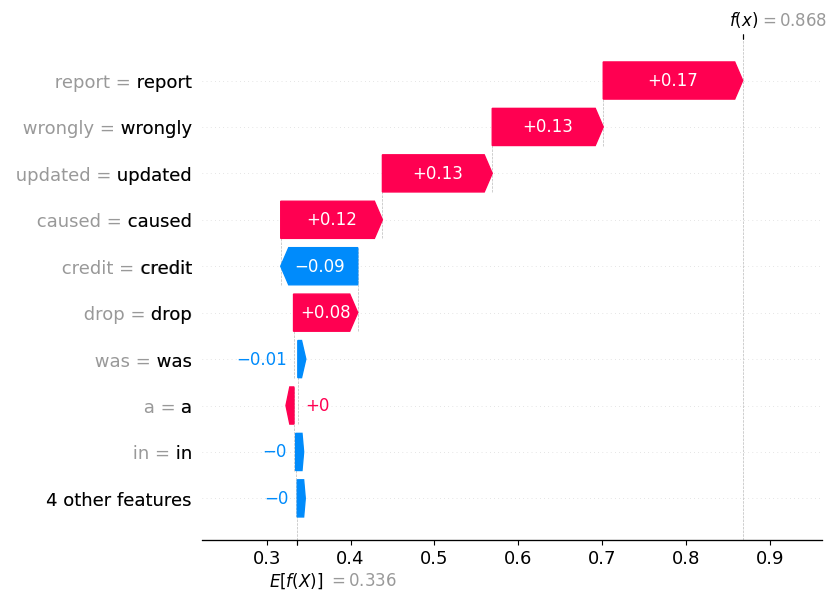

In [ ]:
# Example input
user_input = "my credit report was wrongly updated and caused a drop in my score"

# Call explainer
explain_with_shap(
    input_text=user_input,
    explainer=explainer,
    model=model,
    tokenizer=tokenizer,
    label_encoder=label_encoder
)